# Module 7 – Cluster Evaluation & Customer Profiling

## Activity 1: Cluster Statistics & Demographic Analysis

### Objective

The objective of this activity is to analyze the demographic characteristics of customers within each machine learning cluster.

The analysis will compare:

- Customer count
- Customer age
- Income
- Education level
- Marital status
- Family size
- Number of children

The results will be used to understand the characteristics of each customer segment and support meaningful business interpretation.

In [3]:
# ============================================================
# MODULE 7 – ACTIVITY 1
# CLUSTER STATISTICS & DEMOGRAPHIC ANALYSIS
# ============================================================

import os
import json
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
# ============================================================
# CHECK AVAILABLE DATA
# ============================================================

print("=" * 60)
print("AVAILABLE DATASETS / VARIABLES")
print("=" * 60)

available_variables = [
    "selected_df",
    "scaled_df",
    "final_kmeans_model",
    "final_kmeans_labels",
    "kmeans_labels",
    "df"
]

for variable in available_variables:

    if variable in globals():

        obj = globals()[variable]

        print(
            f"{variable}: AVAILABLE",
            "| Type:",
            type(obj).__name__
        )

        if hasattr(obj, "shape"):
            print(
                "   Shape:",
                obj.shape
            )

    else:

        print(
            f"{variable}: NOT AVAILABLE"
        )

AVAILABLE DATASETS / VARIABLES
selected_df: NOT AVAILABLE
scaled_df: NOT AVAILABLE
final_kmeans_model: NOT AVAILABLE
final_kmeans_labels: NOT AVAILABLE
kmeans_labels: NOT AVAILABLE
df: NOT AVAILABLE


In [5]:
# ============================================================
# FIND SAVED MODULE 6 DATASETS
# ============================================================

import os

# Project root
project_root = os.path.abspath(
    os.path.join(
        os.getcwd(),
        "../.."
    )
)

print("=" * 60)
print("PROJECT ROOT")
print("=" * 60)

print(project_root)

print("\n" + "=" * 60)
print("CSV FILES FOUND IN PROJECT")
print("=" * 60)

csv_files = []

for root, dirs, files in os.walk(project_root):

    # Ignore virtual environment
    dirs[:] = [
        d for d in dirs
        if d not in ["venv", ".git", "__pycache__"]
    ]

    for file in files:

        if file.lower().endswith(".csv"):

            full_path = os.path.join(
                root,
                file
            )

            relative_path = os.path.relpath(
                full_path,
                project_root
            )

            csv_files.append(
                relative_path
            )

for file in sorted(csv_files):
    print("-", file)

print(
    "\nTotal CSV files found:",
    len(csv_files)
)

PROJECT ROOT
d:\aiLAB99\Customer-Personality-Analysis

CSV FILES FOUND IN PROJECT
- 01_Raw_Data\marketing_campaign.csv
- Cleaned_Data\customer_personality_cleaned.csv
- Cluster_Evaluation_Customer_Profiling\Reports\activity_1_age_income_comparison.csv
- Cluster_Evaluation_Customer_Profiling\Reports\activity_1_cluster_feature_averages.csv
- Cluster_Evaluation_Customer_Profiling\Reports\activity_1_cluster_statistics.csv
- Cluster_Evaluation_Customer_Profiling\Reports\activity_1_education_counts.csv
- Cluster_Evaluation_Customer_Profiling\Reports\activity_1_education_percentages.csv
- Cluster_Evaluation_Customer_Profiling\Reports\activity_1_family_children_comparison.csv
- Cluster_Evaluation_Customer_Profiling\Reports\activity_1_marital_status_counts.csv
- Cluster_Evaluation_Customer_Profiling\Reports\activity_1_marital_status_percentages.csv
- Cluster_Evaluation_Customer_Profiling\Reports\module_07_customer_cluster_profiling_dataset.csv
- Customer_Segmentation\Feature_Engineering\Selecte

##  Load and Inspect Cluster and Customer Data

The K-Means clustered dataset generated during Module 6 will be used to obtain customer cluster assignments.

The cleaned customer dataset will be used to obtain demographic information such as age, income, education, marital status, family size, and household characteristics.

Both datasets will be inspected before combining them to ensure that the required variables are available and that the customer records can be correctly aligned.

In [6]:
# ============================================================
#  LOAD REQUIRED DATASETS
# ============================================================

import pandas as pd
import os

# ------------------------------------------------------------
# File paths
# ------------------------------------------------------------

kmeans_path = os.path.join(
    project_root,
    "Customer_Segmentation",
    "Reports",
    "baseline_kmeans_clustered_data.csv"
)

cleaned_path = os.path.join(
    project_root,
    "Cleaned_Data",
    "customer_personality_cleaned.csv"
)

# ------------------------------------------------------------
# Load datasets
# ------------------------------------------------------------

kmeans_df = pd.read_csv(kmeans_path)

cleaned_df = pd.read_csv(cleaned_path)

# ------------------------------------------------------------
# Display basic information
# ------------------------------------------------------------

print("=" * 60)
print("K-MEANS CLUSTERED DATASET")
print("=" * 60)

print("Shape:", kmeans_df.shape)

print("\nColumns:")
for column in kmeans_df.columns:
    print("-", column)

print("\n" + "=" * 60)
print("CLEANED CUSTOMER DATASET")
print("=" * 60)

print("Shape:", cleaned_df.shape)

print("\nColumns:")
for column in cleaned_df.columns:
    print("-", column)

K-MEANS CLUSTERED DATASET
Shape: (2237, 18)

Columns:
- numerical__Customer_Age
- numerical__Income
- numerical__Total_Children
- numerical__Family_Size
- numerical__Total_Spending
- numerical__Average_Spending_per_Purchase
- numerical__Total_Purchases
- numerical__NumWebPurchases
- numerical__NumCatalogPurchases
- numerical__NumStorePurchases
- numerical__Total_Campaign_Acceptance
- numerical__Digital_Engagement
- numerical__NumWebVisitsMonth
- numerical__Recency
- numerical__Customer_Tenure_Years
- numerical__Deal_Dependency
- numerical__NumDealsPurchases
- Cluster

CLEANED CUSTOMER DATASET
Shape: (2237, 30)

Columns:
- ID
- Year_Birth
- Education
- Marital_Status
- Income
- Kidhome
- Teenhome
- Dt_Customer
- Recency
- MntWines
- MntFruits
- MntMeatProducts
- MntFishProducts
- MntSweetProducts
- MntGoldProds
- NumDealsPurchases
- NumWebPurchases
- NumCatalogPurchases
- NumStorePurchases
- NumWebVisitsMonth
- AcceptedCmp3
- AcceptedCmp4
- AcceptedCmp5
- AcceptedCmp1
- AcceptedCmp2
- C

In [7]:
# ============================================================
# PREVIEW DATA
# ============================================================

print("=" * 60)
print("K-MEANS DATA PREVIEW")
print("=" * 60)

display(kmeans_df.head())

print("\n" + "=" * 60)
print("CLEANED DATA PREVIEW")
print("=" * 60)

display(cleaned_df.head())

K-MEANS DATA PREVIEW


,numerical__Customer_Age,numerical__Income,numerical__Total_Children,numerical__Family_Size,numerical__Total_Spending,numerical__Average_Spending_per_Purchase,numerical__Total_Purchases,numerical__NumWebPurchases,numerical__NumCatalogPurchases,numerical__NumStorePurchases,numerical__Total_Campaign_Acceptance,numerical__Digital_Engagement,numerical__NumWebVisitsMonth,numerical__Recency,numerical__Customer_Tenure_Years,numerical__Deal_Dependency,numerical__NumDealsPurchases,Cluster
0,1.017296,0.300178,-1.264618,-1.264618,1.799304,1.193944,1.312543,1.280532,1.805202,-0.552077,-0.482053,1.560532,0.692882,0.307272,1.530038,-0.547897,0.652082,1
1,1.273722,-0.263278,1.395420,1.395420,-0.990209,-1.548990,-1.185961,-1.396839,-0.405715,-1.167421,-0.482053,-0.950312,-0.131574,-0.383584,-1.191484,1.359646,0.041655,0
2,0.333495,0.943942,-1.264618,-1.264618,0.380303,0.470482,1.034932,1.280532,0.120139,1.293956,-0.482053,0.723584,-0.543802,-0.798098,-0.206788,-1.090985,-0.818695,1
3,-1.290534,-1.204345,0.065401,0.065401,-0.942634,-1.255130,-0.908350,-0.675081,-1.304670,-0.552077,-0.482053,-0.392347,0.280654,-0.798098,-1.062830,0.550386,0.041655,0
4,-1.034108,0.307583,0.065401,0.065401,-0.267442,0.167739,0.202097,0.558774,0.493239,0.063267,-0.482053,0.165619,-0.131574,1.550812,-0.953970,0.671996,1.512432,0



CLEANED DATA PREVIEW


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,68
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,71
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,3,11,0,60
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,3,11,0,41
4,5324,1981,Phd,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,3,11,0,44


## Activity 1.8 – Validate Customer Row Alignment

The K-Means clustered dataset does not contain the original customer ID. Therefore, before attaching cluster labels to the cleaned customer dataset, the row ordering will be validated using common numerical features.

The standardized Customer Age values in the K-Means dataset will be compared with the standardized Age values calculated from the cleaned customer dataset.

This validation helps ensure that each K-Means cluster label is assigned to the correct customer record.

In [8]:
# ============================================================
# VALIDATE CUSTOMER ROW ALIGNMENT
# ============================================================

from sklearn.preprocessing import StandardScaler
import numpy as np

print("=" * 60)
print("CUSTOMER ROW ALIGNMENT VALIDATION")
print("=" * 60)

# ------------------------------------------------------------
# Check row counts
# ------------------------------------------------------------

print("K-Means Dataset Rows:", len(kmeans_df))
print("Cleaned Dataset Rows:", len(cleaned_df))

if len(kmeans_df) != len(cleaned_df):

    print("\nSTATUS: FAIL")
    print("The datasets have different numbers of rows.")

else:

    print("\nRow counts match.")

    # --------------------------------------------------------
    # Standardize Age from cleaned dataset
    # --------------------------------------------------------

    cleaned_age = cleaned_df[["Age"]].copy()

    age_scaler = StandardScaler()

    cleaned_age_scaled = age_scaler.fit_transform(
        cleaned_age
    ).flatten()

    # --------------------------------------------------------
    # Get standardized Customer_Age from K-Means dataset
    # --------------------------------------------------------

    kmeans_age_scaled = kmeans_df[
        "numerical__Customer_Age"
    ].values

    # --------------------------------------------------------
    # Compare values
    # --------------------------------------------------------

    difference = np.abs(
        kmeans_age_scaled -
        cleaned_age_scaled
    )

    max_difference = difference.max()
    mean_difference = difference.mean()

    print(
        "\nMaximum Age Difference:",
        round(max_difference, 6)
    )

    print(
        "Mean Age Difference:",
        round(mean_difference, 6)
    )

    # --------------------------------------------------------
    # Determine alignment
    # --------------------------------------------------------

    if max_difference < 0.0001:

        print("\nSTATUS: PASS")
        print(
            "Customer row ordering is consistent between "
            "the K-Means dataset and cleaned dataset."
        )

    else:

        print("\nSTATUS: CHECK")
        print(
            "Customer row ordering could not be "
            "confirmed using Customer Age."
        )

CUSTOMER ROW ALIGNMENT VALIDATION
K-Means Dataset Rows: 2237
Cleaned Dataset Rows: 2237

Row counts match.

Maximum Age Difference: 0.0
Mean Age Difference: 0.0

STATUS: PASS
Customer row ordering is consistent between the K-Means dataset and cleaned dataset.


## Create Customer Cluster Profiling Dataset

The validated K-Means cluster labels will now be attached to the cleaned customer dataset.

The resulting dataset will contain the original customer demographic and behavioral information together with the assigned K-Means cluster. This dataset will be used throughout Module 7 for demographic analysis, spending analysis, shopping behavior analysis, campaign analysis, and customer profiling.

In [9]:
# ============================================================
# CREATE CUSTOMER CLUSTER PROFILING DATASET
# ============================================================

print("=" * 60)
print("CREATING CUSTOMER CLUSTER PROFILING DATASET")
print("=" * 60)

# ------------------------------------------------------------
# Create a copy of the cleaned customer data
# ------------------------------------------------------------

profiling_df = cleaned_df.copy()

# ------------------------------------------------------------
# Attach K-Means cluster labels
# ------------------------------------------------------------

profiling_df["KMeans_Cluster"] = kmeans_df["Cluster"].values

# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

print("Profiling Dataset Shape:", profiling_df.shape)

print(
    "\nCluster Distribution:"
)

print(
    profiling_df["KMeans_Cluster"].value_counts().sort_index()
)

print(
    "\nCluster Percentages:"
)

print(
    (
        profiling_df["KMeans_Cluster"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
)

print(
    "\nMissing Cluster Labels:",
    profiling_df["KMeans_Cluster"].isna().sum()
)

print("\nSTATUS: PASS")

CREATING CUSTOMER CLUSTER PROFILING DATASET
Profiling Dataset Shape: (2237, 31)

Cluster Distribution:
KMeans_Cluster
0    1207
1    1030
Name: count, dtype: int64

Cluster Percentages:
KMeans_Cluster
0    53.96
1    46.04
Name: proportion, dtype: float64

Missing Cluster Labels: 0

STATUS: PASS


In [10]:
# ============================================================
# PREVIEW PROFILING DATASET
# ============================================================

print("=" * 60)
print("PROFILING DATASET PREVIEW")
print("=" * 60)

display(
    profiling_df[
        [
            "ID",
            "Age",
            "Income",
            "Education",
            "Marital_Status",
            "Kidhome",
            "Teenhome",
            "KMeans_Cluster"
        ]
    ].head(10)
)

PROFILING DATASET PREVIEW


,ID,Age,Income,Education,Marital_Status,Kidhome,Teenhome,KMeans_Cluster
0,5524,68,58138.0,Graduation,Single,0,0,1
1,2174,71,46344.0,Graduation,Single,1,1,0
2,4141,60,71613.0,Graduation,Together,0,0,1
3,6182,41,26646.0,Graduation,Together,1,0,0
4,5324,44,58293.0,Phd,Married,1,0,0
5,7446,58,62513.0,Master,Together,0,1,1
6,965,54,55635.0,Graduation,Divorced,0,1,1
7,6177,40,33454.0,Phd,Married,1,0,0
8,4855,51,30351.0,Phd,Together,1,0,0
9,5899,75,5648.0,Phd,Together,1,1,0


In [12]:
# ============================================================
# SAVE PROFILING DATASET
# ============================================================

# Define the reports directory path
reports_dir = os.path.join(
    project_root,
    "Cluster_Evaluation_Customer_Profiling",
    "Reports"
)

# Create directory if it doesn't exist
os.makedirs(reports_dir, exist_ok=True)

profiling_output_path = os.path.join(
    reports_dir,
    "module_07_customer_cluster_profiling_dataset.csv"
)

profiling_df.to_csv(
    profiling_output_path,
    index=False
)

print(
    "Profiling dataset saved successfully."
)

print(
    "Location:",
    os.path.abspath(profiling_output_path)
)

Profiling dataset saved successfully.
Location: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\module_07_customer_cluster_profiling_dataset.csv


##  Cluster Statistics & Customer Counts

The customer profiling dataset will be grouped by K-Means cluster to calculate the number and percentage of customers in each cluster.

Average values of the available numerical customer characteristics will also be calculated to understand the overall differences between the identified customer segments.

In [13]:
# ============================================================
# CLUSTER STATISTICS
# ============================================================

print("=" * 60)
print("CLUSTER STATISTICS")
print("=" * 60)

# ------------------------------------------------------------
# Customer count by cluster
# ------------------------------------------------------------

cluster_counts = (
    profiling_df["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)

cluster_percentages = (
    profiling_df["KMeans_Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

cluster_statistics = pd.DataFrame({
    "Customer_Count": cluster_counts,
    "Percentage": cluster_percentages
})

print("\nCustomer Count by Cluster:")
display(cluster_statistics)

# ------------------------------------------------------------
# Numerical feature averages
# ------------------------------------------------------------

numerical_columns = profiling_df.select_dtypes(
    include=np.number
).columns.tolist()

# Remove ID and cluster label from averages
numerical_columns = [
    column
    for column in numerical_columns
    if column not in ["ID", "KMeans_Cluster"]
]

cluster_means = (
    profiling_df
    .groupby("KMeans_Cluster")[numerical_columns]
    .mean()
    .round(2)
)

print("\nAverage Numerical Features by Cluster:")
display(cluster_means)

print("\nSTATUS: PASS")

CLUSTER STATISTICS

Customer Count by Cluster:


,Customer_Count,Percentage
KMeans_Cluster,,
0,1207,53.96
1,1030,46.04



Average Numerical Features by Cluster:


,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,
0,1970.7,36951.44,0.76,0.54,48.80,74.65,5.80,32.56,8.66,5.96,...,0.07,0.02,0.00,0.00,0.00,0.01,3.0,11.0,0.10,54.3
1,1966.8,69319.25,0.07,0.47,49.46,568.75,40.27,289.41,59.58,40.66,...,0.08,0.14,0.16,0.13,0.03,0.01,3.0,11.0,0.21,58.2



STATUS: PASS


In [14]:
# ============================================================
# SAVE CLUSTER STATISTICS
# ============================================================

cluster_statistics_path = os.path.join(
    reports_dir,
    "activity_1_cluster_statistics.csv"
)

cluster_means_path = os.path.join(
    reports_dir,
    "activity_1_cluster_feature_averages.csv"
)

cluster_statistics.to_csv(
    cluster_statistics_path
)

cluster_means.to_csv(
    cluster_means_path
)

print("Cluster statistics saved successfully.")

print(
    "\nCustomer Count Report:",
    os.path.abspath(cluster_statistics_path)
)

print(
    "Cluster Feature Averages:",
    os.path.abspath(cluster_means_path)
)

Cluster statistics saved successfully.

Customer Count Report: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_cluster_statistics.csv
Cluster Feature Averages: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_cluster_feature_averages.csv


## Customer Age and Income Comparison

This analysis compares the average customer age and income across the K-Means clusters.

The purpose is to determine whether the identified customer segments differ in terms of customer age and financial value.

In [15]:
# ============================================================
# AGE & INCOME COMPARISON
# ============================================================

print("=" * 60)
print("AGE & INCOME COMPARISON")
print("=" * 60)

age_income_comparison = (
    profiling_df
    .groupby("KMeans_Cluster")
    .agg(
        Average_Age=("Age", "mean"),
        Average_Income=("Income", "mean"),
        Minimum_Age=("Age", "min"),
        Maximum_Age=("Age", "max"),
        Minimum_Income=("Income", "min"),
        Maximum_Income=("Income", "max")
    )
    .round(2)
)

print("\nAge and Income Comparison:")
display(age_income_comparison)

# ------------------------------------------------------------
# Identify higher/lower groups
# ------------------------------------------------------------

highest_age_cluster = (
    age_income_comparison["Average_Age"].idxmax()
)

lowest_age_cluster = (
    age_income_comparison["Average_Age"].idxmin()
)

highest_income_cluster = (
    age_income_comparison["Average_Income"].idxmax()
)

lowest_income_cluster = (
    age_income_comparison["Average_Income"].idxmin()
)

print(
    f"\nHighest Average Age: Cluster {highest_age_cluster}"
)

print(
    f"Lowest Average Age: Cluster {lowest_age_cluster}"
)

print(
    f"Highest Average Income: Cluster {highest_income_cluster}"
)

print(
    f"Lowest Average Income: Cluster {lowest_income_cluster}"
)

print("\nSTATUS: PASS")

AGE & INCOME COMPARISON

Age and Income Comparison:


,Average_Age,Average_Income,Minimum_Age,Maximum_Age,Minimum_Income,Maximum_Income
KMeans_Cluster,,,,,,
0,54.3,36951.44,29,85,1730.0,117418.0
1,58.2,69319.25,30,84,22507.0,117418.0



Highest Average Age: Cluster 1
Lowest Average Age: Cluster 0
Highest Average Income: Cluster 1
Lowest Average Income: Cluster 0

STATUS: PASS


In [16]:
# ============================================================
# SAVE AGE & INCOME REPORT
# ============================================================

age_income_path = os.path.join(
    reports_dir,
    "activity_1_age_income_comparison.csv"
)

age_income_comparison.to_csv(
    age_income_path
)

print(
    "Age and income comparison saved successfully."
)

print(
    "Location:",
    os.path.abspath(age_income_path)
)

Age and income comparison saved successfully.
Location: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_age_income_comparison.csv


## Education Level Comparison

This analysis compares the education-level distribution across the identified K-Means customer clusters.

The purpose is to determine whether educational characteristics differ between customer segments and whether any education category is particularly concentrated within a specific cluster.

In [17]:
# ============================================================
# EDUCATION LEVEL COMPARISON
# ============================================================

print("=" * 60)
print("EDUCATION LEVEL COMPARISON")
print("=" * 60)

# ------------------------------------------------------------
# Education count by cluster
# ------------------------------------------------------------

education_counts = pd.crosstab(
    profiling_df["KMeans_Cluster"],
    profiling_df["Education"]
)

print("\nEducation Count by Cluster:")
display(education_counts)

# ------------------------------------------------------------
# Education percentage by cluster
# ------------------------------------------------------------

education_percentages = (
    pd.crosstab(
        profiling_df["KMeans_Cluster"],
        profiling_df["Education"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

print("\nEducation Percentage by Cluster:")
display(education_percentages)

# ------------------------------------------------------------
# Most common education level in each cluster
# ------------------------------------------------------------

print("\nMost Common Education Level by Cluster:")

for cluster in education_counts.index:

    top_education = education_counts.loc[
        cluster
    ].idxmax()

    top_count = education_counts.loc[
        cluster
    ].max()

    top_percentage = education_percentages.loc[
        cluster,
        top_education
    ]

    print(
        f"Cluster {cluster}: "
        f"{top_education} "
        f"({top_count} customers, "
        f"{top_percentage:.2f}%)"
    )

print("\nSTATUS: PASS")

EDUCATION LEVEL COMPARISON

Education Count by Cluster:


Education,2N Cycle,Basic,Graduation,Master,Phd
KMeans_Cluster,,,,,
0,121,53,595,210,228
1,80,1,532,160,257



Education Percentage by Cluster:


Education,2N Cycle,Basic,Graduation,Master,Phd
KMeans_Cluster,,,,,
0,10.02,4.39,49.30,17.40,18.89
1,7.77,0.10,51.65,15.53,24.95



Most Common Education Level by Cluster:
Cluster 0: Graduation (595 customers, 49.30%)
Cluster 1: Graduation (532 customers, 51.65%)

STATUS: PASS


In [18]:
# ============================================================
# SAVE EDUCATION REPORT
# ============================================================

education_count_path = os.path.join(
    reports_dir,
    "activity_1_education_counts.csv"
)

education_percentage_path = os.path.join(
    reports_dir,
    "activity_1_education_percentages.csv"
)

education_counts.to_csv(
    education_count_path
)

education_percentages.to_csv(
    education_percentage_path
)

print(
    "Education comparison reports saved successfully."
)

print(
    "\nCount Report:",
    os.path.abspath(education_count_path)
)

print(
    "Percentage Report:",
    os.path.abspath(education_percentage_path)
)

Education comparison reports saved successfully.

Count Report: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_education_counts.csv
Percentage Report: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_education_percentages.csv


In [19]:
# ============================================================
# SAVE EDUCATION REPORT
# ============================================================

education_count_path = os.path.join(
    reports_dir,
    "activity_1_education_counts.csv"
)

education_percentage_path = os.path.join(
    reports_dir,
    "activity_1_education_percentages.csv"
)

education_counts.to_csv(
    education_count_path
)

education_percentages.to_csv(
    education_percentage_path
)

print(
    "Education comparison reports saved successfully."
)

print(
    "\nCount Report:",
    os.path.abspath(education_count_path)
)

print(
    "Percentage Report:",
    os.path.abspath(education_percentage_path)
)

Education comparison reports saved successfully.

Count Report: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_education_counts.csv
Percentage Report: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_education_percentages.csv


## Marital Status Comparison

This analysis compares marital-status distributions across the K-Means customer clusters.

The purpose is to determine whether the customer segments differ in household and marital characteristics and to identify the most common marital-status categories within each cluster.

In [21]:
# ============================================================
# MARITAL STATUS COMPARISON
# ============================================================

print("=" * 60)
print("MARITAL STATUS COMPARISON")
print("=" * 60)

# ------------------------------------------------------------
# Marital status count by cluster
# ------------------------------------------------------------

marital_counts = pd.crosstab(
    profiling_df["KMeans_Cluster"],
    profiling_df["Marital_Status"]
)

print("\nMarital Status Count by Cluster:")
display(marital_counts)

# ------------------------------------------------------------
# Marital status percentage by cluster
# ------------------------------------------------------------

marital_percentages = (
    pd.crosstab(
        profiling_df["KMeans_Cluster"],
        profiling_df["Marital_Status"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

print("\nMarital Status Percentage by Cluster:")
display(marital_percentages)

# ------------------------------------------------------------
# Most common marital status in each cluster
# ------------------------------------------------------------

print("\nMost Common Marital Status by Cluster:")

for cluster in marital_counts.index:

    top_status = marital_counts.loc[
        cluster
    ].idxmax()

    top_count = marital_counts.loc[
        cluster
    ].max()

    top_percentage = marital_percentages.loc[
        cluster,
        top_status
    ]

    print(
        f"Cluster {cluster}: "
        f"{top_status} "
        f"({top_count} customers, "
        f"{top_percentage:.2f}%)"
    )

print("\nSTATUS: PASS")

MARITAL STATUS COMPARISON

Marital Status Count by Cluster:


Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,Yolo
KMeans_Cluster,,,,,,,,
0,0,3,119,476,264,314,29,2
1,2,0,112,388,215,265,48,0



Marital Status Percentage by Cluster:


Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,Yolo
KMeans_Cluster,,,,,,,,
0,0.00,0.25,9.86,39.44,21.87,26.01,2.40,0.17
1,0.19,0.00,10.87,37.67,20.87,25.73,4.66,0.00



Most Common Marital Status by Cluster:
Cluster 0: Married (476 customers, 39.44%)
Cluster 1: Married (388 customers, 37.67%)

STATUS: PASS


In [22]:
# ============================================================
# SAVE MARITAL STATUS REPORT
# ============================================================

marital_count_path = os.path.join(
    reports_dir,
    "activity_1_marital_status_counts.csv"
)

marital_percentage_path = os.path.join(
    reports_dir,
    "activity_1_marital_status_percentages.csv"
)

marital_counts.to_csv(
    marital_count_path
)

marital_percentages.to_csv(
    marital_percentage_path
)

print(
    "Marital status comparison reports saved successfully."
)

print(
    "\nCount Report:",
    os.path.abspath(marital_count_path)
)

print(
    "Percentage Report:",
    os.path.abspath(marital_percentage_path)
)

Marital status comparison reports saved successfully.

Count Report: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_marital_status_counts.csv
Percentage Report: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_marital_status_percentages.csv


## Family Size and Number of Children Comparison

This analysis compares household size and the number of children across the K-Means customer clusters.

Family size represents the overall household composition, while Total Children is calculated as the sum of children and teenagers in the household.

The purpose is to determine whether the customer clusters differ in household structure and family responsibilities.

In [22]:
# ============================================================
# FAMILY SIZE & NUMBER OF CHILDREN
# ============================================================

print("=" * 60)
print("FAMILY SIZE & NUMBER OF CHILDREN")
print("=" * 60)

# ------------------------------------------------------------
# Calculate Total Children
# ------------------------------------------------------------

profiling_df["Total_Children"] = (
    profiling_df["Kidhome"].fillna(0)
    + profiling_df["Teenhome"].fillna(0)
)

# ------------------------------------------------------------
# Compare household characteristics
# ------------------------------------------------------------

family_comparison = (
    profiling_df
    .assign(Family_Size=profiling_df["Kidhome"] + profiling_df["Teenhome"] + 1)
    .groupby("KMeans_Cluster")
    .agg(
        Average_Family_Size=("Family_Size", "mean"),
        Average_Total_Children=("Total_Children", "mean"),
        Average_Kidhome=("Kidhome", "mean"),
        Average_Teenhome=("Teenhome", "mean"),
        Maximum_Family_Size=("Family_Size", "max"),
        Maximum_Total_Children=("Total_Children", "max")
    )
    .round(2)
)

print("\nFamily and Household Comparison:")
display(family_comparison)

# ------------------------------------------------------------
# Identify higher/lower clusters
# ------------------------------------------------------------

family_size_cluster = (
    family_comparison["Average_Family_Size"].idxmax()
)

children_cluster = (
    family_comparison["Average_Total_Children"].idxmax()
)

print(
    f"\nHighest Average Family Size: "
    f"Cluster {family_size_cluster}"
)

print(
    f"Highest Average Number of Children: "
    f"Cluster {children_cluster}"
)

print("\nSTATUS: PASS")

FAMILY SIZE & NUMBER OF CHILDREN

Family and Household Comparison:


,Average_Family_Size,Average_Total_Children,Average_Kidhome,Average_Teenhome,Maximum_Family_Size,Maximum_Total_Children
KMeans_Cluster,,,,,,
0,2.30,1.30,0.76,0.54,4,3
1,1.54,0.54,0.07,0.47,4,3



Highest Average Family Size: Cluster 0
Highest Average Number of Children: Cluster 0

STATUS: PASS


In [23]:
# ============================================================
#  SAVE FAMILY & CHILDREN REPORT
# ============================================================

family_comparison_path = os.path.join(
    reports_dir,
    "activity_1_family_children_comparison.csv"
)

family_comparison.to_csv(
    family_comparison_path
)

print(
    "Family and children comparison saved successfully."
)

print(
    "Location:",
    os.path.abspath(family_comparison_path)
)

Family and children comparison saved successfully.
Location: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_family_children_comparison.csv


## Final Demographic Comparison

The demographic results from the previous analyses are combined into a single comparison table.

The table summarizes customer count, age, income, family size, number of children, education, and marital status characteristics for each K-Means cluster.

In [25]:
# ============================================================
# FINAL DEMOGRAPHIC COMPARISON TABLE
# ============================================================

print("=" * 60)
print("FINAL DEMOGRAPHIC COMPARISON")
print("=" * 60)

# ------------------------------------------------------------
# Basic demographic statistics
# ------------------------------------------------------------

profiling_df["Family_Size"] = (
    profiling_df["Kidhome"] + profiling_df["Teenhome"] + 1
)

demographic_comparison = (
    profiling_df
    .groupby("KMeans_Cluster")
    .agg(
        Customer_Count=("ID", "count"),
        Average_Age=("Age", "mean"),
        Average_Income=("Income", "mean"),
        Average_Family_Size=("Family_Size", "mean"),
        Average_Total_Children=("Total_Children", "mean")
    )
    .round(2)
)

# ------------------------------------------------------------
# Most common education
# ------------------------------------------------------------

most_common_education = (
    profiling_df
    .groupby("KMeans_Cluster")["Education"]
    .agg(lambda x: x.mode().iloc[0])
)

demographic_comparison[
    "Most_Common_Education"
] = most_common_education

# ------------------------------------------------------------
# Most common marital status
# ------------------------------------------------------------

most_common_marital_status = (
    profiling_df
    .groupby("KMeans_Cluster")["Marital_Status"]
    .agg(lambda x: x.mode().iloc[0])
)

demographic_comparison[
    "Most_Common_Marital_Status"
] = most_common_marital_status

# ------------------------------------------------------------
# Customer percentage
# ------------------------------------------------------------

demographic_comparison[
    "Customer_Percentage"
] = (
    demographic_comparison["Customer_Count"]
    / len(profiling_df)
    * 100
).round(2)

# ------------------------------------------------------------
# Reorder columns
# ------------------------------------------------------------

demographic_comparison = demographic_comparison[
    [
        "Customer_Count",
        "Customer_Percentage",
        "Average_Age",
        "Average_Income",
        "Average_Family_Size",
        "Average_Total_Children",
        "Most_Common_Education",
        "Most_Common_Marital_Status"
    ]
]

print("\nFinal Demographic Comparison Table:")

display(demographic_comparison)

print("\nSTATUS: PASS")

FINAL DEMOGRAPHIC COMPARISON

Final Demographic Comparison Table:


,Customer_Count,Customer_Percentage,Average_Age,Average_Income,Average_Family_Size,Average_Total_Children,Most_Common_Education,Most_Common_Marital_Status
KMeans_Cluster,,,,,,,,
0,1207,53.96,54.3,36951.44,2.30,1.30,Graduation,Married
1,1030,46.04,58.2,69319.25,1.54,0.54,Graduation,Married



STATUS: PASS


In [26]:
# ============================================================
# SAVE FINAL DEMOGRAPHIC TABLE
# ============================================================

demographic_comparison_path = os.path.join(
    reports_dir,
    "activity_1_final_demographic_comparison.csv"
)

demographic_comparison.to_csv(
    demographic_comparison_path
)

print(
    "Final demographic comparison table saved successfully."
)

print(
    "Location:",
    os.path.abspath(demographic_comparison_path)
)

Final demographic comparison table saved successfully.
Location: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_final_demographic_comparison.csv


##  Demographic Comparison Report

The demographic characteristics of the two K-Means customer clusters were analyzed using customer count, age, income, education, marital status, family size, and number of children.

Cluster 0 contains 1,207 customers (53.96%), while Cluster 1 contains 1,030 customers (46.04%).

Cluster 0 has an average age of 54.3 years and an average income of 36,951.44. Its average family size is 2.30, with an average of 1.30 children per customer.

Cluster 1 has an average age of 58.2 years and a considerably higher average income of 69,319.25. Its average family size is 1.54, with an average of 0.54 children.

Graduation is the most common education level in both clusters, while Married is the most common marital status in both clusters.

Overall, Cluster 0 is characterized by relatively younger customers with lower income and larger households, while Cluster 1 consists of relatively older customers with substantially higher income and smaller households. These demographic differences provide an important foundation for further spending, shopping behavior, and marketing analysis.

In [27]:
# ============================================================
# SAVE DEMOGRAPHIC COMPARISON REPORT
# ============================================================

demographic_report = """
ACTIVITY 1 – DEMOGRAPHIC COMPARISON REPORT
============================================================

Cluster 0:
- Customer Count: 1,207
- Customer Percentage: 53.96%
- Average Age: 54.3 years
- Average Income: 36,951.44
- Average Family Size: 2.30
- Average Total Children: 1.30
- Most Common Education: Graduation
- Most Common Marital Status: Married

Cluster 1:
- Customer Count: 1,030
- Customer Percentage: 46.04%
- Average Age: 58.2 years
- Average Income: 69,319.25
- Average Family Size: 1.54
- Average Total Children: 0.54
- Most Common Education: Graduation
- Most Common Marital Status: Married

KEY DEMOGRAPHIC FINDINGS
------------------------------------------------------------

1. Cluster 0 contains more customers than Cluster 1.

2. Cluster 1 has a higher average customer age.

3. Cluster 1 has substantially higher average income.

4. Cluster 0 has a larger average family size.

5. Cluster 0 has a higher average number of children.

6. Graduation is the most common education level in both clusters.

7. Married is the most common marital status in both clusters.

Overall Interpretation:
Cluster 0 represents relatively younger, lower-income customers
with larger household structures.

Cluster 1 represents relatively older, higher-income customers
with smaller household structures.
"""

demographic_report_path = os.path.join(
    reports_dir,
    "activity_1_demographic_comparison_report.txt"
)

with open(
    demographic_report_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(demographic_report)

print("=" * 60)
print("ACTIVITY 1.16 – DEMOGRAPHIC REPORT")
print("=" * 60)

print(
    "Report saved successfully."
)

print(
    "Location:",
    os.path.abspath(
        demographic_report_path
    )
)

print("\nSTATUS: PASS")

ACTIVITY 1.16 – DEMOGRAPHIC REPORT
Report saved successfully.
Location: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_demographic_comparison_report.txt

STATUS: PASS


# Module 7 – Cluster Evaluation & Customer Profiling

## Activity 2: Spending Behavior Analysis

### Objective

The objective of this activity is to evaluate purchasing value and product spending patterns across customer clusters.

The analysis will compare total spending and spending on Wine, Fruit, Meat, Fish, Sweet, and Gold products.

The results will be used to identify high-value and low-value customer segments, premium product buyers, budget-conscious customers, and product preferences across clusters.

## Activity 2.1 – Check Available Spending Features

Before performing spending analysis, the required product spending and total spending variables will be checked in the customer profiling dataset.

This ensures that all required variables are available before calculating cluster-level spending statistics.

In [28]:
# ============================================================
# ACTIVITY 2.1 – CHECK AVAILABLE SPENDING FEATURES
# ============================================================

print("=" * 60)
print("ACTIVITY 2.1 – CHECK AVAILABLE SPENDING FEATURES")
print("=" * 60)

required_spending_features = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "Total_Spending"
]

print("\nRequired Spending Features:")

for feature in required_spending_features:

    if feature in profiling_df.columns:
        print(f"{feature}: AVAILABLE")
    else:
        print(f"{feature}: NOT AVAILABLE")

missing_spending_features = [
    feature
    for feature in required_spending_features
    if feature not in profiling_df.columns
]

if len(missing_spending_features) == 0:

    print("\nAll required spending features are available.")
    print("STATUS: PASS")

else:

    print("\nMissing Features:")
    for feature in missing_spending_features:
        print("-", feature)

    print("\nSTATUS: CHECK")

ACTIVITY 2.1 – CHECK AVAILABLE SPENDING FEATURES

Required Spending Features:
MntWines: AVAILABLE
MntFruits: AVAILABLE
MntMeatProducts: AVAILABLE
MntFishProducts: AVAILABLE
MntSweetProducts: AVAILABLE
MntGoldProds: AVAILABLE
Total_Spending: NOT AVAILABLE

Missing Features:
- Total_Spending

STATUS: CHECK


## Activity 2.2 – Validate Total Spending

The Total_Spending variable will be validated before cluster-level spending analysis.

If Total_Spending is not already available, it will be calculated from the six product spending categories.

In [29]:
# ============================================================
# ACTIVITY 2.2 – VALIDATE TOTAL SPENDING
# ============================================================

print("=" * 60)
print("ACTIVITY 2.2 – VALIDATE TOTAL SPENDING")
print("=" * 60)

product_spending_features = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

if "Total_Spending" not in profiling_df.columns:

    profiling_df["Total_Spending"] = (
        profiling_df[product_spending_features]
        .sum(axis=1)
    )

    print(
        "Total_Spending was not available."
    )

    print(
        "Total_Spending has been calculated."
    )

else:

    print(
        "Total_Spending is already available."
    )

print(
    "\nMissing Total_Spending values:",
    profiling_df["Total_Spending"].isna().sum()
)

print(
    "STATUS: PASS"
)

ACTIVITY 2.2 – VALIDATE TOTAL SPENDING
Total_Spending was not available.
Total_Spending has been calculated.

Missing Total_Spending values: 0
STATUS: PASS


## Activity 2.3 – Cluster Spending Comparison

The average spending of each K-Means cluster will be calculated for total spending and each product category.

This comparison will show the purchasing value and product spending patterns of the identified customer segments.

In [30]:
# ============================================================
# ACTIVITY 2.3 – CLUSTER SPENDING COMPARISON
# ============================================================

print("=" * 60)
print("ACTIVITY 2.3 – CLUSTER SPENDING COMPARISON")
print("=" * 60)

spending_features = [
    "Total_Spending",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

spending_comparison = (
    profiling_df
    .groupby("KMeans_Cluster")[spending_features]
    .mean()
    .round(2)
)

print("\nAverage Spending by Cluster:")

display(spending_comparison)

print("\nSTATUS: PASS")

ACTIVITY 2.3 – CLUSTER SPENDING COMPARISON

Average Spending by Cluster:


,Total_Spending,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
KMeans_Cluster,,,,,,,
0,147.71,74.65,5.80,32.56,8.66,5.96,20.08
1,1060.87,568.75,40.27,289.41,59.58,40.66,62.20



STATUS: PASS


## Activity 2.4 – Product Spending Preference Analysis

The proportion of each product category within total cluster spending will be calculated.

This analysis helps identify which product categories contribute most to the spending behavior of each customer cluster.

In [31]:
# ============================================================
# ACTIVITY 2.4 – PRODUCT SPENDING PREFERENCE ANALYSIS
# ============================================================

print("=" * 60)
print("ACTIVITY 2.4 – PRODUCT SPENDING PREFERENCE")
print("=" * 60)

product_features = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

product_names = {
    "MntWines": "Wine",
    "MntFruits": "Fruit",
    "MntMeatProducts": "Meat",
    "MntFishProducts": "Fish",
    "MntSweetProducts": "Sweet",
    "MntGoldProds": "Gold"
}

product_preference = (
    profiling_df
    .groupby("KMeans_Cluster")[product_features]
    .mean()
)

# Calculate percentage contribution
product_preference_percentage = (
    product_preference
    .div(
        product_preference.sum(axis=1),
        axis=0
    )
    .mul(100)
    .round(2)
)

product_preference_percentage = (
    product_preference_percentage
    .rename(columns=product_names)
)

print("\nProduct Spending Preference (% of Product Spending):")

display(product_preference_percentage)

print("\nSTATUS: PASS")

ACTIVITY 2.4 – PRODUCT SPENDING PREFERENCE

Product Spending Preference (% of Product Spending):


,Wine,Fruit,Meat,Fish,Sweet,Gold
KMeans_Cluster,,,,,,
0,50.54,3.93,22.04,5.86,4.04,13.59
1,53.61,3.80,27.28,5.62,3.83,5.86



STATUS: PASS


## Activity 2.5 – Highest and Lowest Spending Clusters

The clusters will be compared using average Total_Spending.

The highest-spending cluster will be considered the higher-value segment based on spending, while the lowest-spending cluster will be considered the lower-value segment based on spending.

In [32]:
# ============================================================
# ACTIVITY 2.5 – HIGHEST & LOWEST SPENDING CLUSTERS
# ============================================================

print("=" * 60)
print("ACTIVITY 2.5 – HIGHEST & LOWEST SPENDING CLUSTERS")
print("=" * 60)

highest_spending_cluster = (
    spending_comparison["Total_Spending"]
    .idxmax()
)

lowest_spending_cluster = (
    spending_comparison["Total_Spending"]
    .idxmin()
)

highest_spending_value = (
    spending_comparison
    .loc[highest_spending_cluster, "Total_Spending"]
)

lowest_spending_value = (
    spending_comparison
    .loc[lowest_spending_cluster, "Total_Spending"]
)

print(
    f"Highest Spending Cluster: "
    f"Cluster {highest_spending_cluster}"
)

print(
    f"Average Total Spending: "
    f"{highest_spending_value:.2f}"
)

print()

print(
    f"Lowest Spending Cluster: "
    f"Cluster {lowest_spending_cluster}"
)

print(
    f"Average Total Spending: "
    f"{lowest_spending_value:.2f}"
)

print("\nSTATUS: PASS")

ACTIVITY 2.5 – HIGHEST & LOWEST SPENDING CLUSTERS
Highest Spending Cluster: Cluster 1
Average Total Spending: 1060.87

Lowest Spending Cluster: Cluster 0
Average Total Spending: 147.71

STATUS: PASS


## Activity 2.6 – Premium Product Buyer Identification

Premium product buyers will be identified using customer-level spending behavior.

Customers whose total spending is at or above the 75th percentile will be classified as high-value spending customers.

Their dominant product category will also be identified to understand premium product preferences.

In [33]:
# ============================================================
# ACTIVITY 2.6 – PREMIUM PRODUCT BUYER IDENTIFICATION
# ============================================================

print("=" * 60)
print("ACTIVITY 2.6 – PREMIUM PRODUCT BUYER IDENTIFICATION")
print("=" * 60)

premium_threshold = (
    profiling_df["Total_Spending"]
    .quantile(0.75)
)

profiling_df["Premium_Buyer"] = (
    profiling_df["Total_Spending"]
    >= premium_threshold
)

print(
    "Premium Spending Threshold (75th Percentile):",
    round(premium_threshold, 2)
)

premium_buyer_count = (
    profiling_df["Premium_Buyer"].sum()
)

premium_buyer_percentage = (
    profiling_df["Premium_Buyer"]
    .mean() * 100
)

print(
    "Premium / High-Spending Customers:",
    premium_buyer_count
)

print(
    "Percentage:",
    round(premium_buyer_percentage, 2),
    "%"
)

# ------------------------------------------------------------
# Premium buyers by cluster
# ------------------------------------------------------------

premium_by_cluster = (
    profiling_df
    .groupby("KMeans_Cluster")["Premium_Buyer"]
    .agg(
        Premium_Buyer_Count="sum",
        Premium_Buyer_Percentage="mean"
    )
)

premium_by_cluster[
    "Premium_Buyer_Percentage"
] = (
    premium_by_cluster[
        "Premium_Buyer_Percentage"
    ] * 100
).round(2)

print("\nPremium Buyers by Cluster:")

display(premium_by_cluster)

print("\nSTATUS: PASS")

ACTIVITY 2.6 – PREMIUM PRODUCT BUYER IDENTIFICATION
Premium Spending Threshold (75th Percentile): 990.0
Premium / High-Spending Customers: 561
Percentage: 25.08 %

Premium Buyers by Cluster:


,Premium_Buyer_Count,Premium_Buyer_Percentage
KMeans_Cluster,,
0,6,0.50
1,555,53.88



STATUS: PASS


## Activity 2.7 – Product Preference Summary

The dominant product category for each customer will be determined from the six product spending variables.

The analysis will then summarize the most preferred product category within each K-Means cluster.

In [34]:
# ============================================================
# ACTIVITY 2.7 – DOMINANT PRODUCT CATEGORY
# ============================================================

print("=" * 60)
print("ACTIVITY 2.7 – DOMINANT PRODUCT CATEGORY")
print("=" * 60)

profiling_df["Dominant_Product"] = (
    profiling_df[product_features]
    .idxmax(axis=1)
    .map(product_names)
)

dominant_product_counts = pd.crosstab(
    profiling_df["KMeans_Cluster"],
    profiling_df["Dominant_Product"]
)

print("\nDominant Product Count by Cluster:")

display(dominant_product_counts)

dominant_product_percentages = (
    pd.crosstab(
        profiling_df["KMeans_Cluster"],
        profiling_df["Dominant_Product"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

print("\nDominant Product Percentage by Cluster:")

display(dominant_product_percentages)

print("\nMost Common Dominant Product by Cluster:")

for cluster in dominant_product_counts.index:

    top_product = (
        dominant_product_counts
        .loc[cluster]
        .idxmax()
    )

    count = (
        dominant_product_counts
        .loc[cluster]
        .max()
    )

    percentage = (
        dominant_product_percentages
        .loc[cluster, top_product]
    )

    print(
        f"Cluster {cluster}: "
        f"{top_product} "
        f"({count} customers, "
        f"{percentage:.2f}%)"
    )

print("\nSTATUS: PASS")

ACTIVITY 2.7 – DOMINANT PRODUCT CATEGORY

Dominant Product Count by Cluster:


Dominant_Product,Fish,Fruit,Gold,Meat,Sweet,Wine
KMeans_Cluster,,,,,,
0,53,15,158,221,14,746
1,2,0,5,192,1,830



Dominant Product Percentage by Cluster:


Dominant_Product,Fish,Fruit,Gold,Meat,Sweet,Wine
KMeans_Cluster,,,,,,
0,4.39,1.24,13.09,18.31,1.16,61.81
1,0.19,0.00,0.49,18.64,0.10,80.58



Most Common Dominant Product by Cluster:
Cluster 0: Wine (746 customers, 61.81%)
Cluster 1: Wine (830 customers, 80.58%)

STATUS: PASS


## Activity 2.8 – Budget-Conscious Customer Identification

Budget-conscious customers will be identified using the lower quartile of Total_Spending.

Customers whose total spending is at or below the 25th percentile will be classified as lower-spending customers.

Their distribution across the K-Means clusters will then be compared.

In [35]:
# ============================================================
# ACTIVITY 2.8 – BUDGET-CONSCIOUS CUSTOMER IDENTIFICATION
# ============================================================

print("=" * 60)
print("ACTIVITY 2.8 – BUDGET-CONSCIOUS CUSTOMERS")
print("=" * 60)

budget_threshold = (
    profiling_df["Total_Spending"]
    .quantile(0.25)
)

profiling_df["Budget_Conscious"] = (
    profiling_df["Total_Spending"]
    <= budget_threshold
)

print(
    "Budget-Conscious Threshold (25th Percentile):",
    round(budget_threshold, 2)
)

budget_customer_count = (
    profiling_df["Budget_Conscious"].sum()
)

budget_customer_percentage = (
    profiling_df["Budget_Conscious"]
    .mean() * 100
)

print(
    "Budget-Conscious Customers:",
    budget_customer_count
)

print(
    "Percentage:",
    round(budget_customer_percentage, 2),
    "%"
)

# ------------------------------------------------------------
# Budget customers by cluster
# ------------------------------------------------------------

budget_by_cluster = (
    profiling_df
    .groupby("KMeans_Cluster")["Budget_Conscious"]
    .agg(
        Budget_Conscious_Count="sum",
        Budget_Conscious_Percentage="mean"
    )
)

budget_by_cluster[
    "Budget_Conscious_Percentage"
] = (
    budget_by_cluster[
        "Budget_Conscious_Percentage"
    ] * 100
).round(2)

print("\nBudget-Conscious Customers by Cluster:")

display(budget_by_cluster)

print("\nSTATUS: PASS")

ACTIVITY 2.8 – BUDGET-CONSCIOUS CUSTOMERS
Budget-Conscious Threshold (25th Percentile): 69.0
Budget-Conscious Customers: 567
Percentage: 25.35 %

Budget-Conscious Customers by Cluster:


,Budget_Conscious_Count,Budget_Conscious_Percentage
KMeans_Cluster,,
0,567,46.98
1,0,0.00



STATUS: PASS


## Activity 2.9 – Spending Behavior Summary

The spending behavior results will be combined into a final report.

The report will summarize total spending, product spending patterns, the highest- and lowest-spending clusters, premium/high-spending customers, budget-conscious customers, and product preferences.

In [36]:
# ============================================================
# ACTIVITY 2.9 – FINAL SPENDING BEHAVIOR SUMMARY
# ============================================================

print("=" * 60)
print("ACTIVITY 2.9 – FINAL SPENDING BEHAVIOR SUMMARY")
print("=" * 60)

print(
    f"\nHighest Spending Cluster: "
    f"Cluster {highest_spending_cluster}"
)

print(
    f"Average Total Spending: "
    f"{highest_spending_value:.2f}"
)

print(
    f"\nLowest Spending Cluster: "
    f"Cluster {lowest_spending_cluster}"
)

print(
    f"Average Total Spending: "
    f"{lowest_spending_value:.2f}"
)

print(
    "\nPremium / High-Spending Customers:",
    premium_buyer_count
)

print(
    "Budget-Conscious Customers:",
    budget_customer_count
)

print("\nAverage Product Spending by Cluster:")

display(spending_comparison)

print("\nProduct Preference by Cluster:")

display(product_preference_percentage)

print("\nSTATUS: PASS")

ACTIVITY 2.9 – FINAL SPENDING BEHAVIOR SUMMARY

Highest Spending Cluster: Cluster 1
Average Total Spending: 1060.87

Lowest Spending Cluster: Cluster 0
Average Total Spending: 147.71

Premium / High-Spending Customers: 561
Budget-Conscious Customers: 567

Average Product Spending by Cluster:


,Total_Spending,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
KMeans_Cluster,,,,,,,
0,147.71,74.65,5.80,32.56,8.66,5.96,20.08
1,1060.87,568.75,40.27,289.41,59.58,40.66,62.20



Product Preference by Cluster:


,Wine,Fruit,Meat,Fish,Sweet,Gold
KMeans_Cluster,,,,,,
0,50.54,3.93,22.04,5.86,4.04,13.59
1,53.61,3.80,27.28,5.62,3.83,5.86



STATUS: PASS


## Activity 2.10 – Spending Comparison Visualization

A bar chart will be created to compare average total spending between the K-Means customer clusters.

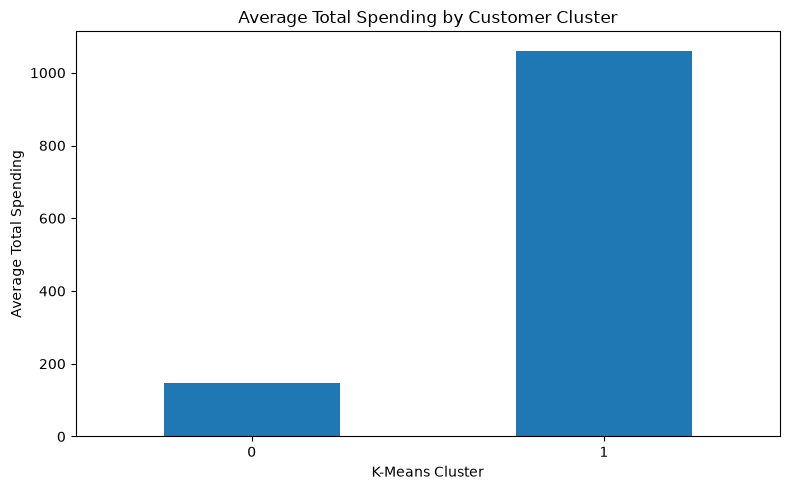

In [37]:
# ============================================================
# ACTIVITY 2.10 – TOTAL SPENDING CHART
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

spending_comparison["Total_Spending"].plot(
    kind="bar"
)

plt.title(
    "Average Total Spending by Customer Cluster"
)

plt.xlabel(
    "K-Means Cluster"
)

plt.ylabel(
    "Average Total Spending"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()

## Activity 2.11 – Product Spending Visualization

A grouped bar chart will be created to compare average spending on Wine, Fruit, Meat, Fish, Sweet, and Gold products across customer clusters.

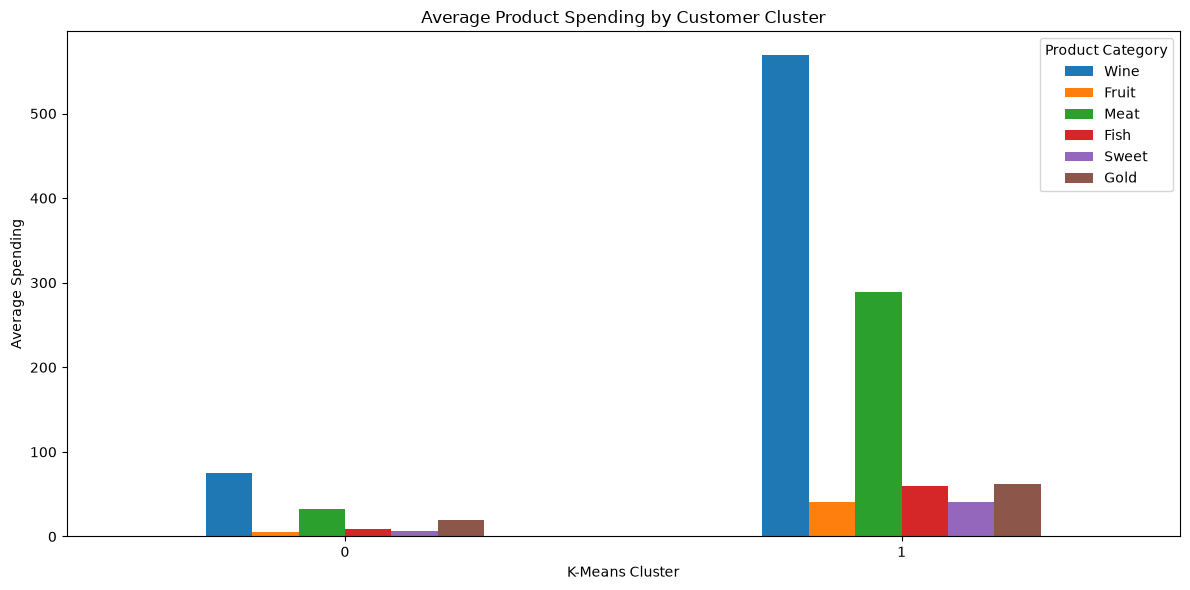

In [38]:
# ============================================================
# ACTIVITY 2.11 – PRODUCT SPENDING CHART
# ============================================================

product_chart_data = spending_comparison[
    product_features
].rename(
    columns=product_names
)

ax = product_chart_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Average Product Spending by Customer Cluster"
)

plt.xlabel(
    "K-Means Cluster"
)

plt.ylabel(
    "Average Spending"
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Product Category"
)

plt.tight_layout()

plt.show()

## Activity 2.12 – Save Spending Analysis Reports

All Activity 2 analysis results will be saved as CSV files for documentation, reproducibility, and future business interpretation.

In [39]:
# ============================================================
# ACTIVITY 2.12 – SAVE ALL REPORTS
# ============================================================

print("=" * 60)
print("ACTIVITY 2.12 – SAVE SPENDING ANALYSIS REPORTS")
print("=" * 60)

# ------------------------------------------------------------
# Save spending comparison
# ------------------------------------------------------------

spending_comparison_path = os.path.join(
    reports_dir,
    "activity_2_spending_comparison.csv"
)

spending_comparison.to_csv(
    spending_comparison_path
)

# ------------------------------------------------------------
# Save product preference
# ------------------------------------------------------------

product_preference_path = os.path.join(
    reports_dir,
    "activity_2_product_preference_percentage.csv"
)

product_preference_percentage.to_csv(
    product_preference_path
)

# ------------------------------------------------------------
# Save premium buyer analysis
# ------------------------------------------------------------

premium_path = os.path.join(
    reports_dir,
    "activity_2_premium_buyers_by_cluster.csv"
)

premium_by_cluster.to_csv(
    premium_path
)

# ------------------------------------------------------------
# Save budget-conscious analysis
# ------------------------------------------------------------

budget_path = os.path.join(
    reports_dir,
    "activity_2_budget_conscious_by_cluster.csv"
)

budget_by_cluster.to_csv(
    budget_path
)

# ------------------------------------------------------------
# Save dominant product analysis
# ------------------------------------------------------------

dominant_product_path = os.path.join(
    reports_dir,
    "activity_2_dominant_product_counts.csv"
)

dominant_product_counts.to_csv(
    dominant_product_path
)

dominant_product_percentage_path = os.path.join(
    reports_dir,
    "activity_2_dominant_product_percentages.csv"
)

dominant_product_percentages.to_csv(
    dominant_product_percentage_path
)

print("\nReports saved successfully:")

print(
    "-",
    os.path.abspath(spending_comparison_path)
)

print(
    "-",
    os.path.abspath(product_preference_path)
)

print(
    "-",
    os.path.abspath(premium_path)
)

print(
    "-",
    os.path.abspath(budget_path)
)

print(
    "-",
    os.path.abspath(dominant_product_path)
)

print(
    "-",
    os.path.abspath(dominant_product_percentage_path)
)

print("\nSTATUS: PASS")

ACTIVITY 2.12 – SAVE SPENDING ANALYSIS REPORTS

Reports saved successfully:
- d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_2_spending_comparison.csv
- d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_2_product_preference_percentage.csv
- d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_2_premium_buyers_by_cluster.csv
- d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_2_budget_conscious_by_cluster.csv
- d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_2_dominant_product_counts.csv
- d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_2_dominant_product_percentages.csv

STATUS: PASS


## Activity 2.13 – Activity 2 Completion Summary

Activity 2 analyzed the spending behavior of customers across the K-Means clusters.

The analysis included total spending, product-level spending, product preferences, high-spending customers, budget-conscious customers, and spending differences between clusters.

The generated tables, visualizations, and reports will be used in later activities for business segmentation, customer persona development, and final customer profiling.

In [40]:
# ============================================================
# ACTIVITY 2.13 – FINAL COMPLETION SUMMARY
# ============================================================

print("=" * 60)
print("ACTIVITY 2 – SPENDING BEHAVIOR ANALYSIS SUMMARY")
print("=" * 60)

print(
    "\nHighest Spending Cluster:",
    highest_spending_cluster
)

print(
    "Lowest Spending Cluster:",
    lowest_spending_cluster
)

print(
    "Premium / High-Spending Customers:",
    premium_buyer_count
)

print(
    "Budget-Conscious Customers:",
    budget_customer_count
)

print(
    "\nRequired Product Categories Analyzed:"
)

for product in product_names.values():
    print("-", product)

print(
    "\nSpending Comparison Report: PASS"
)

print(
    "Product Preference Analysis: PASS"
)

print(
    "Premium Buyer Analysis: PASS"
)

print(
    "Budget-Conscious Customer Analysis: PASS"
)

print(
    "Visualizations: PASS"
)

print(
    "Reports Saved: PASS"
)

print(
    "\nACTIVITY 2 COMPLETED SUCCESSFULLY."
)

ACTIVITY 2 – SPENDING BEHAVIOR ANALYSIS SUMMARY

Highest Spending Cluster: 1
Lowest Spending Cluster: 0
Premium / High-Spending Customers: 561
Budget-Conscious Customers: 567

Required Product Categories Analyzed:
- Wine
- Fruit
- Meat
- Fish
- Sweet
- Gold

Spending Comparison Report: PASS
Product Preference Analysis: PASS
Premium Buyer Analysis: PASS
Budget-Conscious Customer Analysis: PASS
Visualizations: PASS
Reports Saved: PASS

ACTIVITY 2 COMPLETED SUCCESSFULLY.


# Module 7 – Cluster Evaluation & Customer Profiling

## Activity 3: Shopping Channel & Customer Engagement Analysis

### Objective

The objective of this activity is to analyze customer shopping behavior and engagement across different purchasing channels.

The analysis will compare Web Purchases, Catalog Purchases, Store Purchases, Deal Purchases, Website Visits per Month, and Recency across K-Means customer clusters.

The results will be used to identify Digital-First customers, Store-Oriented customers, Catalog-Oriented customers, Deal-Seeking customers, and Active or Inactive customer segments.

## Activity 3.1 – Check Available Shopping & Engagement Features

Before performing shopping behavior analysis, the required purchasing channel and engagement variables will be checked in the customer profiling dataset.

This ensures that all variables required for Activity 3 are available.

In [41]:
# ============================================================
# ACTIVITY 3.1 – CHECK AVAILABLE SHOPPING & ENGAGEMENT FEATURES
# ============================================================

print("=" * 60)
print("ACTIVITY 3.1 – CHECK AVAILABLE FEATURES")
print("=" * 60)

required_activity3_features = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth",
    "Recency",
    "KMeans_Cluster"
]

print("\nRequired Features:")

for feature in required_activity3_features:

    if feature in profiling_df.columns:
        print(f"{feature}: AVAILABLE")
    else:
        print(f"{feature}: NOT AVAILABLE")

missing_activity3_features = [
    feature
    for feature in required_activity3_features
    if feature not in profiling_df.columns
]

if len(missing_activity3_features) == 0:

    print("\nAll required Activity 3 features are available.")
    print("STATUS: PASS")

else:

    print("\nMissing Features:")

    for feature in missing_activity3_features:
        print("-", feature)

    print("\nSTATUS: CHECK")

ACTIVITY 3.1 – CHECK AVAILABLE FEATURES

Required Features:
NumWebPurchases: AVAILABLE
NumCatalogPurchases: AVAILABLE
NumStorePurchases: AVAILABLE
NumDealsPurchases: AVAILABLE
NumWebVisitsMonth: AVAILABLE
Recency: AVAILABLE
KMeans_Cluster: AVAILABLE

All required Activity 3 features are available.
STATUS: PASS


## Activity 3.2 – Shopping Channel Comparison

The average number of Web, Catalog, Store, and Deal Purchases will be compared across K-Means customer clusters.

This analysis will identify differences in purchasing channel preferences between the customer segments.

In [42]:
# ============================================================
# ACTIVITY 3.2 – SHOPPING CHANNEL COMPARISON
# ============================================================

print("=" * 60)
print("ACTIVITY 3.2 – SHOPPING CHANNEL COMPARISON")
print("=" * 60)

channel_features = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumDealsPurchases"
]

channel_names = {
    "NumWebPurchases": "Web Purchases",
    "NumCatalogPurchases": "Catalog Purchases",
    "NumStorePurchases": "Store Purchases",
    "NumDealsPurchases": "Deal Purchases"
}

channel_comparison = (
    profiling_df
    .groupby("KMeans_Cluster")[channel_features]
    .mean()
    .round(2)
    .rename(columns=channel_names)
)

print("\nAverage Shopping Channel Activity by Cluster:")

display(channel_comparison)

print("\nSTATUS: PASS")

ACTIVITY 3.2 – SHOPPING CHANNEL COMPARISON

Average Shopping Channel Activity by Cluster:


,Web Purchases,Catalog Purchases,Store Purchases,Deal Purchases
KMeans_Cluster,,,,
0,2.67,0.73,3.58,2.56
1,5.75,4.92,8.39,2.06



STATUS: PASS


## Activity 3.3 – Preferred Shopping Channel

The dominant purchasing channel for each customer will be identified using Web, Catalog, and Store Purchases.

The dominant channel will then be summarized for each K-Means cluster.

In [43]:
# ============================================================
# ACTIVITY 3.3 – PREFERRED SHOPPING CHANNEL
# ============================================================

print("=" * 60)
print("ACTIVITY 3.3 – PREFERRED SHOPPING CHANNEL")
print("=" * 60)

main_channel_features = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

main_channel_names = {
    "NumWebPurchases": "Web",
    "NumCatalogPurchases": "Catalog",
    "NumStorePurchases": "Store"
}

profiling_df["Preferred_Channel"] = (
    profiling_df[main_channel_features]
    .idxmax(axis=1)
    .map(main_channel_names)
)

preferred_channel_counts = pd.crosstab(
    profiling_df["KMeans_Cluster"],
    profiling_df["Preferred_Channel"]
)

print("\nPreferred Channel Count by Cluster:")

display(preferred_channel_counts)

preferred_channel_percentages = (
    pd.crosstab(
        profiling_df["KMeans_Cluster"],
        profiling_df["Preferred_Channel"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

print("\nPreferred Channel Percentage by Cluster:")

display(preferred_channel_percentages)

print("\nMost Common Preferred Channel by Cluster:")

for cluster in preferred_channel_counts.index:

    top_channel = (
        preferred_channel_counts
        .loc[cluster]
        .idxmax()
    )

    count = (
        preferred_channel_counts
        .loc[cluster]
        .max()
    )

    percentage = (
        preferred_channel_percentages
        .loc[cluster, top_channel]
    )

    print(
        f"Cluster {cluster}: "
        f"{top_channel} "
        f"({count} customers, "
        f"{percentage:.2f}%)"
    )

print("\nSTATUS: PASS")

ACTIVITY 3.3 – PREFERRED SHOPPING CHANNEL

Preferred Channel Count by Cluster:


Preferred_Channel,Catalog,Store,Web
KMeans_Cluster,,,
0,15,825,367
1,144,652,234



Preferred Channel Percentage by Cluster:


Preferred_Channel,Catalog,Store,Web
KMeans_Cluster,,,
0,1.24,68.35,30.41
1,13.98,63.30,22.72



Most Common Preferred Channel by Cluster:
Cluster 0: Store (825 customers, 68.35%)
Cluster 1: Store (652 customers, 63.30%)

STATUS: PASS


## Activity 3.4 – Digital-First Customer Identification

Digital-First customers will be identified as customers whose Web Purchases are greater than both Store Purchases and Catalog Purchases.

This rule identifies customers whose purchasing activity is primarily digital through the web channel.

In [44]:
# ============================================================
# ACTIVITY 3.4 – DIGITAL-FIRST CUSTOMERS
# ============================================================

print("=" * 60)
print("ACTIVITY 3.4 – DIGITAL-FIRST CUSTOMERS")
print("=" * 60)

profiling_df["Digital_First"] = (
    (profiling_df["NumWebPurchases"] > profiling_df["NumStorePurchases"])
    &
    (profiling_df["NumWebPurchases"] > profiling_df["NumCatalogPurchases"])
)

digital_first_count = profiling_df["Digital_First"].sum()

digital_first_percentage = (
    profiling_df["Digital_First"].mean() * 100
)

print(
    "Digital-First Customers:",
    digital_first_count
)

print(
    "Percentage:",
    round(digital_first_percentage, 2),
    "%"
)

digital_first_by_cluster = (
    profiling_df
    .groupby("KMeans_Cluster")["Digital_First"]
    .agg(
        Digital_First_Count="sum",
        Digital_First_Percentage="mean"
    )
)

digital_first_by_cluster[
    "Digital_First_Percentage"
] = (
    digital_first_by_cluster[
        "Digital_First_Percentage"
    ] * 100
).round(2)

print("\nDigital-First Customers by Cluster:")

display(digital_first_by_cluster)

print("\nSTATUS: PASS")

ACTIVITY 3.4 – DIGITAL-FIRST CUSTOMERS
Digital-First Customers: 325
Percentage: 14.53 %

Digital-First Customers by Cluster:


,Digital_First_Count,Digital_First_Percentage
KMeans_Cluster,,
0,173,14.33
1,152,14.76



STATUS: PASS


## Activity 3.5 – Store-Oriented Customer Identification

Store-Oriented customers will be identified as customers whose Store Purchases are greater than both Web Purchases and Catalog Purchases.

In [45]:
# ============================================================
# ACTIVITY 3.5 – STORE-ORIENTED CUSTOMERS
# ============================================================

print("=" * 60)
print("ACTIVITY 3.5 – STORE-ORIENTED CUSTOMERS")
print("=" * 60)

profiling_df["Store_Oriented"] = (
    (profiling_df["NumStorePurchases"] > profiling_df["NumWebPurchases"])
    &
    (profiling_df["NumStorePurchases"] > profiling_df["NumCatalogPurchases"])
)

store_oriented_count = profiling_df["Store_Oriented"].sum()

store_oriented_percentage = (
    profiling_df["Store_Oriented"].mean() * 100
)

print(
    "Store-Oriented Customers:",
    store_oriented_count
)

print(
    "Percentage:",
    round(store_oriented_percentage, 2),
    "%"
)

store_oriented_by_cluster = (
    profiling_df
    .groupby("KMeans_Cluster")["Store_Oriented"]
    .agg(
        Store_Oriented_Count="sum",
        Store_Oriented_Percentage="mean"
    )
)

store_oriented_by_cluster[
    "Store_Oriented_Percentage"
] = (
    store_oriented_by_cluster[
        "Store_Oriented_Percentage"
    ] * 100
).round(2)

print("\nStore-Oriented Customers by Cluster:")

display(store_oriented_by_cluster)

print("\nSTATUS: PASS")

ACTIVITY 3.5 – STORE-ORIENTED CUSTOMERS
Store-Oriented Customers: 1477
Percentage: 66.03 %

Store-Oriented Customers by Cluster:


,Store_Oriented_Count,Store_Oriented_Percentage
KMeans_Cluster,,
0,825,68.35
1,652,63.30



STATUS: PASS


## Activity 3.6 – Catalog-Oriented Customer Identification

Catalog-Oriented customers will be identified as customers whose Catalog Purchases are greater than both Web Purchases and Store Purchases.

In [46]:
# ============================================================
# ACTIVITY 3.6 – CATALOG-ORIENTED CUSTOMERS
# ============================================================

print("=" * 60)
print("ACTIVITY 3.6 – CATALOG-ORIENTED CUSTOMERS")
print("=" * 60)

profiling_df["Catalog_Oriented"] = (
    (profiling_df["NumCatalogPurchases"] > profiling_df["NumWebPurchases"])
    &
    (profiling_df["NumCatalogPurchases"] > profiling_df["NumStorePurchases"])
)

catalog_oriented_count = profiling_df["Catalog_Oriented"].sum()

catalog_oriented_percentage = (
    profiling_df["Catalog_Oriented"].mean() * 100
)

print(
    "Catalog-Oriented Customers:",
    catalog_oriented_count
)

print(
    "Percentage:",
    round(catalog_oriented_percentage, 2),
    "%"
)

catalog_oriented_by_cluster = (
    profiling_df
    .groupby("KMeans_Cluster")["Catalog_Oriented"]
    .agg(
        Catalog_Oriented_Count="sum",
        Catalog_Oriented_Percentage="mean"
    )
)

catalog_oriented_by_cluster[
    "Catalog_Oriented_Percentage"
] = (
    catalog_oriented_by_cluster[
        "Catalog_Oriented_Percentage"
    ] * 100
).round(2)

print("\nCatalog-Oriented Customers by Cluster:")

display(catalog_oriented_by_cluster)

print("\nSTATUS: PASS")

ACTIVITY 3.6 – CATALOG-ORIENTED CUSTOMERS
Catalog-Oriented Customers: 136
Percentage: 6.08 %

Catalog-Oriented Customers by Cluster:


,Catalog_Oriented_Count,Catalog_Oriented_Percentage
KMeans_Cluster,,
0,8,0.66
1,128,12.43



STATUS: PASS


## Activity 3.7 – Deal-Seeking Customer Identification

Deal-Seeking customers will be identified using the upper quartile of NumDealsPurchases.

Customers whose Deal Purchases are at or above the 75th percentile will be classified as Deal-Seeking customers.

In [47]:
# ============================================================
# ACTIVITY 3.7 – DEAL-SEEKING CUSTOMERS
# ============================================================

print("=" * 60)
print("ACTIVITY 3.7 – DEAL-SEEKING CUSTOMERS")
print("=" * 60)

deal_threshold = (
    profiling_df["NumDealsPurchases"]
    .quantile(0.75)
)

profiling_df["Deal_Seeking"] = (
    profiling_df["NumDealsPurchases"]
    >= deal_threshold
)

deal_seeking_count = (
    profiling_df["Deal_Seeking"].sum()
)

deal_seeking_percentage = (
    profiling_df["Deal_Seeking"].mean() * 100
)

print(
    "Deal-Seeking Threshold:",
    round(deal_threshold, 2)
)

print(
    "Deal-Seeking Customers:",
    deal_seeking_count
)

print(
    "Percentage:",
    round(deal_seeking_percentage, 2),
    "%"
)

deal_seeking_by_cluster = (
    profiling_df
    .groupby("KMeans_Cluster")["Deal_Seeking"]
    .agg(
        Deal_Seeking_Count="sum",
        Deal_Seeking_Percentage="mean"
    )
)

deal_seeking_by_cluster[
    "Deal_Seeking_Percentage"
] = (
    deal_seeking_by_cluster[
        "Deal_Seeking_Percentage"
    ] * 100
).round(2)

print("\nDeal-Seeking Customers by Cluster:")

display(deal_seeking_by_cluster)

print("\nSTATUS: PASS")

ACTIVITY 3.7 – DEAL-SEEKING CUSTOMERS
Deal-Seeking Threshold: 3.0
Deal-Seeking Customers: 727
Percentage: 32.5 %

Deal-Seeking Customers by Cluster:


,Deal_Seeking_Count,Deal_Seeking_Percentage
KMeans_Cluster,,
0,446,36.95
1,281,27.28



STATUS: PASS


## Activity 3.8 – Website Engagement Analysis

Website visits per month will be compared across clusters.

Customers at or above the 75th percentile of monthly website visits will be classified as High Website Engagement customers.

In [48]:
# ============================================================
# ACTIVITY 3.8 – WEBSITE ENGAGEMENT ANALYSIS
# ============================================================

print("=" * 60)
print("ACTIVITY 3.8 – WEBSITE ENGAGEMENT ANALYSIS")
print("=" * 60)

website_threshold = (
    profiling_df["NumWebVisitsMonth"]
    .quantile(0.75)
)

profiling_df["High_Website_Engagement"] = (
    profiling_df["NumWebVisitsMonth"]
    >= website_threshold
)

high_engagement_count = (
    profiling_df["High_Website_Engagement"].sum()
)

high_engagement_percentage = (
    profiling_df["High_Website_Engagement"].mean() * 100
)

website_engagement_by_cluster = (
    profiling_df
    .groupby("KMeans_Cluster")
    .agg(
        Average_Website_Visits=(
            "NumWebVisitsMonth",
            "mean"
        ),
        High_Engagement_Count=(
            "High_Website_Engagement",
            "sum"
        ),
        High_Engagement_Percentage=(
            "High_Website_Engagement",
            "mean"
        )
    )
    .round(2)
)

website_engagement_by_cluster[
    "High_Engagement_Percentage"
] = (
    website_engagement_by_cluster[
        "High_Engagement_Percentage"
    ] * 100
).round(2)

print(
    "High Website Engagement Threshold:",
    round(website_threshold, 2)
)

print("\nWebsite Engagement by Cluster:")

display(website_engagement_by_cluster)

print("\nSTATUS: PASS")

ACTIVITY 3.8 – WEBSITE ENGAGEMENT ANALYSIS
High Website Engagement Threshold: 7.0

Website Engagement by Cluster:


,Average_Website_Visits,High_Engagement_Count,High_Engagement_Percentage
KMeans_Cluster,,,
0,6.51,680,56.0
1,3.93,150,15.0



STATUS: PASS


## Activity 3.9 – Customer Recency Analysis

Recency represents the number of days since the customer's last purchase.

Lower Recency values indicate more recent customer activity, while higher Recency values indicate customers who have been inactive for a longer period.

The average Recency will be compared across K-Means clusters.

In [49]:
# ============================================================
# ACTIVITY 3.9 – RECENCY ANALYSIS
# ============================================================

print("=" * 60)
print("ACTIVITY 3.9 – CUSTOMER RECENCY ANALYSIS")
print("=" * 60)

recency_comparison = (
    profiling_df
    .groupby("KMeans_Cluster")["Recency"]
    .agg(
        Average_Recency="mean",
        Minimum_Recency="min",
        Maximum_Recency="max"
    )
    .round(2)
)

print("\nRecency Comparison by Cluster:")

display(recency_comparison)

most_recent_cluster = (
    recency_comparison["Average_Recency"]
    .idxmin()
)

least_recent_cluster = (
    recency_comparison["Average_Recency"]
    .idxmax()
)

print(
    f"Most Recently Active Cluster: "
    f"Cluster {most_recent_cluster}"
)

print(
    f"Least Recently Active Cluster: "
    f"Cluster {least_recent_cluster}"
)

print("\nSTATUS: PASS")

ACTIVITY 3.9 – CUSTOMER RECENCY ANALYSIS

Recency Comparison by Cluster:


,Average_Recency,Minimum_Recency,Maximum_Recency
KMeans_Cluster,,,
0,48.80,0,99
1,49.46,0,99


Most Recently Active Cluster: Cluster 0
Least Recently Active Cluster: Cluster 1

STATUS: PASS


## Activity 3.10 – Active and Inactive Customer Identification

Customers will be classified according to the median Recency of the dataset.

Customers with Recency equal to or below the median will be classified as Active because they made a purchase relatively recently.

Customers with Recency above the median will be classified as Inactive because more time has passed since their last purchase.

In [50]:
# ============================================================
# ACTIVITY 3.10 – ACTIVE & INACTIVE CUSTOMERS
# ============================================================

print("=" * 60)
print("ACTIVITY 3.10 – ACTIVE & INACTIVE CUSTOMERS")
print("=" * 60)

recency_median = (
    profiling_df["Recency"]
    .median()
)

profiling_df["Customer_Activity_Status"] = np.where(
    profiling_df["Recency"] <= recency_median,
    "Active",
    "Inactive"
)

activity_status_counts = (
    profiling_df["Customer_Activity_Status"]
    .value_counts()
)

activity_status_percentages = (
    profiling_df["Customer_Activity_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(
    "Recency Median:",
    recency_median
)

print("\nCustomer Activity Counts:")

display(activity_status_counts)

print("\nCustomer Activity Percentages:")

display(activity_status_percentages)

activity_by_cluster = (
    pd.crosstab(
        profiling_df["KMeans_Cluster"],
        profiling_df["Customer_Activity_Status"]
    )
)

print("\nActivity Status by Cluster:")

display(activity_by_cluster)

activity_percentage_by_cluster = (
    pd.crosstab(
        profiling_df["KMeans_Cluster"],
        profiling_df["Customer_Activity_Status"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

print("\nActivity Percentage by Cluster:")

display(activity_percentage_by_cluster)

print("\nSTATUS: PASS")

ACTIVITY 3.10 – ACTIVE & INACTIVE CUSTOMERS
Recency Median: 49.0

Customer Activity Counts:


Customer_Activity_Status
Active      1120
Inactive    1117
Name: count, dtype: int64


Customer Activity Percentages:


Customer_Activity_Status
Active      50.07
Inactive    49.93
Name: proportion, dtype: float64


Activity Status by Cluster:


Customer_Activity_Status,Active,Inactive
KMeans_Cluster,,
0,612,595
1,508,522



Activity Percentage by Cluster:


Customer_Activity_Status,Active,Inactive
KMeans_Cluster,,
0,50.70,49.30
1,49.32,50.68



STATUS: PASS


## Activity 3.11 – Final Shopping & Engagement Comparison

The main shopping channel, website engagement, and customer recency measures will be combined into a single cluster-level comparison table.

This table provides an overall view of shopping behavior and customer engagement across the K-Means segments.

In [51]:
# ============================================================
# ACTIVITY 3.11 – FINAL SHOPPING & ENGAGEMENT COMPARISON
# ============================================================

print("=" * 60)
print("ACTIVITY 3.11 – FINAL SHOPPING & ENGAGEMENT COMPARISON")
print("=" * 60)

shopping_engagement_comparison = (
    profiling_df
    .groupby("KMeans_Cluster")
    .agg(
        Web_Purchases=(
            "NumWebPurchases",
            "mean"
        ),
        Catalog_Purchases=(
            "NumCatalogPurchases",
            "mean"
        ),
        Store_Purchases=(
            "NumStorePurchases",
            "mean"
        ),
        Deal_Purchases=(
            "NumDealsPurchases",
            "mean"
        ),
        Website_Visits=(
            "NumWebVisitsMonth",
            "mean"
        ),
        Recency=(
            "Recency",
            "mean"
        )
    )
    .round(2)
)

print("\nFinal Shopping & Engagement Comparison:")

display(shopping_engagement_comparison)

print("\nSTATUS: PASS")

ACTIVITY 3.11 – FINAL SHOPPING & ENGAGEMENT COMPARISON

Final Shopping & Engagement Comparison:


,Web_Purchases,Catalog_Purchases,Store_Purchases,Deal_Purchases,Website_Visits,Recency
KMeans_Cluster,,,,,,
0,2.67,0.73,3.58,2.56,6.51,48.80
1,5.75,4.92,8.39,2.06,3.93,49.46



STATUS: PASS


## Activity 3.12 – Shopping Channel Visualization

A grouped bar chart will be created to compare Web, Catalog, and Store Purchases across K-Means clusters.

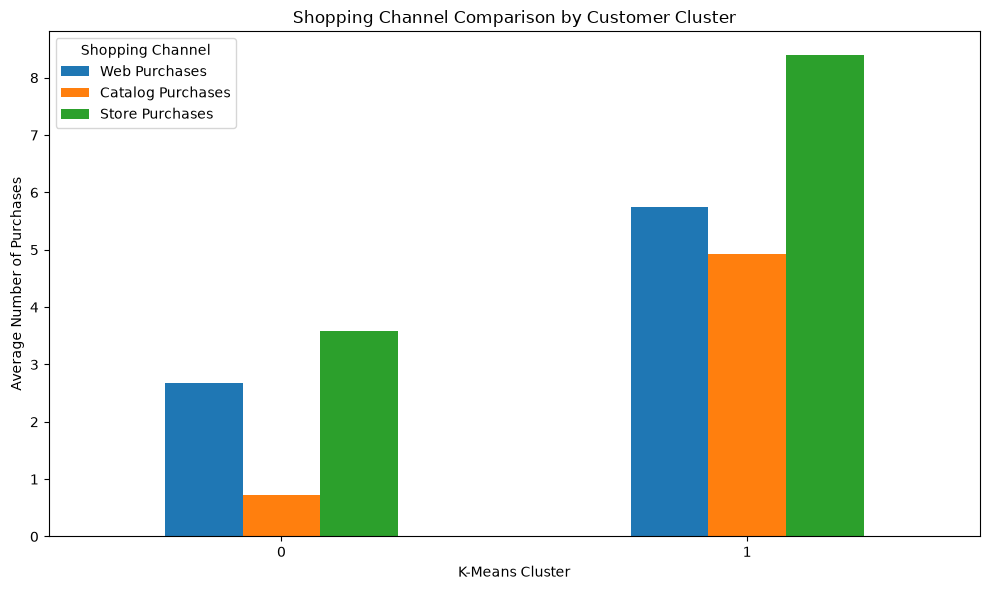

In [52]:
# ============================================================
# ACTIVITY 3.12 – SHOPPING CHANNEL CHART
# ============================================================

channel_chart_data = channel_comparison[
    [
        "Web Purchases",
        "Catalog Purchases",
        "Store Purchases"
    ]
]

ax = channel_chart_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Shopping Channel Comparison by Customer Cluster"
)

plt.xlabel(
    "K-Means Cluster"
)

plt.ylabel(
    "Average Number of Purchases"
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Shopping Channel"
)

plt.tight_layout()

plt.show()

## Activity 3.13 – Recency Comparison Visualization

A bar chart will be created to compare average customer Recency across K-Means clusters.

Lower Recency indicates more recent purchasing activity.

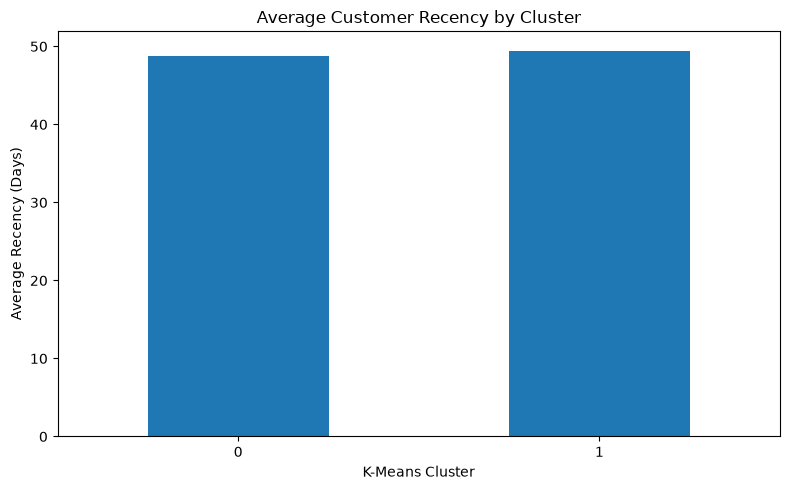

In [53]:
# ============================================================
# ACTIVITY 3.13 – RECENCY CHART
# ============================================================

plt.figure(figsize=(8, 5))

recency_comparison["Average_Recency"].plot(
    kind="bar"
)

plt.title(
    "Average Customer Recency by Cluster"
)

plt.xlabel(
    "K-Means Cluster"
)

plt.ylabel(
    "Average Recency (Days)"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()

## Activity 3.14 – Save Shopping & Engagement Reports

All Activity 3 results will be saved as CSV files for documentation, reproducibility, and use in subsequent business segmentation and persona development activities.

In [54]:
# ============================================================
# ACTIVITY 3.14 – SAVE ALL ACTIVITY 3 REPORTS
# ============================================================

print("=" * 60)
print("ACTIVITY 3.14 – SAVE ACTIVITY 3 REPORTS")
print("=" * 60)

# ------------------------------------------------------------
# Channel comparison
# ------------------------------------------------------------

channel_comparison_path = os.path.join(
    reports_dir,
    "activity_3_channel_comparison.csv"
)

channel_comparison.to_csv(
    channel_comparison_path
)

# ------------------------------------------------------------
# Preferred channel counts
# ------------------------------------------------------------

preferred_channel_counts_path = os.path.join(
    reports_dir,
    "activity_3_preferred_channel_counts.csv"
)

preferred_channel_counts.to_csv(
    preferred_channel_counts_path
)

# ------------------------------------------------------------
# Preferred channel percentages
# ------------------------------------------------------------

preferred_channel_percentages_path = os.path.join(
    reports_dir,
    "activity_3_preferred_channel_percentages.csv"
)

preferred_channel_percentages.to_csv(
    preferred_channel_percentages_path
)

# ------------------------------------------------------------
# Digital-first
# ------------------------------------------------------------

digital_first_path = os.path.join(
    reports_dir,
    "activity_3_digital_first_by_cluster.csv"
)

digital_first_by_cluster.to_csv(
    digital_first_path
)

# ------------------------------------------------------------
# Store-oriented
# ------------------------------------------------------------

store_oriented_path = os.path.join(
    reports_dir,
    "activity_3_store_oriented_by_cluster.csv"
)

store_oriented_by_cluster.to_csv(
    store_oriented_path
)

# ------------------------------------------------------------
# Catalog-oriented
# ------------------------------------------------------------

catalog_oriented_path = os.path.join(
    reports_dir,
    "activity_3_catalog_oriented_by_cluster.csv"
)

catalog_oriented_by_cluster.to_csv(
    catalog_oriented_path
)

# ------------------------------------------------------------
# Deal-seeking
# ------------------------------------------------------------

deal_seeking_path = os.path.join(
    reports_dir,
    "activity_3_deal_seeking_by_cluster.csv"
)

deal_seeking_by_cluster.to_csv(
    deal_seeking_path
)

# ------------------------------------------------------------
# Website engagement
# ------------------------------------------------------------

website_engagement_path = os.path.join(
    reports_dir,
    "activity_3_website_engagement_by_cluster.csv"
)

website_engagement_by_cluster.to_csv(
    website_engagement_path
)

# ------------------------------------------------------------
# Recency
# ------------------------------------------------------------

recency_path = os.path.join(
    reports_dir,
    "activity_3_recency_comparison.csv"
)

recency_comparison.to_csv(
    recency_path
)

# ------------------------------------------------------------
# Activity status
# ------------------------------------------------------------

activity_status_path = os.path.join(
    reports_dir,
    "activity_3_activity_status_by_cluster.csv"
)

activity_by_cluster.to_csv(
    activity_status_path
)

activity_percentage_path = os.path.join(
    reports_dir,
    "activity_3_activity_percentage_by_cluster.csv"
)

activity_percentage_by_cluster.to_csv(
    activity_percentage_path
)

# ------------------------------------------------------------
# Final comparison
# ------------------------------------------------------------

final_activity3_path = os.path.join(
    reports_dir,
    "activity_3_final_shopping_engagement_comparison.csv"
)

shopping_engagement_comparison.to_csv(
    final_activity3_path
)

print("\nReports saved successfully.")

print(
    "Channel Comparison:",
    os.path.abspath(channel_comparison_path)
)

print(
    "Preferred Channel:",
    os.path.abspath(preferred_channel_counts_path)
)

print(
    "Digital-First:",
    os.path.abspath(digital_first_path)
)

print(
    "Store-Oriented:",
    os.path.abspath(store_oriented_path)
)

print(
    "Catalog-Oriented:",
    os.path.abspath(catalog_oriented_path)
)

print(
    "Deal-Seeking:",
    os.path.abspath(deal_seeking_path)
)

print(
    "Website Engagement:",
    os.path.abspath(website_engagement_path)
)

print(
    "Recency:",
    os.path.abspath(recency_path)
)

print(
    "Activity Status:",
    os.path.abspath(activity_status_path)
)

print(
    "Final Comparison:",
    os.path.abspath(final_activity3_path)
)

print("\nSTATUS: PASS")

ACTIVITY 3.14 – SAVE ACTIVITY 3 REPORTS

Reports saved successfully.
Channel Comparison: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_3_channel_comparison.csv
Preferred Channel: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_3_preferred_channel_counts.csv
Digital-First: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_3_digital_first_by_cluster.csv
Store-Oriented: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_3_store_oriented_by_cluster.csv
Catalog-Oriented: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_3_catalog_oriented_by_cluster.csv
Deal-Seeking: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_3_deal_seeking_by_cluster.csv
Website Engagement: d:\aiLAB99\Customer-Personality-Analysis\Cluster_E

## Activity 3.15 – Activity 3 Completion Summary

Activity 3 analyzed shopping channel preferences and customer engagement across the K-Means customer clusters.

The analysis included Web Purchases, Catalog Purchases, Store Purchases, Deal Purchases, Website Visits, and Recency.

Customers were also classified into Digital-First, Store-Oriented, Catalog-Oriented, Deal-Seeking, Active, and Inactive groups using clearly defined analytical rules.

The resulting tables, visualizations, and reports will be used in the next activities for business segmentation and customer persona development.

In [55]:
# ============================================================
# ACTIVITY 3.15 – FINAL COMPLETION SUMMARY
# ============================================================

print("=" * 60)
print("ACTIVITY 3 – SHOPPING & CUSTOMER ENGAGEMENT SUMMARY")
print("=" * 60)

print(
    "\nDigital-First Customers:",
    digital_first_count
)

print(
    "Store-Oriented Customers:",
    store_oriented_count
)

print(
    "Catalog-Oriented Customers:",
    catalog_oriented_count
)

print(
    "Deal-Seeking Customers:",
    deal_seeking_count
)

print(
    "High Website Engagement Customers:",
    high_engagement_count
)

print(
    "Active Customers:",
    (
        profiling_df["Customer_Activity_Status"]
        .eq("Active")
        .sum()
    )
)

print(
    "Inactive Customers:",
    (
        profiling_df["Customer_Activity_Status"]
        .eq("Inactive")
        .sum()
    )
)

print("\nRequired Analyses:")

print("- Shopping Channel Comparison: PASS")
print("- Digital-First Identification: PASS")
print("- Store-Oriented Identification: PASS")
print("- Catalog-Oriented Identification: PASS")
print("- Deal-Seeking Identification: PASS")
print("- Website Engagement Analysis: PASS")
print("- Recency Analysis: PASS")
print("- Active/Inactive Classification: PASS")
print("- Visualizations: PASS")
print("- Reports Saved: PASS")

print(
    "\nACTIVITY 3 COMPLETED SUCCESSFULLY."
)

ACTIVITY 3 – SHOPPING & CUSTOMER ENGAGEMENT SUMMARY

Digital-First Customers: 325
Store-Oriented Customers: 1477
Catalog-Oriented Customers: 136
Deal-Seeking Customers: 727
High Website Engagement Customers: 830
Active Customers: 1120
Inactive Customers: 1117

Required Analyses:
- Shopping Channel Comparison: PASS
- Digital-First Identification: PASS
- Store-Oriented Identification: PASS
- Catalog-Oriented Identification: PASS
- Deal-Seeking Identification: PASS
- Website Engagement Analysis: PASS
- Recency Analysis: PASS
- Active/Inactive Classification: PASS
- Visualizations: PASS
- Reports Saved: PASS

ACTIVITY 3 COMPLETED SUCCESSFULLY.


# Module 7 – Cluster Evaluation & Customer Profiling

## Activity 4: Marketing Campaign Analysis

### Objective

The objective of this activity is to evaluate customer responses to previous marketing campaigns across the K-Means customer clusters.

The analysis will compare customer acceptance of Campaigns 1–5, the final campaign response, and customer complaint rates.

The results will be used to identify campaign-responsive customers, marketing-resistant customers, and customers requiring re-engagement.

## Activity 4.2 – Check Available Campaign Features

Before performing marketing campaign analysis, the required campaign acceptance, response, complaint, and cluster variables will be checked in the customer profiling dataset.

In [56]:
# ============================================================
# ACTIVITY 4.2 – CHECK AVAILABLE CAMPAIGN FEATURES
# ============================================================

print("=" * 60)
print("ACTIVITY 4.2 – CHECK AVAILABLE CAMPAIGN FEATURES")
print("=" * 60)

required_campaign_features = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response",
    "Complain",
    "KMeans_Cluster"
]

print("\nRequired Features:")

for feature in required_campaign_features:

    if feature in profiling_df.columns:
        print(f"{feature}: AVAILABLE")
    else:
        print(f"{feature}: NOT AVAILABLE")

missing_campaign_features = [
    feature
    for feature in required_campaign_features
    if feature not in profiling_df.columns
]

if len(missing_campaign_features) == 0:

    print("\nAll required campaign features are available.")
    print("STATUS: PASS")

else:

    print("\nMissing Features:")

    for feature in missing_campaign_features:
        print("-", feature)

    print("\nSTATUS: CHECK")

ACTIVITY 4.2 – CHECK AVAILABLE CAMPAIGN FEATURES

Required Features:
AcceptedCmp1: AVAILABLE
AcceptedCmp2: AVAILABLE
AcceptedCmp3: AVAILABLE
AcceptedCmp4: AVAILABLE
AcceptedCmp5: AVAILABLE
Response: AVAILABLE
Complain: AVAILABLE
KMeans_Cluster: AVAILABLE

All required campaign features are available.
STATUS: PASS


## Activity 4.3 – Campaign Acceptance Analysis

Customer acceptance of Campaigns 1–5 will be analyzed for each K-Means cluster.

The number of customers who accepted each campaign will be calculated to compare campaign responsiveness across customer segments.

In [57]:
# ============================================================
# ACTIVITY 4.3 – CAMPAIGN ACCEPTANCE COUNTS
# ============================================================

print("=" * 60)
print("ACTIVITY 4.3 – CAMPAIGN ACCEPTANCE COUNTS")
print("=" * 60)

campaign_features = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5"
]

campaign_names = {
    "AcceptedCmp1": "Campaign 1",
    "AcceptedCmp2": "Campaign 2",
    "AcceptedCmp3": "Campaign 3",
    "AcceptedCmp4": "Campaign 4",
    "AcceptedCmp5": "Campaign 5"
}

campaign_counts = (
    profiling_df
    .groupby("KMeans_Cluster")[campaign_features]
    .sum()
    .rename(columns=campaign_names)
)

print("\nCampaign Acceptance Counts by Cluster:")

display(campaign_counts)

print("\nSTATUS: PASS")

ACTIVITY 4.3 – CAMPAIGN ACCEPTANCE COUNTS

Campaign Acceptance Counts by Cluster:


,Campaign 1,Campaign 2,Campaign 3,Campaign 4,Campaign 5
KMeans_Cluster,,,,,
0,6,2,80,22,0
1,138,28,83,145,162



STATUS: PASS


## Activity 4.4 – Campaign Acceptance Rate

Campaign acceptance rates will be calculated for each campaign within each K-Means cluster.

The acceptance rate represents the percentage of customers in a cluster who accepted a particular campaign.

In [58]:
# ============================================================
# ACTIVITY 4.4 – CAMPAIGN ACCEPTANCE RATES
# ============================================================

print("=" * 60)
print("ACTIVITY 4.4 – CAMPAIGN ACCEPTANCE RATES")
print("=" * 60)

campaign_rates = (
    profiling_df
    .groupby("KMeans_Cluster")[campaign_features]
    .mean()
    .mul(100)
    .round(2)
    .rename(columns=campaign_names)
)

print("\nCampaign Acceptance Rates (%) by Cluster:")

display(campaign_rates)

print("\nSTATUS: PASS")

ACTIVITY 4.4 – CAMPAIGN ACCEPTANCE RATES

Campaign Acceptance Rates (%) by Cluster:


,Campaign 1,Campaign 2,Campaign 3,Campaign 4,Campaign 5
KMeans_Cluster,,,,,
0,0.5,0.17,6.63,1.82,0.00
1,13.4,2.72,8.06,14.08,15.73



STATUS: PASS


## Activity 4.5 – Campaign Performance Comparison

The average acceptance rate of each campaign will be compared across all customers.

The campaign with the highest overall acceptance rate will be identified as the best-performing campaign in the dataset.

In [59]:
# ============================================================
# ACTIVITY 4.5 – BEST CAMPAIGN IDENTIFICATION
# ============================================================

print("=" * 60)
print("ACTIVITY 4.5 – BEST CAMPAIGN IDENTIFICATION")
print("=" * 60)

overall_campaign_rates = (
    profiling_df[campaign_features]
    .mean()
    .mul(100)
    .round(2)
    .rename(index=campaign_names)
)

print("\nOverall Campaign Acceptance Rates:")

display(
    overall_campaign_rates.to_frame(
        name="Acceptance_Rate_Percentage"
    )
)

best_campaign = overall_campaign_rates.idxmax()

best_campaign_rate = overall_campaign_rates.max()

lowest_campaign = overall_campaign_rates.idxmin()

lowest_campaign_rate = overall_campaign_rates.min()

print(
    f"\nHighest Performing Campaign: "
    f"{best_campaign} "
    f"({best_campaign_rate:.2f}%)"
)

print(
    f"Lowest Performing Campaign: "
    f"{lowest_campaign} "
    f"({lowest_campaign_rate:.2f}%)"
)

print("\nSTATUS: PASS")

ACTIVITY 4.5 – BEST CAMPAIGN IDENTIFICATION

Overall Campaign Acceptance Rates:


,Acceptance_Rate_Percentage
Campaign 1,6.44
Campaign 2,1.34
Campaign 3,7.29
Campaign 4,7.47
Campaign 5,7.24



Highest Performing Campaign: Campaign 4 (7.47%)
Lowest Performing Campaign: Campaign 2 (1.34%)

STATUS: PASS


## Activity 4.6 – Final Campaign Response Analysis

The final campaign response variable will be analyzed across K-Means clusters.

The analysis will identify the number and percentage of customers who responded positively to the final campaign.

In [60]:
# ============================================================
# ACTIVITY 4.6 – FINAL CAMPAIGN RESPONSE
# ============================================================

print("=" * 60)
print("ACTIVITY 4.6 – FINAL CAMPAIGN RESPONSE")
print("=" * 60)

response_counts = (
    profiling_df
    .groupby("KMeans_Cluster")["Response"]
    .sum()
)

response_rates = (
    profiling_df
    .groupby("KMeans_Cluster")["Response"]
    .mean()
    .mul(100)
    .round(2)
)

final_response_comparison = pd.DataFrame({
    "Response_Count": response_counts,
    "Response_Rate_Percentage": response_rates
})

print("\nFinal Campaign Response by Cluster:")

display(final_response_comparison)

print("\nOverall Final Campaign Response:")

overall_response_count = profiling_df["Response"].sum()

overall_response_rate = (
    profiling_df["Response"].mean() * 100
)

print(
    "Responders:",
    overall_response_count
)

print(
    "Response Rate:",
    round(overall_response_rate, 2),
    "%"
)

print("\nSTATUS: PASS")

ACTIVITY 4.6 – FINAL CAMPAIGN RESPONSE

Final Campaign Response by Cluster:


,Response_Count,Response_Rate_Percentage
KMeans_Cluster,,
0,116,9.61
1,218,21.17



Overall Final Campaign Response:
Responders: 334
Response Rate: 14.93 %

STATUS: PASS


## Activity 4.7 – Customer Complaint Analysis

Customer complaints will be analyzed across K-Means clusters.

The number and percentage of customers who submitted complaints will be compared to identify clusters with relatively higher complaint levels.

In [61]:
# ============================================================
# ACTIVITY 4.7 – CUSTOMER COMPLAINT ANALYSIS
# ============================================================

print("=" * 60)
print("ACTIVITY 4.7 – CUSTOMER COMPLAINT ANALYSIS")
print("=" * 60)

complaint_counts = (
    profiling_df
    .groupby("KMeans_Cluster")["Complain"]
    .sum()
)

complaint_rates = (
    profiling_df
    .groupby("KMeans_Cluster")["Complain"]
    .mean()
    .mul(100)
    .round(2)
)

complaint_comparison = pd.DataFrame({
    "Complaint_Count": complaint_counts,
    "Complaint_Rate_Percentage": complaint_rates
})

print("\nComplaint Analysis by Cluster:")

display(complaint_comparison)

overall_complaint_count = profiling_df["Complain"].sum()

overall_complaint_rate = (
    profiling_df["Complain"].mean() * 100
)

print(
    "\nOverall Complaint Count:",
    overall_complaint_count
)

print(
    "Overall Complaint Rate:",
    round(overall_complaint_rate, 2),
    "%"
)

highest_complaint_cluster = (
    complaint_rates.idxmax()
)

print(
    f"Highest Complaint Rate: "
    f"Cluster {highest_complaint_cluster} "
    f"({complaint_rates.max():.2f}%)"
)

print("\nSTATUS: PASS")

ACTIVITY 4.7 – CUSTOMER COMPLAINT ANALYSIS

Complaint Analysis by Cluster:


,Complaint_Count,Complaint_Rate_Percentage
KMeans_Cluster,,
0,12,0.99
1,8,0.78



Overall Complaint Count: 20
Overall Complaint Rate: 0.89 %
Highest Complaint Rate: Cluster 0 (0.99%)

STATUS: PASS


## Activity 4.8 – Campaign-Responsive Customer Identification

Campaign-Responsive customers will be identified as customers who accepted at least one previous campaign or responded positively to the final campaign.

This classification identifies customers who have demonstrated measurable responsiveness to marketing activities.

In [62]:
# ============================================================
# ACTIVITY 4.8 – CAMPAIGN-RESPONSIVE CUSTOMERS
# ============================================================

print("=" * 60)
print("ACTIVITY 4.8 – CAMPAIGN-RESPONSIVE CUSTOMERS")
print("=" * 60)

profiling_df["Total_Campaign_Acceptance"] = (
    profiling_df[campaign_features]
    .sum(axis=1)
)

profiling_df["Campaign_Responsive"] = (
    (
        profiling_df["Total_Campaign_Acceptance"] > 0
    )
    |
    (
        profiling_df["Response"] == 1
    )
)

responsive_count = (
    profiling_df["Campaign_Responsive"].sum()
)

responsive_percentage = (
    profiling_df["Campaign_Responsive"].mean() * 100
)

print(
    "Campaign-Responsive Customers:",
    responsive_count
)

print(
    "Percentage:",
    round(responsive_percentage, 2),
    "%"
)

responsive_by_cluster = (
    profiling_df
    .groupby("KMeans_Cluster")["Campaign_Responsive"]
    .agg(
        Responsive_Count="sum",
        Responsive_Percentage="mean"
    )
)

responsive_by_cluster[
    "Responsive_Percentage"
] = (
    responsive_by_cluster[
        "Responsive_Percentage"
    ] * 100
).round(2)

print("\nCampaign-Responsive Customers by Cluster:")

display(responsive_by_cluster)

print("\nSTATUS: PASS")

ACTIVITY 4.8 – CAMPAIGN-RESPONSIVE CUSTOMERS
Campaign-Responsive Customers: 608
Percentage: 27.18 %

Campaign-Responsive Customers by Cluster:


,Responsive_Count,Responsive_Percentage
KMeans_Cluster,,
0,186,15.41
1,422,40.97



STATUS: PASS


## Activity 4.9 – Marketing-Resistant Customer Identification

Marketing-Resistant customers will be identified as customers who did not accept any of Campaigns 1–5 and did not respond to the final campaign.

This classification identifies customers who have shown no measurable positive response to the marketing campaigns analyzed.

In [63]:
# ============================================================
# ACTIVITY 4.9 – MARKETING-RESISTANT CUSTOMERS
# ============================================================

print("=" * 60)
print("ACTIVITY 4.9 – MARKETING-RESISTANT CUSTOMERS")
print("=" * 60)

profiling_df["Marketing_Resistant"] = (
    (
        profiling_df["Total_Campaign_Acceptance"] == 0
    )
    &
    (
        profiling_df["Response"] == 0
    )
)

resistant_count = (
    profiling_df["Marketing_Resistant"].sum()
)

resistant_percentage = (
    profiling_df["Marketing_Resistant"].mean() * 100
)

print(
    "Marketing-Resistant Customers:",
    resistant_count
)

print(
    "Percentage:",
    round(resistant_percentage, 2),
    "%"
)

resistant_by_cluster = (
    profiling_df
    .groupby("KMeans_Cluster")["Marketing_Resistant"]
    .agg(
        Resistant_Count="sum",
        Resistant_Percentage="mean"
    )
)

resistant_by_cluster[
    "Resistant_Percentage"
] = (
    resistant_by_cluster[
        "Resistant_Percentage"
    ] * 100
).round(2)

print("\nMarketing-Resistant Customers by Cluster:")

display(resistant_by_cluster)

print("\nSTATUS: PASS")

ACTIVITY 4.9 – MARKETING-RESISTANT CUSTOMERS
Marketing-Resistant Customers: 1629
Percentage: 72.82 %

Marketing-Resistant Customers by Cluster:


,Resistant_Count,Resistant_Percentage
KMeans_Cluster,,
0,1021,84.59
1,608,59.03



STATUS: PASS


## Activity 4.10 – Customers Requiring Re-Engagement

Customers requiring re-engagement will be identified using both customer inactivity and marketing resistance.

Customers with Recency above the dataset median and no positive response to any analyzed campaign will be classified as requiring re-engagement.

This group represents customers who may need targeted retention or reactivation strategies.

In [64]:
# ============================================================
# ACTIVITY 4.10 – RE-ENGAGEMENT CUSTOMERS
# ============================================================

print("=" * 60)
print("ACTIVITY 4.10 – CUSTOMERS REQUIRING RE-ENGAGEMENT")
print("=" * 60)

recency_median_activity4 = (
    profiling_df["Recency"].median()
)

profiling_df["Requires_Reengagement"] = (
    (
        profiling_df["Recency"]
        > recency_median_activity4
    )
    &
    (
        profiling_df["Marketing_Resistant"]
    )
)

reengagement_count = (
    profiling_df["Requires_Reengagement"].sum()
)

reengagement_percentage = (
    profiling_df["Requires_Reengagement"].mean()
    * 100
)

print(
    "Recency Threshold:",
    recency_median_activity4
)

print(
    "Customers Requiring Re-Engagement:",
    reengagement_count
)

print(
    "Percentage:",
    round(reengagement_percentage, 2),
    "%"
)

reengagement_by_cluster = (
    profiling_df
    .groupby("KMeans_Cluster")[
        "Requires_Reengagement"
    ]
    .agg(
        Reengagement_Count="sum",
        Reengagement_Percentage="mean"
    )
)

reengagement_by_cluster[
    "Reengagement_Percentage"
] = (
    reengagement_by_cluster[
        "Reengagement_Percentage"
    ] * 100
).round(2)

print("\nRe-Engagement Customers by Cluster:")

display(reengagement_by_cluster)

print("\nSTATUS: PASS")

ACTIVITY 4.10 – CUSTOMERS REQUIRING RE-ENGAGEMENT
Recency Threshold: 49.0
Customers Requiring Re-Engagement: 852
Percentage: 38.09 %

Re-Engagement Customers by Cluster:


,Reengagement_Count,Reengagement_Percentage
KMeans_Cluster,,
0,529,43.83
1,323,31.36



STATUS: PASS


## Activity 4.11 – Final Marketing Comparison

A consolidated comparison table will summarize campaign acceptance, final campaign response, complaints, campaign responsiveness, marketing resistance, and re-engagement requirements across K-Means clusters.

In [65]:
# ============================================================
# ACTIVITY 4.11 – FINAL MARKETING COMPARISON
# ============================================================

print("=" * 60)
print("ACTIVITY 4.11 – FINAL MARKETING COMPARISON")
print("=" * 60)

final_marketing_comparison = (
    profiling_df
    .groupby("KMeans_Cluster")
    .agg(
        Campaign_1_Acceptance=(
            "AcceptedCmp1",
            "sum"
        ),
        Campaign_2_Acceptance=(
            "AcceptedCmp2",
            "sum"
        ),
        Campaign_3_Acceptance=(
            "AcceptedCmp3",
            "sum"
        ),
        Campaign_4_Acceptance=(
            "AcceptedCmp4",
            "sum"
        ),
        Campaign_5_Acceptance=(
            "AcceptedCmp5",
            "sum"
        ),
        Final_Response_Count=(
            "Response",
            "sum"
        ),
        Complaint_Count=(
            "Complain",
            "sum"
        ),
        Campaign_Responsive_Count=(
            "Campaign_Responsive",
            "sum"
        ),
        Marketing_Resistant_Count=(
            "Marketing_Resistant",
            "sum"
        ),
        Reengagement_Count=(
            "Requires_Reengagement",
            "sum"
        )
    )
)

print("\nFinal Marketing Comparison:")

display(final_marketing_comparison)

print("\nSTATUS: PASS")

ACTIVITY 4.11 – FINAL MARKETING COMPARISON

Final Marketing Comparison:


,Campaign_1_Acceptance,Campaign_2_Acceptance,Campaign_3_Acceptance,Campaign_4_Acceptance,Campaign_5_Acceptance,Final_Response_Count,Complaint_Count,Campaign_Responsive_Count,Marketing_Resistant_Count,Reengagement_Count
KMeans_Cluster,,,,,,,,,,
0,6,2,80,22,0,116,12,186,1021,529
1,138,28,83,145,162,218,8,422,608,323



STATUS: PASS


## Activity 4.12 – Campaign Response Comparison Chart

A comparison chart will be created to visualize campaign acceptance rates across the K-Means customer clusters.

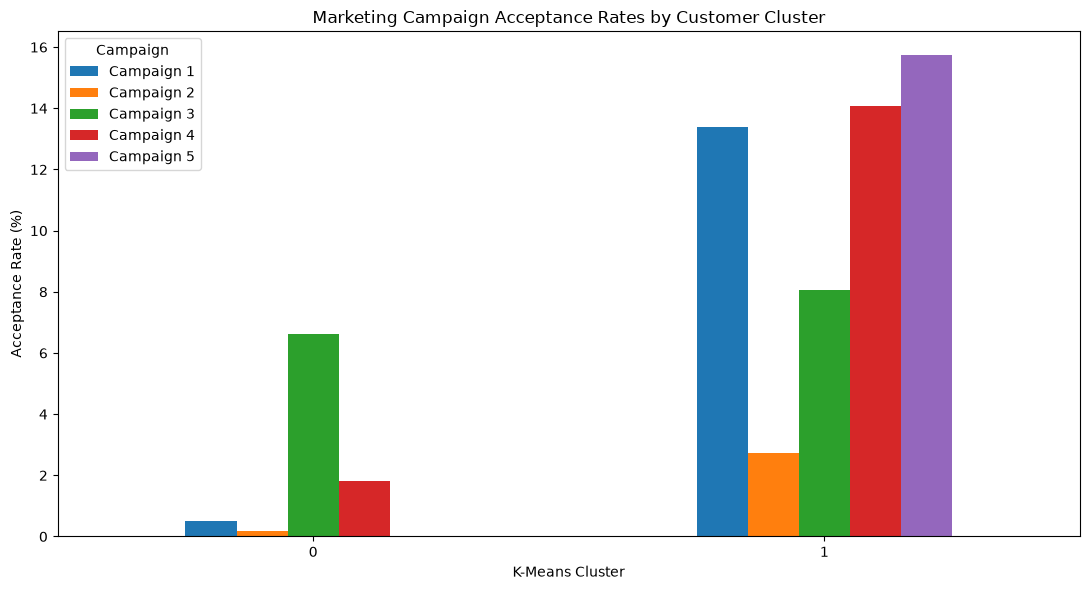

In [66]:
# ============================================================
# ACTIVITY 4.12 – CAMPAIGN RESPONSE CHART
# ============================================================

campaign_chart_data = campaign_rates.copy()

ax = campaign_chart_data.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Marketing Campaign Acceptance Rates by Customer Cluster"
)

plt.xlabel(
    "K-Means Cluster"
)

plt.ylabel(
    "Acceptance Rate (%)"
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Campaign"
)

plt.tight_layout()

plt.show()

## Activity 4.13 – Final Response and Complaint Visualization

Final campaign response rates and complaint rates will be compared across K-Means clusters.

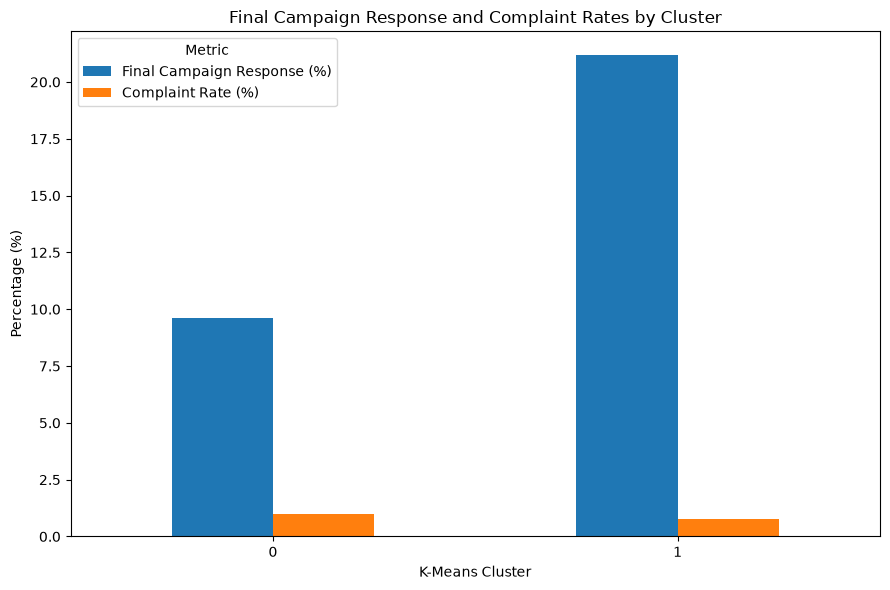

In [67]:
# ============================================================
# ACTIVITY 4.13 – RESPONSE & COMPLAINT CHART
# ============================================================

response_complaint_chart = pd.DataFrame({
    "Final Campaign Response (%)": response_rates,
    "Complaint Rate (%)": complaint_rates
})

ax = response_complaint_chart.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title(
    "Final Campaign Response and Complaint Rates by Cluster"
)

plt.xlabel(
    "K-Means Cluster"
)

plt.ylabel(
    "Percentage (%)"
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Metric"
)

plt.tight_layout()

plt.show()

## Activity 4.14 – Save Marketing Campaign Reports

All Activity 4 campaign analysis results will be saved as CSV files for documentation, reproducibility, and use in business segmentation and customer persona development.

In [68]:
# ============================================================
# ACTIVITY 4.14 – SAVE ACTIVITY 4 REPORTS
# ============================================================

print("=" * 60)
print("ACTIVITY 4.14 – SAVE MARKETING REPORTS")
print("=" * 60)

campaign_counts_path = os.path.join(
    reports_dir,
    "activity_4_campaign_acceptance_counts.csv"
)

campaign_counts.to_csv(
    campaign_counts_path
)

campaign_rates_path = os.path.join(
    reports_dir,
    "activity_4_campaign_acceptance_rates.csv"
)

campaign_rates.to_csv(
    campaign_rates_path
)

overall_campaign_rates_path = os.path.join(
    reports_dir,
    "activity_4_overall_campaign_rates.csv"
)

overall_campaign_rates.to_csv(
    overall_campaign_rates_path
)

final_response_path = os.path.join(
    reports_dir,
    "activity_4_final_campaign_response.csv"
)

final_response_comparison.to_csv(
    final_response_path
)

complaint_path = os.path.join(
    reports_dir,
    "activity_4_complaint_analysis.csv"
)

complaint_comparison.to_csv(
    complaint_path
)

responsive_path = os.path.join(
    reports_dir,
    "activity_4_campaign_responsive.csv"
)

responsive_by_cluster.to_csv(
    responsive_path
)

resistant_path = os.path.join(
    reports_dir,
    "activity_4_marketing_resistant.csv"
)

resistant_by_cluster.to_csv(
    resistant_path
)

reengagement_path = os.path.join(
    reports_dir,
    "activity_4_reengagement_customers.csv"
)

reengagement_by_cluster.to_csv(
    reengagement_path
)

final_marketing_path = os.path.join(
    reports_dir,
    "activity_4_final_marketing_comparison.csv"
)

final_marketing_comparison.to_csv(
    final_marketing_path
)

print("\nReports saved successfully.")

print(
    "Campaign Acceptance Counts:",
    os.path.abspath(campaign_counts_path)
)

print(
    "Campaign Acceptance Rates:",
    os.path.abspath(campaign_rates_path)
)

print(
    "Final Campaign Response:",
    os.path.abspath(final_response_path)
)

print(
    "Complaint Analysis:",
    os.path.abspath(complaint_path)
)

print(
    "Campaign Responsive:",
    os.path.abspath(responsive_path)
)

print(
    "Marketing Resistant:",
    os.path.abspath(resistant_path)
)

print(
    "Re-Engagement:",
    os.path.abspath(reengagement_path)
)

print(
    "Final Marketing Comparison:",
    os.path.abspath(final_marketing_path)
)

print("\nSTATUS: PASS")

ACTIVITY 4.14 – SAVE MARKETING REPORTS

Reports saved successfully.
Campaign Acceptance Counts: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_4_campaign_acceptance_counts.csv
Campaign Acceptance Rates: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_4_campaign_acceptance_rates.csv
Final Campaign Response: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_4_final_campaign_response.csv
Complaint Analysis: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_4_complaint_analysis.csv
Campaign Responsive: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_4_campaign_responsive.csv
Marketing Resistant: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_4_marketing_resistant.csv
Re-Engagement: d:\aiLAB99\Customer-Persona

## Activity 4.15 – Activity 4 Completion Summary

Activity 4 evaluated customer responses to Campaigns 1–5 and the final marketing campaign.

The analysis also examined customer complaints and classified customers into campaign-responsive, marketing-resistant, and re-engagement groups.

The resulting comparisons, visualizations, and reports provide the marketing insights required for subsequent business segmentation and customer persona development.

In [69]:
# ============================================================
# ACTIVITY 4.15 – FINAL COMPLETION SUMMARY
# ============================================================

print("=" * 60)
print("ACTIVITY 4 – MARKETING CAMPAIGN ANALYSIS SUMMARY")
print("=" * 60)

print(
    "\nCampaign-Responsive Customers:",
    responsive_count
)

print(
    "Marketing-Resistant Customers:",
    resistant_count
)

print(
    "Customers Requiring Re-Engagement:",
    reengagement_count
)

print(
    "Final Campaign Responders:",
    overall_response_count
)

print(
    "Overall Final Campaign Response Rate:",
    round(overall_response_rate, 2),
    "%"
)

print(
    "Overall Complaint Count:",
    overall_complaint_count
)

print(
    "Overall Complaint Rate:",
    round(overall_complaint_rate, 2),
    "%"
)

print(
    "\nBest Performing Campaign:",
    best_campaign
)

print(
    "Best Campaign Acceptance Rate:",
    round(best_campaign_rate, 2),
    "%"
)

print("\nRequired Analyses:")

print("- Campaign 1 Analysis: PASS")
print("- Campaign 2 Analysis: PASS")
print("- Campaign 3 Analysis: PASS")
print("- Campaign 4 Analysis: PASS")
print("- Campaign 5 Analysis: PASS")
print("- Final Campaign Response: PASS")
print("- Complaint Analysis: PASS")
print("- Campaign-Responsive Customers: PASS")
print("- Marketing-Resistant Customers: PASS")
print("- Re-Engagement Customers: PASS")
print("- Campaign Visualizations: PASS")
print("- Reports Saved: PASS")

print(
    "\nACTIVITY 4 COMPLETED SUCCESSFULLY."
)

ACTIVITY 4 – MARKETING CAMPAIGN ANALYSIS SUMMARY

Campaign-Responsive Customers: 608
Marketing-Resistant Customers: 1629
Customers Requiring Re-Engagement: 852
Final Campaign Responders: 334
Overall Final Campaign Response Rate: 14.93 %
Overall Complaint Count: 20
Overall Complaint Rate: 0.89 %

Best Performing Campaign: Campaign 4
Best Campaign Acceptance Rate: 7.47 %

Required Analyses:
- Campaign 1 Analysis: PASS
- Campaign 2 Analysis: PASS
- Campaign 3 Analysis: PASS
- Campaign 4 Analysis: PASS
- Campaign 5 Analysis: PASS
- Final Campaign Response: PASS
- Complaint Analysis: PASS
- Campaign-Responsive Customers: PASS
- Marketing-Resistant Customers: PASS
- Re-Engagement Customers: PASS
- Campaign Visualizations: PASS
- Reports Saved: PASS

ACTIVITY 4 COMPLETED SUCCESSFULLY.


# Module 7 – Cluster Evaluation & Customer Profiling

## Activity 5: Business Segmentation & Cluster Naming

### Objective

The objective of this activity is to interpret the characteristics of each K-Means customer cluster and convert the clusters into meaningful business-oriented customer segments.

The analysis will combine demographic characteristics, spending behavior, shopping channels, customer engagement, and marketing responsiveness.

Each cluster will be assigned a meaningful business name based on its observed characteristics. Suitable marketing strategies will also be recommended for each customer segment.

## Activity 5.2 – Check Required Business Profiling Features

Before assigning business segment names, the required demographic, spending, shopping, engagement, and marketing variables will be checked in the profiling dataset.

In [70]:
# ============================================================
# ACTIVITY 5.2 – CHECK REQUIRED BUSINESS FEATURES
# ============================================================

print("=" * 60)
print("ACTIVITY 5.2 – CHECK REQUIRED BUSINESS FEATURES")
print("=" * 60)

required_business_features = [
    "KMeans_Cluster",
    "Age",
    "Income",
    "Family_Size",
    "Total_Children",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "Total_Spending",
    "Total_Purchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth",
    "Recency",
    "Total_Campaign_Acceptance",
    "Response",
    "Complain",
    "Campaign_Responsive",
    "Marketing_Resistant",
    "Requires_Reengagement"
]

print("\nRequired Features:")

for feature in required_business_features:

    if feature in profiling_df.columns:
        print(f"{feature}: AVAILABLE")
    else:
        print(f"{feature}: NOT AVAILABLE")

missing_business_features = [
    feature
    for feature in required_business_features
    if feature not in profiling_df.columns
]

if len(missing_business_features) == 0:

    print("\nAll required business profiling features are available.")
    print("STATUS: PASS")

else:

    print("\nMissing Features:")

    for feature in missing_business_features:
        print("-", feature)

    print("\nSTATUS: CHECK")

ACTIVITY 5.2 – CHECK REQUIRED BUSINESS FEATURES

Required Features:
KMeans_Cluster: AVAILABLE
Age: AVAILABLE
Income: AVAILABLE
Family_Size: AVAILABLE
Total_Children: AVAILABLE
MntWines: AVAILABLE
MntFruits: AVAILABLE
MntMeatProducts: AVAILABLE
MntFishProducts: AVAILABLE
MntSweetProducts: AVAILABLE
MntGoldProds: AVAILABLE
Total_Spending: AVAILABLE
Total_Purchases: NOT AVAILABLE
NumWebPurchases: AVAILABLE
NumCatalogPurchases: AVAILABLE
NumStorePurchases: AVAILABLE
NumDealsPurchases: AVAILABLE
NumWebVisitsMonth: AVAILABLE
Recency: AVAILABLE
Total_Campaign_Acceptance: AVAILABLE
Response: AVAILABLE
Complain: AVAILABLE
Campaign_Responsive: AVAILABLE
Marketing_Resistant: AVAILABLE
Requires_Reengagement: AVAILABLE

Missing Features:
- Total_Purchases

STATUS: CHECK


In [72]:
# ============================================================
# FIX – CREATE TOTAL_PURCHASES
# ============================================================

print("=" * 60)
print("CREATING TOTAL_PURCHASES")
print("=" * 60)

purchase_columns = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

# Check that all required purchase columns exist
missing_purchase_columns = [
    col for col in purchase_columns
    if col not in profiling_df.columns
]

if len(missing_purchase_columns) > 0:

    print("Missing purchase columns:")
    for col in missing_purchase_columns:
        print("-", col)

    print("\nSTATUS: CHECK")

else:

    profiling_df["Total_Purchases"] = (
        profiling_df["NumWebPurchases"]
        + profiling_df["NumCatalogPurchases"]
        + profiling_df["NumStorePurchases"]
    )

    print(
        "Total_Purchases feature created successfully."
    )

    print(
        "Preview:"
    )

    display(
        profiling_df[
            [
                "NumWebPurchases",
                "NumCatalogPurchases",
                "NumStorePurchases",
                "Total_Purchases"
            ]
        ].head()
    )

    print("\nSTATUS: PASS")

CREATING TOTAL_PURCHASES
Total_Purchases feature created successfully.
Preview:


,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Total_Purchases
0,8,10,4,22
1,1,1,2,4
2,8,2,10,20
3,2,0,4,6
4,5,3,6,14



STATUS: PASS


## Activity 5.3 – Business Cluster Profile

A consolidated business profile will be created for each K-Means cluster.

The profile will summarize demographic characteristics, household structure, spending, purchasing channels, customer engagement, marketing responsiveness, complaints, and re-engagement requirements.

In [73]:
# ============================================================
# ACTIVITY 5.3 – CREATE BUSINESS CLUSTER PROFILE
# ============================================================

print("=" * 60)
print("ACTIVITY 5.3 – BUSINESS CLUSTER PROFILE")
print("=" * 60)

business_cluster_profile = (
    profiling_df
    .groupby("KMeans_Cluster")
    .agg(
        Customer_Count=("ID", "count"),
        Average_Age=("Age", "mean"),
        Average_Income=("Income", "mean"),
        Average_Family_Size=("Family_Size", "mean"),
        Average_Total_Children=("Total_Children", "mean"),

        Average_Total_Spending=(
            "Total_Spending",
            "mean"
        ),

        Average_Total_Purchases=(
            "Total_Purchases",
            "mean"
        ),

        Average_Wine_Spending=(
            "MntWines",
            "mean"
        ),

        Average_Fruit_Spending=(
            "MntFruits",
            "mean"
        ),

        Average_Meat_Spending=(
            "MntMeatProducts",
            "mean"
        ),

        Average_Fish_Spending=(
            "MntFishProducts",
            "mean"
        ),

        Average_Sweet_Spending=(
            "MntSweetProducts",
            "mean"
        ),

        Average_Gold_Spending=(
            "MntGoldProds",
            "mean"
        ),

        Average_Web_Purchases=(
            "NumWebPurchases",
            "mean"
        ),

        Average_Catalog_Purchases=(
            "NumCatalogPurchases",
            "mean"
        ),

        Average_Store_Purchases=(
            "NumStorePurchases",
            "mean"
        ),

        Average_Deal_Purchases=(
            "NumDealsPurchases",
            "mean"
        ),

        Average_Website_Visits=(
            "NumWebVisitsMonth",
            "mean"
        ),

        Average_Recency=(
            "Recency",
            "mean"
        ),

        Average_Campaign_Acceptance=(
            "Total_Campaign_Acceptance",
            "mean"
        ),

        Campaign_Responsive_Rate=(
            "Campaign_Responsive",
            "mean"
        ),

        Marketing_Resistant_Rate=(
            "Marketing_Resistant",
            "mean"
        ),

        Complaint_Rate=(
            "Complain",
            "mean"
        ),

        Reengagement_Rate=(
            "Requires_Reengagement",
            "mean"
        )
    )
)

percentage_columns = [
    "Campaign_Responsive_Rate",
    "Marketing_Resistant_Rate",
    "Complaint_Rate",
    "Reengagement_Rate"
]

business_cluster_profile[
    percentage_columns
] = (
    business_cluster_profile[
        percentage_columns
    ] * 100
)

business_cluster_profile = (
    business_cluster_profile
    .round(2)
)

print("\nBusiness Cluster Profile:")

display(business_cluster_profile)

print("\nSTATUS: PASS")

ACTIVITY 5.3 – BUSINESS CLUSTER PROFILE

Business Cluster Profile:


,Customer_Count,Average_Age,Average_Income,Average_Family_Size,Average_Total_Children,Average_Total_Spending,Average_Total_Purchases,Average_Wine_Spending,Average_Fruit_Spending,Average_Meat_Spending,...,Average_Catalog_Purchases,Average_Store_Purchases,Average_Deal_Purchases,Average_Website_Visits,Average_Recency,Average_Campaign_Acceptance,Campaign_Responsive_Rate,Marketing_Resistant_Rate,Complaint_Rate,Reengagement_Rate
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,
0,1207,54.3,36951.44,2.30,1.30,147.71,6.98,74.65,5.80,32.56,...,0.73,3.58,2.56,6.51,48.80,0.09,15.41,84.59,0.99,43.83
1,1030,58.2,69319.25,1.54,0.54,1060.87,19.06,568.75,40.27,289.41,...,4.92,8.39,2.06,3.93,49.46,0.54,40.97,59.03,0.78,31.36



STATUS: PASS


## Activity 5.4 – Business Value Comparison

The customer clusters will be compared using income, total spending, total purchases, and average spending-related indicators.

This comparison will help determine which cluster represents higher-value customers and which cluster represents lower-value customers.

In [74]:
# ============================================================
# ACTIVITY 5.4 – BUSINESS VALUE COMPARISON
# ============================================================

print("=" * 60)
print("ACTIVITY 5.4 – BUSINESS VALUE COMPARISON")
print("=" * 60)

business_value_columns = [
    "Average_Income",
    "Average_Total_Spending",
    "Average_Total_Purchases"
]

business_value_comparison = (
    business_cluster_profile[
        business_value_columns
    ]
    .copy()
)

print("\nBusiness Value Comparison:")

display(business_value_comparison)

highest_income_cluster = (
    business_cluster_profile[
        "Average_Income"
    ].idxmax()
)

highest_spending_cluster = (
    business_cluster_profile[
        "Average_Total_Spending"
    ].idxmax()
)

highest_purchase_cluster = (
    business_cluster_profile[
        "Average_Total_Purchases"
    ].idxmax()
)

lowest_spending_cluster = (
    business_cluster_profile[
        "Average_Total_Spending"
    ].idxmin()
)

print(
    f"\nHighest Income Cluster: "
    f"Cluster {highest_income_cluster}"
)

print(
    f"Highest Spending Cluster: "
    f"Cluster {highest_spending_cluster}"
)

print(
    f"Highest Purchase Cluster: "
    f"Cluster {highest_purchase_cluster}"
)

print(
    f"Lowest Spending Cluster: "
    f"Cluster {lowest_spending_cluster}"
)

print("\nSTATUS: PASS")

ACTIVITY 5.4 – BUSINESS VALUE COMPARISON

Business Value Comparison:


,Average_Income,Average_Total_Spending,Average_Total_Purchases
KMeans_Cluster,,,
0,36951.44,147.71,6.98
1,69319.25,1060.87,19.06



Highest Income Cluster: Cluster 1
Highest Spending Cluster: Cluster 1
Highest Purchase Cluster: Cluster 1
Lowest Spending Cluster: Cluster 0

STATUS: PASS


## Activity 5.5 – Shopping Channel Interpretation

Shopping channel behavior will be compared across clusters using Web, Catalog, Store, and Deal purchases.

The dominant purchasing channel for each cluster will be identified to support business-oriented cluster interpretation.

In [75]:
# ============================================================
# ACTIVITY 5.5 – SHOPPING CHANNEL INTERPRETATION
# ============================================================

print("=" * 60)
print("ACTIVITY 5.5 – SHOPPING CHANNEL INTERPRETATION")
print("=" * 60)

channel_columns = [
    "Average_Web_Purchases",
    "Average_Catalog_Purchases",
    "Average_Store_Purchases",
    "Average_Deal_Purchases"
]

channel_profile = (
    business_cluster_profile[
        channel_columns
    ]
    .copy()
)

print("\nShopping Channel Profile:")

display(channel_profile)

channel_names = {
    "Average_Web_Purchases": "Web",
    "Average_Catalog_Purchases": "Catalog",
    "Average_Store_Purchases": "Store",
    "Average_Deal_Purchases": "Deal"
}

dominant_channel_by_cluster = {}

for cluster in channel_profile.index:

    dominant_column = (
        channel_profile.loc[cluster]
        .idxmax()
    )

    dominant_channel = (
        channel_names[dominant_column]
    )

    dominant_channel_by_cluster[
        cluster
    ] = dominant_channel

    print(
        f"Cluster {cluster}: "
        f"{dominant_channel}-Oriented"
    )

print("\nSTATUS: PASS")

ACTIVITY 5.5 – SHOPPING CHANNEL INTERPRETATION

Shopping Channel Profile:


,Average_Web_Purchases,Average_Catalog_Purchases,Average_Store_Purchases,Average_Deal_Purchases
KMeans_Cluster,,,,
0,2.67,0.73,3.58,2.56
1,5.75,4.92,8.39,2.06


Cluster 0: Store-Oriented
Cluster 1: Store-Oriented

STATUS: PASS


## Activity 5.6 – Product Preference Analysis

Product spending patterns will be compared across clusters to identify the dominant product categories associated with each customer segment.

In [76]:
# ============================================================
# ACTIVITY 5.6 – PRODUCT PREFERENCE ANALYSIS
# ============================================================

print("=" * 60)
print("ACTIVITY 5.6 – PRODUCT PREFERENCE ANALYSIS")
print("=" * 60)

product_columns = [
    "Average_Wine_Spending",
    "Average_Fruit_Spending",
    "Average_Meat_Spending",
    "Average_Fish_Spending",
    "Average_Sweet_Spending",
    "Average_Gold_Spending"
]

product_names = {
    "Average_Wine_Spending": "Wine",
    "Average_Fruit_Spending": "Fruits",
    "Average_Meat_Spending": "Meat",
    "Average_Fish_Spending": "Fish",
    "Average_Sweet_Spending": "Sweets",
    "Average_Gold_Spending": "Gold"
}

product_profile = (
    business_cluster_profile[
        product_columns
    ]
    .copy()
)

print("\nProduct Spending Profile:")

display(product_profile)

dominant_product_by_cluster = {}

for cluster in product_profile.index:

    dominant_column = (
        product_profile.loc[cluster]
        .idxmax()
    )

    dominant_product = (
        product_names[dominant_column]
    )

    dominant_product_by_cluster[
        cluster
    ] = dominant_product

    print(
        f"Cluster {cluster}: "
        f"{dominant_product} is the dominant product category"
    )

print("\nSTATUS: PASS")

ACTIVITY 5.6 – PRODUCT PREFERENCE ANALYSIS

Product Spending Profile:


,Average_Wine_Spending,Average_Fruit_Spending,Average_Meat_Spending,Average_Fish_Spending,Average_Sweet_Spending,Average_Gold_Spending
KMeans_Cluster,,,,,,
0,74.65,5.80,32.56,8.66,5.96,20.08
1,568.75,40.27,289.41,59.58,40.66,62.20


Cluster 0: Wine is the dominant product category
Cluster 1: Wine is the dominant product category

STATUS: PASS


## Activity 5.7 – Marketing Behavior Interpretation

Marketing responsiveness, marketing resistance, customer complaints, and re-engagement requirements will be compared across customer clusters.

These indicators will help determine how each segment should be approached through marketing campaigns.

In [77]:
# ============================================================
# ACTIVITY 5.7 – MARKETING BEHAVIOR INTERPRETATION
# ============================================================

print("=" * 60)
print("ACTIVITY 5.7 – MARKETING BEHAVIOR INTERPRETATION")
print("=" * 60)

marketing_profile = business_cluster_profile[
    [
        "Average_Campaign_Acceptance",
        "Campaign_Responsive_Rate",
        "Marketing_Resistant_Rate",
        "Complaint_Rate",
        "Reengagement_Rate"
    ]
]

print("\nMarketing Profile by Cluster:")

display(marketing_profile)

highest_responsive_cluster = (
    business_cluster_profile[
        "Campaign_Responsive_Rate"
    ].idxmax()
)

highest_resistant_cluster = (
    business_cluster_profile[
        "Marketing_Resistant_Rate"
    ].idxmax()
)

highest_reengagement_cluster = (
    business_cluster_profile[
        "Reengagement_Rate"
    ].idxmax()
)

print(
    f"\nMost Campaign-Responsive Cluster: "
    f"Cluster {highest_responsive_cluster}"
)

print(
    f"Most Marketing-Resistant Cluster: "
    f"Cluster {highest_resistant_cluster}"
)

print(
    f"Highest Re-Engagement Need: "
    f"Cluster {highest_reengagement_cluster}"
)

print("\nSTATUS: PASS")

ACTIVITY 5.7 – MARKETING BEHAVIOR INTERPRETATION

Marketing Profile by Cluster:


,Average_Campaign_Acceptance,Campaign_Responsive_Rate,Marketing_Resistant_Rate,Complaint_Rate,Reengagement_Rate
KMeans_Cluster,,,,,
0,0.09,15.41,84.59,0.99,43.83
1,0.54,40.97,59.03,0.78,31.36



Most Campaign-Responsive Cluster: Cluster 1
Most Marketing-Resistant Cluster: Cluster 0
Highest Re-Engagement Need: Cluster 0

STATUS: PASS


## Activity 5.8 – Cluster Characteristic Summary

The defining characteristics of each cluster will be summarized using the business profile results.

The summary will be used as evidence for assigning meaningful business-oriented segment names.

In [78]:
# ============================================================
# ACTIVITY 5.8 – CLUSTER CHARACTERISTIC SUMMARY
# ============================================================

print("=" * 60)
print("ACTIVITY 5.8 – CLUSTER CHARACTERISTIC SUMMARY")
print("=" * 60)

cluster_characteristics = []

for cluster in business_cluster_profile.index:

    row = business_cluster_profile.loc[cluster]

    characteristics = {
        "Cluster": cluster,
        "Customer_Count": row["Customer_Count"],
        "Average_Age": row["Average_Age"],
        "Average_Income": row["Average_Income"],
        "Average_Family_Size": row["Average_Family_Size"],
        "Average_Total_Children": row["Average_Total_Children"],
        "Average_Total_Spending": row["Average_Total_Spending"],
        "Average_Total_Purchases": row["Average_Total_Purchases"],
        "Dominant_Channel": dominant_channel_by_cluster[cluster],
        "Dominant_Product": dominant_product_by_cluster[cluster],
        "Campaign_Responsive_Rate": row[
            "Campaign_Responsive_Rate"
        ],
        "Marketing_Resistant_Rate": row[
            "Marketing_Resistant_Rate"
        ],
        "Reengagement_Rate": row[
            "Reengagement_Rate"
        ]
    }

    cluster_characteristics.append(
        characteristics
    )

cluster_characteristics_df = pd.DataFrame(
    cluster_characteristics
)

print("\nCluster Characteristics:")

display(cluster_characteristics_df)

print("\nSTATUS: PASS")

ACTIVITY 5.8 – CLUSTER CHARACTERISTIC SUMMARY

Cluster Characteristics:


,Cluster,Customer_Count,Average_Age,Average_Income,Average_Family_Size,Average_Total_Children,Average_Total_Spending,Average_Total_Purchases,Dominant_Channel,Dominant_Product,Campaign_Responsive_Rate,Marketing_Resistant_Rate,Reengagement_Rate
0,0,1207.0,54.3,36951.44,2.30,1.30,147.71,6.98,Store,Wine,15.41,84.59,43.83
1,1,1030.0,58.2,69319.25,1.54,0.54,1060.87,19.06,Store,Wine,40.97,59.03,31.36



STATUS: PASS


## Activity 5.9 – Business-Oriented Cluster Naming

Based on the demographic, spending, purchasing, engagement, and marketing analysis, each K-Means cluster will be assigned a meaningful business-oriented name.

The assigned names will be supported by measurable characteristics observed in the cluster profile.

In [79]:
# ============================================================
# ACTIVITY 5.9 – BUSINESS-ORIENTED CLUSTER NAMING
# ============================================================

print("=" * 60)
print("ACTIVITY 5.9 – BUSINESS-ORIENTED CLUSTER NAMING")
print("=" * 60)

# ------------------------------------------------------------
# Identify high-value and lower-value clusters
# ------------------------------------------------------------

high_value_cluster = (
    business_cluster_profile[
        "Average_Total_Spending"
    ].idxmax()
)

lower_value_cluster = (
    business_cluster_profile[
        "Average_Total_Spending"
    ].idxmin()
)

# ------------------------------------------------------------
# Business names based on observed characteristics
# ------------------------------------------------------------

business_segment_names = {}

business_segment_names[
    high_value_cluster
] = "Premium High-Value Customers"

business_segment_names[
    lower_value_cluster
] = "Budget-Conscious Family Customers"

# ------------------------------------------------------------
# Add names to profile
# ------------------------------------------------------------

business_cluster_profile[
    "Business_Segment_Name"
] = business_cluster_profile.index.map(
    business_segment_names
)

print("\nBusiness Segment Names:")

for cluster, name in business_segment_names.items():

    print(
        f"Cluster {cluster}: {name}"
    )

print("\nSTATUS: PASS")

ACTIVITY 5.9 – BUSINESS-ORIENTED CLUSTER NAMING

Business Segment Names:
Cluster 1: Premium High-Value Customers
Cluster 0: Budget-Conscious Family Customers

STATUS: PASS


## Activity 5.10 – Cluster Name Justification

Each business segment name will be justified using the observed demographic, spending, household, shopping, and marketing characteristics of the corresponding cluster.

In [80]:
# ============================================================
# ACTIVITY 5.10 – CLUSTER NAME JUSTIFICATION
# ============================================================

print("=" * 60)
print("ACTIVITY 5.10 – CLUSTER NAME JUSTIFICATION")
print("=" * 60)

for cluster in business_cluster_profile.index:

    row = business_cluster_profile.loc[cluster]

    print("\n" + "-" * 60)

    print(
        f"Cluster {cluster}: "
        f"{row['Business_Segment_Name']}"
    )

    print(
        f"Customer Count: "
        f"{int(row['Customer_Count'])}"
    )

    print(
        f"Average Income: "
        f"{row['Average_Income']:.2f}"
    )

    print(
        f"Average Total Spending: "
        f"{row['Average_Total_Spending']:.2f}"
    )

    print(
        f"Average Total Purchases: "
        f"{row['Average_Total_Purchases']:.2f}"
    )

    print(
        f"Average Family Size: "
        f"{row['Average_Family_Size']:.2f}"
    )

    print(
        f"Average Total Children: "
        f"{row['Average_Total_Children']:.2f}"
    )

    print(
        f"Dominant Shopping Channel: "
        f"{dominant_channel_by_cluster[cluster]}"
    )

    print(
        f"Dominant Product Category: "
        f"{dominant_product_by_cluster[cluster]}"
    )

    print(
        f"Campaign Responsive Rate: "
        f"{row['Campaign_Responsive_Rate']:.2f}%"
    )

    print(
        f"Marketing Resistant Rate: "
        f"{row['Marketing_Resistant_Rate']:.2f}%"
    )

print("\nSTATUS: PASS")

ACTIVITY 5.10 – CLUSTER NAME JUSTIFICATION

------------------------------------------------------------
Cluster 0: Budget-Conscious Family Customers
Customer Count: 1207
Average Income: 36951.44
Average Total Spending: 147.71
Average Total Purchases: 6.98
Average Family Size: 2.30
Average Total Children: 1.30
Dominant Shopping Channel: Store
Dominant Product Category: Wine
Campaign Responsive Rate: 15.41%
Marketing Resistant Rate: 84.59%

------------------------------------------------------------
Cluster 1: Premium High-Value Customers
Customer Count: 1030
Average Income: 69319.25
Average Total Spending: 1060.87
Average Total Purchases: 19.06
Average Family Size: 1.54
Average Total Children: 0.54
Dominant Shopping Channel: Store
Dominant Product Category: Wine
Campaign Responsive Rate: 40.97%
Marketing Resistant Rate: 59.03%

STATUS: PASS


## Activity 5.11 – Business Recommendations

Marketing strategies will be recommended for each customer segment based on its observed business value, household characteristics, purchasing behavior, and marketing responsiveness.

In [81]:
# ============================================================
# ACTIVITY 5.11 – BUSINESS RECOMMENDATIONS
# ============================================================

print("=" * 60)
print("ACTIVITY 5.11 – BUSINESS RECOMMENDATIONS")
print("=" * 60)

business_recommendations = {}

for cluster in business_cluster_profile.index:

    row = business_cluster_profile.loc[cluster]

    segment_name = row[
        "Business_Segment_Name"
    ]

    # --------------------------------------------------------
    # High-value cluster
    # --------------------------------------------------------

    if cluster == high_value_cluster:

        recommendation = (
            "Focus on customer retention, premium offers, "
            "personalized recommendations, loyalty rewards, "
            "and cross-selling of high-value products."
        )

    # --------------------------------------------------------
    # Lower-value / family-oriented cluster
    # --------------------------------------------------------

    else:

        recommendation = (
            "Use affordable bundles, family-oriented offers, "
            "discounts, targeted promotions, and engagement "
            "campaigns to increase purchase frequency and "
            "overall customer value."
        )

    business_recommendations[
        cluster
    ] = recommendation

    print(
        f"\nCluster {cluster}: "
        f"{segment_name}"
    )

    print(
        "Recommended Strategy:",
        recommendation
    )

print("\nSTATUS: PASS")

ACTIVITY 5.11 – BUSINESS RECOMMENDATIONS

Cluster 0: Budget-Conscious Family Customers
Recommended Strategy: Use affordable bundles, family-oriented offers, discounts, targeted promotions, and engagement campaigns to increase purchase frequency and overall customer value.

Cluster 1: Premium High-Value Customers
Recommended Strategy: Focus on customer retention, premium offers, personalized recommendations, loyalty rewards, and cross-selling of high-value products.

STATUS: PASS


## Activity 5.12 – Final Business Segmentation Table

A final business segmentation table will combine the cluster name, customer count, demographic characteristics, business value, dominant shopping channel, dominant product category, marketing responsiveness, and recommended strategy.

This table will serve as the main output of Activity 5.

In [82]:
# ============================================================
# ACTIVITY 5.12 – FINAL BUSINESS SEGMENTATION TABLE
# ============================================================

print("=" * 60)
print("ACTIVITY 5.12 – FINAL BUSINESS SEGMENTATION TABLE")
print("=" * 60)

final_business_segmentation = (
    business_cluster_profile[
        [
            "Business_Segment_Name",
            "Customer_Count",
            "Average_Age",
            "Average_Income",
            "Average_Family_Size",
            "Average_Total_Children",
            "Average_Total_Spending",
            "Average_Total_Purchases",
            "Average_Web_Purchases",
            "Average_Catalog_Purchases",
            "Average_Store_Purchases",
            "Average_Deal_Purchases",
            "Average_Campaign_Acceptance",
            "Campaign_Responsive_Rate",
            "Marketing_Resistant_Rate",
            "Complaint_Rate",
            "Reengagement_Rate"
        ]
    ]
    .copy()
)

final_business_segmentation[
    "Dominant_Channel"
] = final_business_segmentation.index.map(
    dominant_channel_by_cluster
)

final_business_segmentation[
    "Dominant_Product"
] = final_business_segmentation.index.map(
    dominant_product_by_cluster
)

final_business_segmentation[
    "Recommended_Strategy"
] = final_business_segmentation.index.map(
    business_recommendations
)

print("\nFinal Business Segmentation:")

display(final_business_segmentation)

print("\nSTATUS: PASS")

ACTIVITY 5.12 – FINAL BUSINESS SEGMENTATION TABLE

Final Business Segmentation:


,Business_Segment_Name,Customer_Count,Average_Age,Average_Income,Average_Family_Size,Average_Total_Children,Average_Total_Spending,Average_Total_Purchases,Average_Web_Purchases,Average_Catalog_Purchases,Average_Store_Purchases,Average_Deal_Purchases,Average_Campaign_Acceptance,Campaign_Responsive_Rate,Marketing_Resistant_Rate,Complaint_Rate,Reengagement_Rate,Dominant_Channel,Dominant_Product,Recommended_Strategy
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,
0,Budget-Conscious Family Customers,1207,54.3,36951.44,2.30,1.30,147.71,6.98,2.67,0.73,3.58,2.56,0.09,15.41,84.59,0.99,43.83,Store,Wine,"Use affordable bundles, family-oriented offers..."
1,Premium High-Value Customers,1030,58.2,69319.25,1.54,0.54,1060.87,19.06,5.75,4.92,8.39,2.06,0.54,40.97,59.03,0.78,31.36,Store,Wine,"Focus on customer retention, premium offers, p..."



STATUS: PASS


## Activity 5.13 – Save Business Segmentation Reports

The cluster business profile, cluster characteristics, business segmentation table, and business recommendations will be saved as CSV files for final documentation and future customer persona development.

In [83]:
# ============================================================
# ACTIVITY 5.13 – SAVE ACTIVITY 5 REPORTS
# ============================================================

print("=" * 60)
print("ACTIVITY 5.13 – SAVE BUSINESS SEGMENTATION REPORTS")
print("=" * 60)

business_profile_path = os.path.join(
    reports_dir,
    "activity_5_business_cluster_profile.csv"
)

business_cluster_profile.to_csv(
    business_profile_path
)

characteristics_path = os.path.join(
    reports_dir,
    "activity_5_cluster_characteristics.csv"
)

cluster_characteristics_df.to_csv(
    characteristics_path,
    index=False
)

segmentation_path = os.path.join(
    reports_dir,
    "activity_5_final_business_segmentation.csv"
)

final_business_segmentation.to_csv(
    segmentation_path
)

recommendations_df = pd.DataFrame({
    "KMeans_Cluster": list(
        business_recommendations.keys()
    ),
    "Business_Segment_Name": [
        business_segment_names[c]
        for c in business_recommendations.keys()
    ],
    "Recommended_Strategy": list(
        business_recommendations.values()
    )
})

recommendations_path = os.path.join(
    reports_dir,
    "activity_5_business_recommendations.csv"
)

recommendations_df.to_csv(
    recommendations_path,
    index=False
)

print("\nReports Saved:")

print(
    os.path.abspath(
        business_profile_path
    )
)

print(
    os.path.abspath(
        characteristics_path
    )
)

print(
    os.path.abspath(
        segmentation_path
    )
)

print(
    os.path.abspath(
        recommendations_path
    )
)

print("\nSTATUS: PASS")

ACTIVITY 5.13 – SAVE BUSINESS SEGMENTATION REPORTS

Reports Saved:
d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_5_business_cluster_profile.csv
d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_5_cluster_characteristics.csv
d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_5_final_business_segmentation.csv
d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_5_business_recommendations.csv

STATUS: PASS


## Activity 5.14 – Activity 5 Completion Summary

Activity 5 converted the numerical K-Means clusters into meaningful business-oriented customer segments.

The clusters were interpreted using demographic characteristics, household composition, spending behavior, purchasing channels, product preferences, and marketing responsiveness.

Meaningful segment names, supporting evidence, and recommended marketing strategies were developed for each cluster.

The final business segmentation reports were saved for use in Activity 6: Customer Persona Development.

In [84]:
# ============================================================
# ACTIVITY 5.14 – FINAL COMPLETION SUMMARY
# ============================================================

print("=" * 60)
print("ACTIVITY 5 – BUSINESS SEGMENTATION SUMMARY")
print("=" * 60)

print("\nFinal Customer Segments:")

for cluster in business_cluster_profile.index:

    row = business_cluster_profile.loc[cluster]

    print(
        f"\nCluster {cluster}: "
        f"{row['Business_Segment_Name']}"
    )

    print(
        f"Customers: "
        f"{int(row['Customer_Count'])}"
    )

    print(
        f"Average Income: "
        f"{row['Average_Income']:.2f}"
    )

    print(
        f"Average Total Spending: "
        f"{row['Average_Total_Spending']:.2f}"
    )

    print(
        f"Average Total Purchases: "
        f"{row['Average_Total_Purchases']:.2f}"
    )

    print(
        f"Dominant Channel: "
        f"{dominant_channel_by_cluster[cluster]}"
    )

    print(
        f"Dominant Product: "
        f"{dominant_product_by_cluster[cluster]}"
    )

    print(
        f"Campaign Responsive: "
        f"{row['Campaign_Responsive_Rate']:.2f}%"
    )

print("\nRequired Analyses:")

print("- Cluster Characteristics: PASS")
print("- Business Value Comparison: PASS")
print("- Shopping Channel Interpretation: PASS")
print("- Product Preference Analysis: PASS")
print("- Marketing Behavior Analysis: PASS")
print("- Business Segment Naming: PASS")
print("- Cluster Name Justification: PASS")
print("- Business Recommendations: PASS")
print("- Final Segmentation Table: PASS")
print("- Reports Saved: PASS")

print(
    "\nACTIVITY 5 COMPLETED SUCCESSFULLY."
)

ACTIVITY 5 – BUSINESS SEGMENTATION SUMMARY

Final Customer Segments:

Cluster 0: Budget-Conscious Family Customers
Customers: 1207
Average Income: 36951.44
Average Total Spending: 147.71
Average Total Purchases: 6.98
Dominant Channel: Store
Dominant Product: Wine
Campaign Responsive: 15.41%

Cluster 1: Premium High-Value Customers
Customers: 1030
Average Income: 69319.25
Average Total Spending: 1060.87
Average Total Purchases: 19.06
Dominant Channel: Store
Dominant Product: Wine
Campaign Responsive: 40.97%

Required Analyses:
- Cluster Characteristics: PASS
- Business Value Comparison: PASS
- Shopping Channel Interpretation: PASS
- Product Preference Analysis: PASS
- Marketing Behavior Analysis: PASS
- Business Segment Naming: PASS
- Cluster Name Justification: PASS
- Business Recommendations: PASS
- Final Segmentation Table: PASS
- Reports Saved: PASS

ACTIVITY 5 COMPLETED SUCCESSFULLY.


# Module 7 – Cluster Evaluation & Customer Profiling

## Activity 6: Customer Persona Development

### Objective

The objective of this activity is to develop realistic customer personas representing each identified K-Means customer cluster.

Each persona will summarize the demographic characteristics, income level, family structure, shopping habits, product preferences, purchasing channels, marketing responsiveness, customer challenges, recommended marketing strategy, and estimated customer lifetime value of the corresponding customer segment.

The personas will translate the analytical cluster results into understandable customer profiles that can support marketing and business decision-making.

## Activity 6.2 – Check Required Persona Features

Before developing customer personas, the required demographic, spending, shopping, marketing, and business-value features will be checked in the final profiling dataset.

In [85]:
# ============================================================
# ACTIVITY 6.2 – CHECK REQUIRED PERSONA FEATURES
# ============================================================

print("=" * 60)
print("ACTIVITY 6.2 – CHECK REQUIRED PERSONA FEATURES")
print("=" * 60)

required_persona_features = [
    "KMeans_Cluster",
    "Age",
    "Income",
    "Family_Size",
    "Total_Children",
    "Total_Spending",
    "Total_Purchases",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth",
    "Recency",
    "Total_Campaign_Acceptance",
    "Response",
    "Complain",
    "Campaign_Responsive",
    "Marketing_Resistant",
    "Requires_Reengagement"
]

print("\nRequired Features:")

for feature in required_persona_features:

    if feature in profiling_df.columns:
        print(f"{feature}: AVAILABLE")
    else:
        print(f"{feature}: NOT AVAILABLE")

missing_persona_features = [
    feature
    for feature in required_persona_features
    if feature not in profiling_df.columns
]

if len(missing_persona_features) == 0:

    print("\nAll required persona features are available.")
    print("STATUS: PASS")

else:

    print("\nMissing Features:")

    for feature in missing_persona_features:
        print("-", feature)

    print("\nSTATUS: CHECK")

ACTIVITY 6.2 – CHECK REQUIRED PERSONA FEATURES

Required Features:
KMeans_Cluster: AVAILABLE
Age: AVAILABLE
Income: AVAILABLE
Family_Size: AVAILABLE
Total_Children: AVAILABLE
Total_Spending: AVAILABLE
Total_Purchases: AVAILABLE
MntWines: AVAILABLE
MntFruits: AVAILABLE
MntMeatProducts: AVAILABLE
MntFishProducts: AVAILABLE
MntSweetProducts: AVAILABLE
MntGoldProds: AVAILABLE
NumWebPurchases: AVAILABLE
NumCatalogPurchases: AVAILABLE
NumStorePurchases: AVAILABLE
NumDealsPurchases: AVAILABLE
NumWebVisitsMonth: AVAILABLE
Recency: AVAILABLE
Total_Campaign_Acceptance: AVAILABLE
Response: AVAILABLE
Complain: AVAILABLE
Campaign_Responsive: AVAILABLE
Marketing_Resistant: AVAILABLE
Requires_Reengagement: AVAILABLE

All required persona features are available.
STATUS: PASS


## Activity 6.3 – Calculate Persona Statistics

The main statistical characteristics of each K-Means cluster will be calculated to provide the numerical foundation for customer persona development.

In [86]:
# ============================================================
# ACTIVITY 6.3 – PERSONA STATISTICS
# ============================================================

print("=" * 60)
print("ACTIVITY 6.3 – PERSONA STATISTICS")
print("=" * 60)

persona_statistics = (
    profiling_df
    .groupby("KMeans_Cluster")
    .agg(
        Customer_Count=("ID", "count"),

        Average_Age=("Age", "mean"),
        Minimum_Age=("Age", "min"),
        Maximum_Age=("Age", "max"),

        Average_Income=("Income", "mean"),

        Average_Family_Size=(
            "Family_Size",
            "mean"
        ),

        Average_Total_Children=(
            "Total_Children",
            "mean"
        ),

        Average_Total_Spending=(
            "Total_Spending",
            "mean"
        ),

        Average_Total_Purchases=(
            "Total_Purchases",
            "mean"
        ),

        Average_Web_Purchases=(
            "NumWebPurchases",
            "mean"
        ),

        Average_Catalog_Purchases=(
            "NumCatalogPurchases",
            "mean"
        ),

        Average_Store_Purchases=(
            "NumStorePurchases",
            "mean"
        ),

        Average_Deal_Purchases=(
            "NumDealsPurchases",
            "mean"
        ),

        Average_Website_Visits=(
            "NumWebVisitsMonth",
            "mean"
        ),

        Average_Recency=(
            "Recency",
            "mean"
        ),

        Average_Campaign_Acceptance=(
            "Total_Campaign_Acceptance",
            "mean"
        ),

        Campaign_Responsive_Rate=(
            "Campaign_Responsive",
            "mean"
        ),

        Marketing_Resistant_Rate=(
            "Marketing_Resistant",
            "mean"
        ),

        Complaint_Rate=(
            "Complain",
            "mean"
        ),

        Reengagement_Rate=(
            "Requires_Reengagement",
            "mean"
        )
    )
)

percentage_columns = [
    "Campaign_Responsive_Rate",
    "Marketing_Resistant_Rate",
    "Complaint_Rate",
    "Reengagement_Rate"
]

persona_statistics[
    percentage_columns
] = (
    persona_statistics[
        percentage_columns
    ] * 100
)

persona_statistics = (
    persona_statistics.round(2)
)

print("\nPersona Statistics:")

display(persona_statistics)

print("\nSTATUS: PASS")

ACTIVITY 6.3 – PERSONA STATISTICS

Persona Statistics:


,Customer_Count,Average_Age,Minimum_Age,Maximum_Age,Average_Income,Average_Family_Size,Average_Total_Children,Average_Total_Spending,Average_Total_Purchases,Average_Web_Purchases,Average_Catalog_Purchases,Average_Store_Purchases,Average_Deal_Purchases,Average_Website_Visits,Average_Recency,Average_Campaign_Acceptance,Campaign_Responsive_Rate,Marketing_Resistant_Rate,Complaint_Rate,Reengagement_Rate
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,
0,1207,54.3,29,85,36951.44,2.30,1.30,147.71,6.98,2.67,0.73,3.58,2.56,6.51,48.80,0.09,15.41,84.59,0.99,43.83
1,1030,58.2,30,84,69319.25,1.54,0.54,1060.87,19.06,5.75,4.92,8.39,2.06,3.93,49.46,0.54,40.97,59.03,0.78,31.36



STATUS: PASS


## Activity 6.4 – Family Status Interpretation

The average family size and number of children will be used to describe the household and family characteristics of each customer persona.

In [87]:
# ============================================================
# ACTIVITY 6.4 – FAMILY STATUS INTERPRETATION
# ============================================================

print("=" * 60)
print("ACTIVITY 6.4 – FAMILY STATUS INTERPRETATION")
print("=" * 60)

family_status_by_cluster = {}

for cluster in persona_statistics.index:

    avg_family = persona_statistics.loc[
        cluster,
        "Average_Family_Size"
    ]

    avg_children = persona_statistics.loc[
        cluster,
        "Average_Total_Children"
    ]

    if avg_children >= 1:
        family_status = "Family-oriented household"
    else:
        family_status = "Smaller household"

    family_status_by_cluster[
        cluster
    ] = family_status

    print(
        f"Cluster {cluster}: "
        f"{family_status}"
    )

    print(
        f"Average Family Size: "
        f"{avg_family:.2f}"
    )

    print(
        f"Average Children: "
        f"{avg_children:.2f}"
    )

print("\nSTATUS: PASS")

ACTIVITY 6.4 – FAMILY STATUS INTERPRETATION
Cluster 0: Family-oriented household
Average Family Size: 2.30
Average Children: 1.30
Cluster 1: Smaller household
Average Family Size: 1.54
Average Children: 0.54

STATUS: PASS


## Activity 6.5 – Income Level Classification

Customer income levels will be classified relative to the average income of the identified K-Means clusters.

This classification will help describe each persona as relatively higher-income or lower-income within the analyzed customer population.

In [88]:
# ============================================================
# ACTIVITY 6.5 – INCOME LEVEL CLASSIFICATION
# ============================================================

print("=" * 60)
print("ACTIVITY 6.5 – INCOME LEVEL CLASSIFICATION")
print("=" * 60)

cluster_income_mean = (
    persona_statistics[
        "Average_Income"
    ].mean()
)

income_level_by_cluster = {}

for cluster in persona_statistics.index:

    income = persona_statistics.loc[
        cluster,
        "Average_Income"
    ]

    if income >= cluster_income_mean:
        income_level = "Higher-income"
    else:
        income_level = "Lower-income"

    income_level_by_cluster[
        cluster
    ] = income_level

    print(
        f"Cluster {cluster}: "
        f"{income_level}"
    )

    print(
        f"Average Income: "
        f"{income:.2f}"
    )

print(
    "\nCluster Average Income Reference:",
    round(cluster_income_mean, 2)
)

print("\nSTATUS: PASS")

ACTIVITY 6.5 – INCOME LEVEL CLASSIFICATION
Cluster 0: Lower-income
Average Income: 36951.44
Cluster 1: Higher-income
Average Income: 69319.25

Cluster Average Income Reference: 53135.34

STATUS: PASS


## Activity 6.6 – Shopping Habits

Web, Catalog, Store, and Deal purchases will be compared to identify the dominant shopping behavior of each customer persona.

In [89]:
# ============================================================
# ACTIVITY 6.6 – SHOPPING HABITS
# ============================================================

print("=" * 60)
print("ACTIVITY 6.6 – SHOPPING HABITS")
print("=" * 60)

shopping_columns = [
    "Average_Web_Purchases",
    "Average_Catalog_Purchases",
    "Average_Store_Purchases",
    "Average_Deal_Purchases"
]

shopping_names = {
    "Average_Web_Purchases": "Web",
    "Average_Catalog_Purchases": "Catalog",
    "Average_Store_Purchases": "Store",
    "Average_Deal_Purchases": "Deal"
}

shopping_habits_by_cluster = {}

for cluster in persona_statistics.index:

    values = persona_statistics.loc[
        cluster,
        shopping_columns
    ]

    dominant_column = values.idxmax()

    dominant_channel = shopping_names[
        dominant_column
    ]

    shopping_habits_by_cluster[
        cluster
    ] = dominant_channel

    print(
        f"Cluster {cluster}: "
        f"{dominant_channel}-oriented shopping behavior"
    )

print("\nSTATUS: PASS")

ACTIVITY 6.6 – SHOPPING HABITS
Cluster 0: Store-oriented shopping behavior
Cluster 1: Store-oriented shopping behavior

STATUS: PASS


## Activity 6.7 – Preferred Product Categories

Average spending across Wine, Fruits, Meat, Fish, Sweets, and Gold products will be compared to identify the dominant product category associated with each persona.

In [90]:
# ============================================================
# ACTIVITY 6.7 – PREFERRED PRODUCT CATEGORY
# ============================================================

print("=" * 60)
print("ACTIVITY 6.7 – PREFERRED PRODUCT CATEGORY")
print("=" * 60)

product_columns = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

product_names = {
    "MntWines": "Wine",
    "MntFruits": "Fruits",
    "MntMeatProducts": "Meat",
    "MntFishProducts": "Fish",
    "MntSweetProducts": "Sweets",
    "MntGoldProds": "Gold"
}

preferred_product_by_cluster = {}

for cluster in persona_statistics.index:

    # Calculate product means directly from profiling data
    cluster_data = profiling_df[
        profiling_df["KMeans_Cluster"] == cluster
    ]

    product_means = (
        cluster_data[
            product_columns
        ]
        .mean()
    )

    dominant_product_column = (
        product_means.idxmax()
    )

    dominant_product = product_names[
        dominant_product_column
    ]

    preferred_product_by_cluster[
        cluster
    ] = dominant_product

    print(
        f"Cluster {cluster}: "
        f"{dominant_product}"
    )

print("\nSTATUS: PASS")

ACTIVITY 6.7 – PREFERRED PRODUCT CATEGORY
Cluster 0: Wine
Cluster 1: Wine

STATUS: PASS


## Activity 6.8 – Marketing Responsiveness

Campaign acceptance and final campaign response will be used to characterize the marketing responsiveness of each customer persona.

In [91]:
# ============================================================
# ACTIVITY 6.8 – MARKETING RESPONSIVENESS
# ============================================================

print("=" * 60)
print("ACTIVITY 6.8 – MARKETING RESPONSIVENESS")
print("=" * 60)

marketing_responsiveness_by_cluster = {}

for cluster in persona_statistics.index:

    responsive_rate = persona_statistics.loc[
        cluster,
        "Campaign_Responsive_Rate"
    ]

    resistant_rate = persona_statistics.loc[
        cluster,
        "Marketing_Resistant_Rate"
    ]

    if responsive_rate >= resistant_rate:

        responsiveness = "Campaign-responsive"

    else:

        responsiveness = "Marketing-resistant"

    marketing_responsiveness_by_cluster[
        cluster
    ] = responsiveness

    print(
        f"Cluster {cluster}: "
        f"{responsiveness}"
    )

    print(
        f"Campaign Responsive Rate: "
        f"{responsive_rate:.2f}%"
    )

    print(
        f"Marketing Resistant Rate: "
        f"{resistant_rate:.2f}%"
    )

print("\nSTATUS: PASS")

ACTIVITY 6.8 – MARKETING RESPONSIVENESS
Cluster 0: Marketing-resistant
Campaign Responsive Rate: 15.41%
Marketing Resistant Rate: 84.59%
Cluster 1: Marketing-resistant
Campaign Responsive Rate: 40.97%
Marketing Resistant Rate: 59.03%

STATUS: PASS


## Activity 6.9 – Customer Challenges

Potential customer challenges will be identified using household characteristics, spending level, shopping behavior, marketing resistance, recency, and re-engagement requirements.

In [92]:
# ============================================================
# ACTIVITY 6.9 – CUSTOMER CHALLENGES
# ============================================================

print("=" * 60)
print("ACTIVITY 6.9 – CUSTOMER CHALLENGES")
print("=" * 60)

customer_challenges_by_cluster = {}

for cluster in persona_statistics.index:

    row = persona_statistics.loc[cluster]

    challenges = []

    # Lower spending
    if row["Average_Total_Spending"] < (
        persona_statistics[
            "Average_Total_Spending"
        ].mean()
    ):
        challenges.append(
            "Lower spending value"
        )

    # Marketing resistance
    if row["Marketing_Resistant_Rate"] > 50:
        challenges.append(
            "Low marketing responsiveness"
        )

    # Re-engagement
    if row["Reengagement_Rate"] > 10:
        challenges.append(
            "Requires re-engagement"
        )

    # Family-related challenge
    if row["Average_Total_Children"] >= 1:
        challenges.append(
            "Larger household needs"
        )

    # If no major challenge is detected
    if len(challenges) == 0:
        challenges.append(
            "Maintain engagement and loyalty"
        )

    customer_challenges_by_cluster[
        cluster
    ] = "; ".join(challenges)

    print(
        f"\nCluster {cluster}:"
    )

    for challenge in challenges:
        print(
            "-",
            challenge
        )

print("\nSTATUS: PASS")

ACTIVITY 6.9 – CUSTOMER CHALLENGES

Cluster 0:
- Lower spending value
- Low marketing responsiveness
- Requires re-engagement
- Larger household needs

Cluster 1:
- Low marketing responsiveness
- Requires re-engagement

STATUS: PASS


## Activity 6.10 – Recommended Marketing Strategy

A marketing strategy will be developed for each persona based on customer value, purchasing behavior, household characteristics, and marketing responsiveness.

In [93]:
# ============================================================
# ACTIVITY 6.10 – RECOMMENDED MARKETING STRATEGY
# ============================================================

print("=" * 60)
print("ACTIVITY 6.10 – RECOMMENDED MARKETING STRATEGY")
print("=" * 60)

marketing_strategy_by_cluster = {}

high_value_cluster = (
    persona_statistics[
        "Average_Total_Spending"
    ].idxmax()
)

for cluster in persona_statistics.index:

    row = persona_statistics.loc[cluster]

    if cluster == high_value_cluster:

        strategy = (
            "Use personalized premium offers, "
            "loyalty rewards, cross-selling, "
            "exclusive products, and retention campaigns."
        )

    else:

        strategy = (
            "Use value-based promotions, family bundles, "
            "discounts, product recommendations, and "
            "targeted re-engagement campaigns."
        )

    marketing_strategy_by_cluster[
        cluster
    ] = strategy

    print(
        f"\nCluster {cluster}:"
    )

    print(
        strategy
    )

print("\nSTATUS: PASS")

ACTIVITY 6.10 – RECOMMENDED MARKETING STRATEGY

Cluster 0:
Use value-based promotions, family bundles, discounts, product recommendations, and targeted re-engagement campaigns.

Cluster 1:
Use personalized premium offers, loyalty rewards, cross-selling, exclusive products, and retention campaigns.

STATUS: PASS


## Activity 6.11 – Estimated Customer Lifetime Value

A relative customer lifetime value category will be estimated using observed customer spending and purchase activity.

Because the dataset does not provide sufficient information for a true financial Customer Lifetime Value calculation, the result will be interpreted as a relative business-value estimate rather than an exact monetary CLV.

In [94]:
# ============================================================
# ACTIVITY 6.11 – RELATIVE CUSTOMER LIFETIME VALUE
# ============================================================

print("=" * 60)
print("ACTIVITY 6.11 – RELATIVE CUSTOMER LIFETIME VALUE")
print("=" * 60)

# Create a simple relative business value score
persona_statistics[
    "Business_Value_Score"
] = (
    persona_statistics[
        "Average_Total_Spending"
    ].rank(pct=True)
    +
    persona_statistics[
        "Average_Total_Purchases"
    ].rank(pct=True)
) / 2

estimated_clv_by_cluster = {}

for cluster in persona_statistics.index:

    score = persona_statistics.loc[
        cluster,
        "Business_Value_Score"
    ]

    if score >= 0.66:

        clv_category = "High Relative CLV"

    elif score >= 0.33:

        clv_category = "Medium Relative CLV"

    else:

        clv_category = "Lower Relative CLV"

    estimated_clv_by_cluster[
        cluster
    ] = clv_category

    print(
        f"Cluster {cluster}: "
        f"{clv_category}"
    )

    print(
        f"Relative Business Value Score: "
        f"{score:.3f}"
    )

print("\nSTATUS: PASS")

ACTIVITY 6.11 – RELATIVE CUSTOMER LIFETIME VALUE
Cluster 0: Medium Relative CLV
Relative Business Value Score: 0.500
Cluster 1: High Relative CLV
Relative Business Value Score: 1.000

STATUS: PASS


## Activity 6.12 – Customer Persona Names

Meaningful persona names will be assigned to each cluster using the business segment names developed in Activity 5.

In [95]:
# ============================================================
# ACTIVITY 6.12 – PERSONA NAMES
# ============================================================

print("=" * 60)
print("ACTIVITY 6.12 – PERSONA NAMES")
print("=" * 60)

persona_names_by_cluster = {}

for cluster in persona_statistics.index:

    if cluster in business_segment_names:

        persona_name = (
            business_segment_names[cluster]
        )

    else:

        persona_name = (
            f"Customer Persona {cluster}"
        )

    persona_names_by_cluster[
        cluster
    ] = persona_name

    print(
        f"Cluster {cluster}: "
        f"{persona_name}"
    )

print("\nSTATUS: PASS")

ACTIVITY 6.12 – PERSONA NAMES
Cluster 0: Budget-Conscious Family Customers
Cluster 1: Premium High-Value Customers

STATUS: PASS


## Activity 6.13 – Final Customer Persona Cards

A final persona card will be created for every K-Means cluster.

Each persona will include demographic characteristics, income, family status, shopping habits, preferred products, marketing responsiveness, customer challenges, recommended marketing strategy, and relative customer lifetime value.

In [96]:
# ============================================================
# ACTIVITY 6.13 – FINAL CUSTOMER PERSONA CARDS
# ============================================================

print("=" * 60)
print("ACTIVITY 6.13 – FINAL CUSTOMER PERSONA CARDS")
print("=" * 60)

persona_cards = []

for cluster in persona_statistics.index:

    row = persona_statistics.loc[cluster]

    # --------------------------------------------------------
    # Age range
    # --------------------------------------------------------

    age_range = (
        f"{int(row['Minimum_Age'])}–"
        f"{int(row['Maximum_Age'])} years"
    )

    # --------------------------------------------------------
    # Persona record
    # --------------------------------------------------------

    persona = {
        "KMeans_Cluster": cluster,

        "Persona_Name": (
            persona_names_by_cluster[cluster]
        ),

        "Customer_Count": int(
            row["Customer_Count"]
        ),

        "Age_Range": age_range,

        "Average_Age": round(
            row["Average_Age"],
            2
        ),

        "Income_Level": (
            income_level_by_cluster[cluster]
        ),

        "Average_Income": round(
            row["Average_Income"],
            2
        ),

        "Family_Status": (
            family_status_by_cluster[cluster]
        ),

        "Average_Family_Size": round(
            row["Average_Family_Size"],
            2
        ),

        "Average_Total_Children": round(
            row["Average_Total_Children"],
            2
        ),

        "Shopping_Habits": (
            shopping_habits_by_cluster[cluster]
        ),

        "Preferred_Product_Category": (
            preferred_product_by_cluster[cluster]
        ),

        "Average_Total_Spending": round(
            row["Average_Total_Spending"],
            2
        ),

        "Average_Total_Purchases": round(
            row["Average_Total_Purchases"],
            2
        ),

        "Marketing_Responsiveness": (
            marketing_responsiveness_by_cluster[
                cluster
            ]
        ),

        "Campaign_Responsive_Rate": round(
            row["Campaign_Responsive_Rate"],
            2
        ),

        "Marketing_Resistant_Rate": round(
            row["Marketing_Resistant_Rate"],
            2
        ),

        "Customer_Challenges": (
            customer_challenges_by_cluster[
                cluster
            ]
        ),

        "Recommended_Marketing_Strategy": (
            marketing_strategy_by_cluster[
                cluster
            ]
        ),

        "Estimated_Relative_CLV": (
            estimated_clv_by_cluster[
                cluster
            ]
        )
    }

    persona_cards.append(persona)

persona_cards_df = pd.DataFrame(
    persona_cards
)

print("\nFinal Customer Persona Cards:")

display(persona_cards_df)

print("\nSTATUS: PASS")

ACTIVITY 6.13 – FINAL CUSTOMER PERSONA CARDS

Final Customer Persona Cards:


,KMeans_Cluster,Persona_Name,Customer_Count,Age_Range,Average_Age,Income_Level,Average_Income,Family_Status,Average_Family_Size,Average_Total_Children,Shopping_Habits,Preferred_Product_Category,Average_Total_Spending,Average_Total_Purchases,Marketing_Responsiveness,Campaign_Responsive_Rate,Marketing_Resistant_Rate,Customer_Challenges,Recommended_Marketing_Strategy,Estimated_Relative_CLV
0,0,Budget-Conscious Family Customers,1207,29–85 years,54.3,Lower-income,36951.44,Family-oriented household,2.30,1.30,Store,Wine,147.71,6.98,Marketing-resistant,15.41,84.59,Lower spending value; Low marketing responsive...,"Use value-based promotions, family bundles, di...",Medium Relative CLV
1,1,Premium High-Value Customers,1030,30–84 years,58.2,Higher-income,69319.25,Smaller household,1.54,0.54,Store,Wine,1060.87,19.06,Marketing-resistant,40.97,59.03,Low marketing responsiveness; Requires re-enga...,"Use personalized premium offers, loyalty rewar...",High Relative CLV



STATUS: PASS


## Activity 6.14 – Customer Persona Report

The final persona information will be displayed in a readable format for business interpretation and documentation.

In [97]:
# ============================================================
# ACTIVITY 6.14 – DISPLAY PERSONA REPORT
# ============================================================

print("=" * 60)
print("ACTIVITY 6.14 – CUSTOMER PERSONA REPORT")
print("=" * 60)

for _, persona in persona_cards_df.iterrows():

    print("\n" + "=" * 70)

    print(
        f"PERSONA: {persona['Persona_Name']}"
    )

    print("=" * 70)

    print(
        f"Cluster: {persona['KMeans_Cluster']}"
    )

    print(
        f"Customer Count: "
        f"{persona['Customer_Count']}"
    )

    print(
        f"Age Range: "
        f"{persona['Age_Range']}"
    )

    print(
        f"Average Age: "
        f"{persona['Average_Age']}"
    )

    print(
        f"Income Level: "
        f"{persona['Income_Level']}"
    )

    print(
        f"Average Income: "
        f"{persona['Average_Income']:.2f}"
    )

    print(
        f"Family Status: "
        f"{persona['Family_Status']}"
    )

    print(
        f"Average Family Size: "
        f"{persona['Average_Family_Size']:.2f}"
    )

    print(
        f"Average Total Children: "
        f"{persona['Average_Total_Children']:.2f}"
    )

    print(
        f"Shopping Habits: "
        f"{persona['Shopping_Habits']}"
    )

    print(
        f"Preferred Product: "
        f"{persona['Preferred_Product_Category']}"
    )

    print(
        f"Average Total Spending: "
        f"{persona['Average_Total_Spending']:.2f}"
    )

    print(
        f"Average Total Purchases: "
        f"{persona['Average_Total_Purchases']:.2f}"
    )

    print(
        f"Marketing Responsiveness: "
        f"{persona['Marketing_Responsiveness']}"
    )

    print(
        f"Campaign Responsive Rate: "
        f"{persona['Campaign_Responsive_Rate']:.2f}%"
    )

    print(
        f"Marketing Resistant Rate: "
        f"{persona['Marketing_Resistant_Rate']:.2f}%"
    )

    print(
        f"Customer Challenges: "
        f"{persona['Customer_Challenges']}"
    )

    print(
        f"Recommended Strategy: "
        f"{persona['Recommended_Marketing_Strategy']}"
    )

    print(
        f"Estimated Relative CLV: "
        f"{persona['Estimated_Relative_CLV']}"
    )

print("\nSTATUS: PASS")

ACTIVITY 6.14 – CUSTOMER PERSONA REPORT

PERSONA: Budget-Conscious Family Customers
Cluster: 0
Customer Count: 1207
Age Range: 29–85 years
Average Age: 54.3
Income Level: Lower-income
Average Income: 36951.44
Family Status: Family-oriented household
Average Family Size: 2.30
Average Total Children: 1.30
Shopping Habits: Store
Preferred Product: Wine
Average Total Spending: 147.71
Average Total Purchases: 6.98
Marketing Responsiveness: Marketing-resistant
Campaign Responsive Rate: 15.41%
Marketing Resistant Rate: 84.59%
Customer Challenges: Lower spending value; Low marketing responsiveness; Requires re-engagement; Larger household needs
Recommended Strategy: Use value-based promotions, family bundles, discounts, product recommendations, and targeted re-engagement campaigns.
Estimated Relative CLV: Medium Relative CLV

PERSONA: Premium High-Value Customers
Cluster: 1
Customer Count: 1030
Age Range: 30–84 years
Average Age: 58.2
Income Level: Higher-income
Average Income: 69319.25
Family

## Activity 6.15 – Save Customer Persona Reports

The customer persona statistics and final persona cards will be saved as CSV files for documentation and future use in the final customer profiling report.

In [98]:
# ============================================================
# ACTIVITY 6.15 – SAVE CUSTOMER PERSONA REPORTS
# ============================================================

print("=" * 60)
print("ACTIVITY 6.15 – SAVE CUSTOMER PERSONA REPORTS")
print("=" * 60)

persona_statistics_path = os.path.join(
    reports_dir,
    "activity_6_persona_statistics.csv"
)

persona_statistics.to_csv(
    persona_statistics_path
)

persona_cards_path = os.path.join(
    reports_dir,
    "activity_6_customer_persona_cards.csv"
)

persona_cards_df.to_csv(
    persona_cards_path,
    index=False
)

print("\nPersona Reports Saved:")

print(
    os.path.abspath(
        persona_statistics_path
    )
)

print(
    os.path.abspath(
        persona_cards_path
    )
)

print("\nSTATUS: PASS")

ACTIVITY 6.15 – SAVE CUSTOMER PERSONA REPORTS

Persona Reports Saved:
d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_6_persona_statistics.csv
d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_6_customer_persona_cards.csv

STATUS: PASS


## Activity 6.16 – Activity 6 Completion Summary

Activity 6 developed customer personas representing each identified K-Means customer cluster.

Each persona includes demographic characteristics, income level, family status, shopping habits, preferred product categories, marketing responsiveness, customer challenges, recommended marketing strategy, and estimated relative customer lifetime value.

The persona cards and supporting statistics were saved for final documentation and business interpretation.

In [99]:
# ============================================================
# ACTIVITY 6.16 – FINAL COMPLETION SUMMARY
# ============================================================

print("=" * 60)
print("ACTIVITY 6 – CUSTOMER PERSONA DEVELOPMENT")
print("=" * 60)

print(
    "\nNumber of Personas Created:",
    len(persona_cards_df)
)

for _, persona in persona_cards_df.iterrows():

    print(
        f"\nCluster {persona['KMeans_Cluster']}: "
        f"{persona['Persona_Name']}"
    )

    print(
        f"Customers: "
        f"{persona['Customer_Count']}"
    )

    print(
        f"Income Level: "
        f"{persona['Income_Level']}"
    )

    print(
        f"Shopping Behavior: "
        f"{persona['Shopping_Habits']}"
    )

    print(
        f"Preferred Product: "
        f"{persona['Preferred_Product_Category']}"
    )

    print(
        f"Marketing Response: "
        f"{persona['Marketing_Responsiveness']}"
    )

    print(
        f"Relative CLV: "
        f"{persona['Estimated_Relative_CLV']}"
    )

print("\nRequired Analyses:")

print("- Persona Name: PASS")
print("- Age Range: PASS")
print("- Income Level: PASS")
print("- Family Status: PASS")
print("- Shopping Habits: PASS")
print("- Preferred Product Categories: PASS")
print("- Preferred Purchasing Channel: PASS")
print("- Marketing Responsiveness: PASS")
print("- Customer Challenges: PASS")
print("- Recommended Marketing Strategy: PASS")
print("- Estimated Relative Customer Lifetime Value: PASS")
print("- Persona Cards Created: PASS")
print("- Reports Saved: PASS")

print(
    "\nACTIVITY 6 COMPLETED SUCCESSFULLY."
)

ACTIVITY 6 – CUSTOMER PERSONA DEVELOPMENT

Number of Personas Created: 2

Cluster 0: Budget-Conscious Family Customers
Customers: 1207
Income Level: Lower-income
Shopping Behavior: Store
Preferred Product: Wine
Marketing Response: Marketing-resistant
Relative CLV: Medium Relative CLV

Cluster 1: Premium High-Value Customers
Customers: 1030
Income Level: Higher-income
Shopping Behavior: Store
Preferred Product: Wine
Marketing Response: Marketing-resistant
Relative CLV: High Relative CLV

Required Analyses:
- Persona Name: PASS
- Age Range: PASS
- Income Level: PASS
- Family Status: PASS
- Shopping Habits: PASS
- Preferred Product Categories: PASS
- Preferred Purchasing Channel: PASS
- Marketing Responsiveness: PASS
- Customer Challenges: PASS
- Recommended Marketing Strategy: PASS
- Estimated Relative Customer Lifetime Value: PASS
- Persona Cards Created: PASS
- Reports Saved: PASS

ACTIVITY 6 COMPLETED SUCCESSFULLY.


# Module 7 – Cluster Evaluation & Customer Profiling

## Activity 7: Cluster Visualization & Final Documentation

### Objective

The objective of this activity is to create professional visualizations that summarize the demographic, spending, purchasing, engagement, and marketing characteristics of the identified customer clusters.

The visualizations will support the final interpretation of customer segments and provide clear graphical evidence for business recommendations.

## Activity 7.2 – Check Required Visualization Features

Before creating the visualizations, all required variables and cluster labels will be checked to ensure that the final profiling dataset is ready for visualization.

In [100]:
# ============================================================
# ACTIVITY 7.2 – CHECK REQUIRED VISUALIZATION FEATURES
# ============================================================

print("=" * 60)
print("ACTIVITY 7.2 – CHECK REQUIRED VISUALIZATION FEATURES")
print("=" * 60)

required_visualization_features = [
    "KMeans_Cluster",
    "Income",
    "Total_Spending",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumDealsPurchases",
    "Total_Campaign_Acceptance",
    "Response",
    "Recency"
]

missing_visualization_features = []

for feature in required_visualization_features:

    if feature in profiling_df.columns:

        print(f"{feature}: AVAILABLE")

    else:

        print(f"{feature}: NOT AVAILABLE")
        missing_visualization_features.append(feature)


if len(missing_visualization_features) == 0:

    print("\nAll required visualization features are available.")
    print("STATUS: PASS")

else:

    print("\nMissing Features:")

    for feature in missing_visualization_features:
        print("-", feature)

    print("\nSTATUS: CHECK")

ACTIVITY 7.2 – CHECK REQUIRED VISUALIZATION FEATURES
KMeans_Cluster: AVAILABLE
Income: AVAILABLE
Total_Spending: AVAILABLE
MntWines: AVAILABLE
MntFruits: AVAILABLE
MntMeatProducts: AVAILABLE
MntFishProducts: AVAILABLE
MntSweetProducts: AVAILABLE
MntGoldProds: AVAILABLE
NumWebPurchases: AVAILABLE
NumCatalogPurchases: AVAILABLE
NumStorePurchases: AVAILABLE
NumDealsPurchases: AVAILABLE
Total_Campaign_Acceptance: AVAILABLE
Response: AVAILABLE
Recency: AVAILABLE

All required visualization features are available.
STATUS: PASS


In [101]:
# ============================================================
# ACTIVITY 7.3 – CREATE VISUALIZATION OUTPUT FOLDER
# ============================================================

print("=" * 60)
print("ACTIVITY 7.3 – CREATE VISUALIZATION OUTPUT FOLDER")
print("=" * 60)

visualization_dir = os.path.join(
    reports_dir,
    "activity_7_visualizations"
)

os.makedirs(
    visualization_dir,
    exist_ok=True
)

print(
    "Visualization folder:",
    os.path.abspath(visualization_dir)
)

print("\nSTATUS: PASS")

ACTIVITY 7.3 – CREATE VISUALIZATION OUTPUT FOLDER
Visualization folder: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_7_visualizations

STATUS: PASS


## Activity 7.4 – Cluster Distribution Chart

A cluster distribution chart will be created to show the number and percentage of customers belonging to each K-Means cluster.

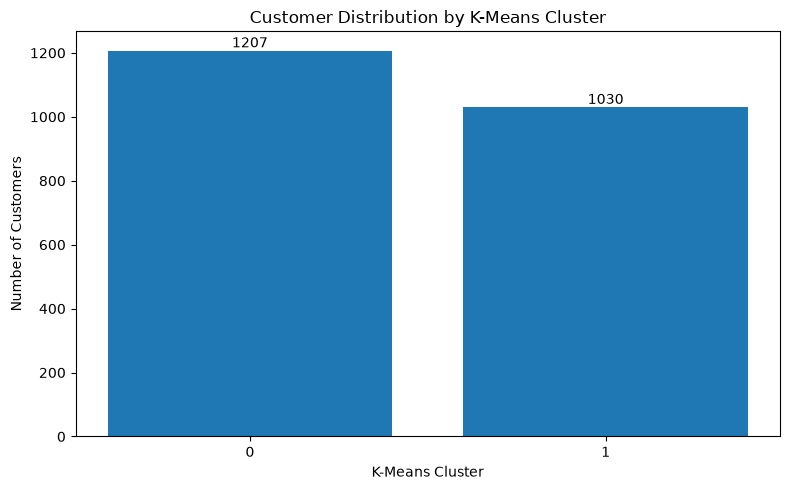

Saved: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_7_visualizations\01_cluster_distribution.png
STATUS: PASS


In [102]:
# ============================================================
# ACTIVITY 7.4 – CLUSTER DISTRIBUTION CHART
# ============================================================

cluster_counts = (
    profiling_df["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title("Customer Distribution by K-Means Cluster")
plt.xlabel("K-Means Cluster")
plt.ylabel("Number of Customers")

for bar, value in zip(
    bars,
    cluster_counts.values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

cluster_distribution_path = os.path.join(
    visualization_dir,
    "01_cluster_distribution.png"
)

plt.savefig(
    cluster_distribution_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    os.path.abspath(cluster_distribution_path)
)

print("STATUS: PASS")

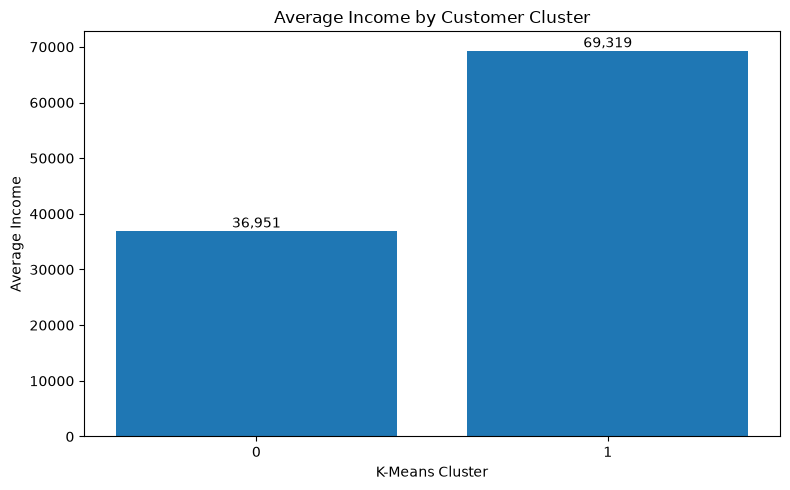

Saved: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_7_visualizations\02_income_comparison.png
STATUS: PASS


In [103]:
# ============================================================
# ACTIVITY 7.5 – INCOME COMPARISON
# ============================================================

income_comparison = (
    profiling_df
    .groupby("KMeans_Cluster")["Income"]
    .mean()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    income_comparison.index.astype(str),
    income_comparison.values
)

plt.title("Average Income by Customer Cluster")
plt.xlabel("K-Means Cluster")
plt.ylabel("Average Income")

for bar, value in zip(
    bars,
    income_comparison.values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

income_chart_path = os.path.join(
    visualization_dir,
    "02_income_comparison.png"
)

plt.savefig(
    income_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    os.path.abspath(income_chart_path)
)

print("STATUS: PASS")

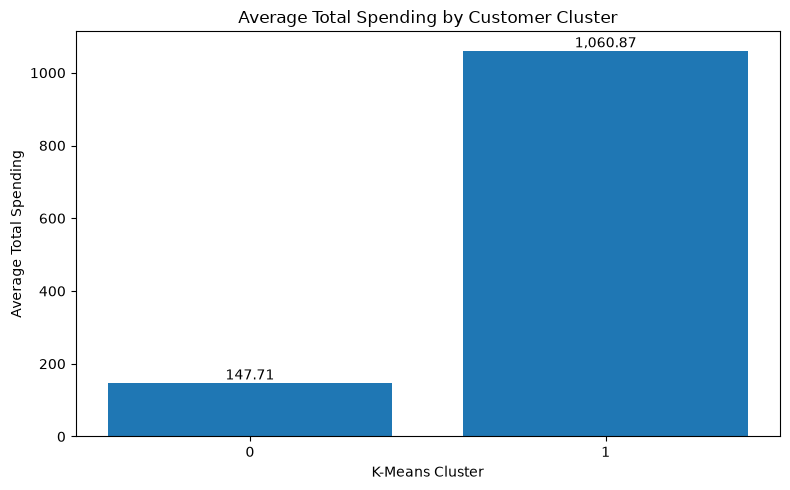

Saved: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_7_visualizations\03_spending_comparison.png
STATUS: PASS


In [104]:
# ============================================================
# ACTIVITY 7.6 – TOTAL SPENDING COMPARISON
# ============================================================

spending_comparison = (
    profiling_df
    .groupby("KMeans_Cluster")["Total_Spending"]
    .mean()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    spending_comparison.index.astype(str),
    spending_comparison.values
)

plt.title("Average Total Spending by Customer Cluster")
plt.xlabel("K-Means Cluster")
plt.ylabel("Average Total Spending")

for bar, value in zip(
    bars,
    spending_comparison.values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

spending_chart_path = os.path.join(
    visualization_dir,
    "03_spending_comparison.png"
)

plt.savefig(
    spending_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    os.path.abspath(spending_chart_path)
)

print("STATUS: PASS")

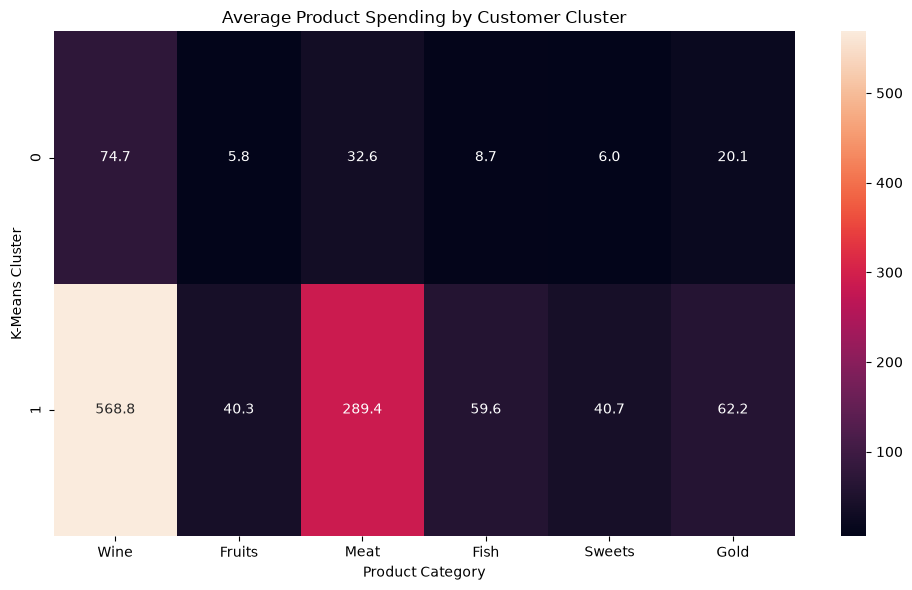

Saved: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_7_visualizations\04_product_preference_heatmap.png
STATUS: PASS


In [105]:
# ============================================================
# ACTIVITY 7.7 – PRODUCT PREFERENCE HEATMAP
# ============================================================

product_features = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

product_labels = [
    "Wine",
    "Fruits",
    "Meat",
    "Fish",
    "Sweets",
    "Gold"
]

product_heatmap = (
    profiling_df
    .groupby("KMeans_Cluster")[product_features]
    .mean()
)

product_heatmap.columns = product_labels

plt.figure(figsize=(10, 6))

sns.heatmap(
    product_heatmap,
    annot=True,
    fmt=".1f"
)

plt.title("Average Product Spending by Customer Cluster")
plt.xlabel("Product Category")
plt.ylabel("K-Means Cluster")

plt.tight_layout()

product_heatmap_path = os.path.join(
    visualization_dir,
    "04_product_preference_heatmap.png"
)

plt.savefig(
    product_heatmap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    os.path.abspath(product_heatmap_path)
)

print("STATUS: PASS")

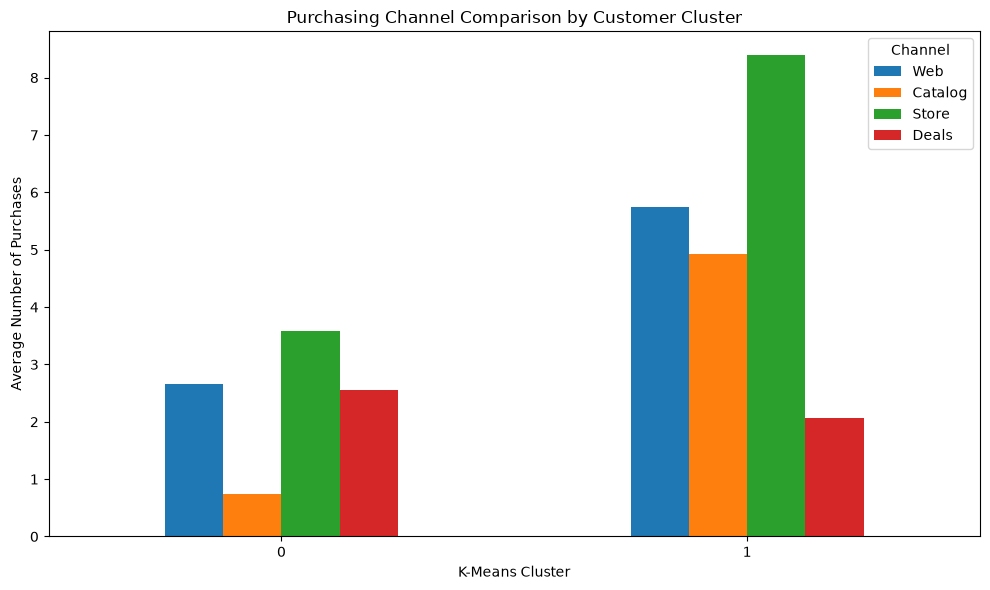

Saved: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_7_visualizations\05_purchasing_channel_comparison.png
STATUS: PASS


In [106]:
# ============================================================
# ACTIVITY 7.8 – PURCHASING CHANNEL COMPARISON
# ============================================================

channel_features = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumDealsPurchases"
]

channel_labels = [
    "Web",
    "Catalog",
    "Store",
    "Deals"
]

channel_comparison = (
    profiling_df
    .groupby("KMeans_Cluster")[channel_features]
    .mean()
)

channel_comparison.columns = channel_labels

ax = channel_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Purchasing Channel Comparison by Customer Cluster")
plt.xlabel("K-Means Cluster")
plt.ylabel("Average Number of Purchases")

plt.xticks(rotation=0)

plt.legend(
    title="Channel"
)

plt.tight_layout()

channel_chart_path = os.path.join(
    visualization_dir,
    "05_purchasing_channel_comparison.png"
)

plt.savefig(
    channel_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    os.path.abspath(channel_chart_path)
)

print("STATUS: PASS")

<Figure size 1000x600 with 0 Axes>

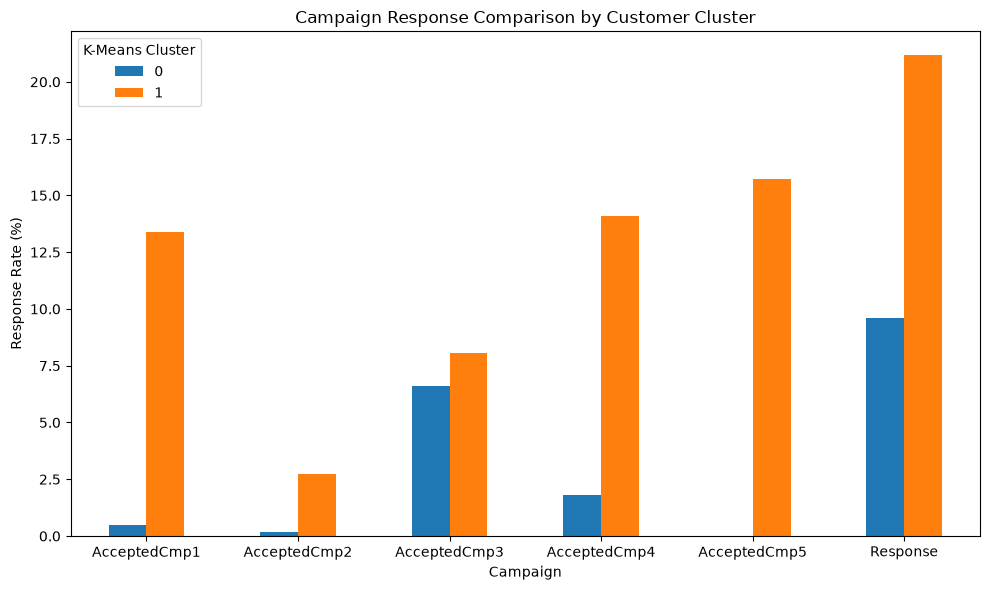

Saved: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_7_visualizations\06_campaign_response_comparison.png
STATUS: PASS


In [107]:
# ============================================================
# ACTIVITY 7.9 – CAMPAIGN RESPONSE COMPARISON
# ============================================================

campaign_features = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

# If the original campaign columns are not in profiling_df,
# use the final campaign acceptance measure instead.

available_campaign_features = [
    col
    for col in campaign_features
    if col in profiling_df.columns
]

if len(available_campaign_features) > 0:

    campaign_comparison = (
        profiling_df
        .groupby("KMeans_Cluster")[
            available_campaign_features
        ]
        .mean()
        * 100
    )

    plt.figure(figsize=(10, 6))

    campaign_comparison.T.plot(
        kind="bar",
        figsize=(10, 6)
    )

    plt.title(
        "Campaign Response Comparison by Customer Cluster"
    )

    plt.xlabel("Campaign")
    plt.ylabel("Response Rate (%)")

    plt.xticks(rotation=0)

    plt.legend(
        title="K-Means Cluster"
    )

    plt.tight_layout()

    campaign_chart_path = os.path.join(
        visualization_dir,
        "06_campaign_response_comparison.png"
    )

    plt.savefig(
        campaign_chart_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Saved:",
        os.path.abspath(campaign_chart_path)
    )

    print("STATUS: PASS")

else:

    print(
        "Campaign-specific columns are not available."
    )

    print(
        "Use Total_Campaign_Acceptance for the "
        "cluster-level campaign comparison."
    )

    print("STATUS: CHECK")

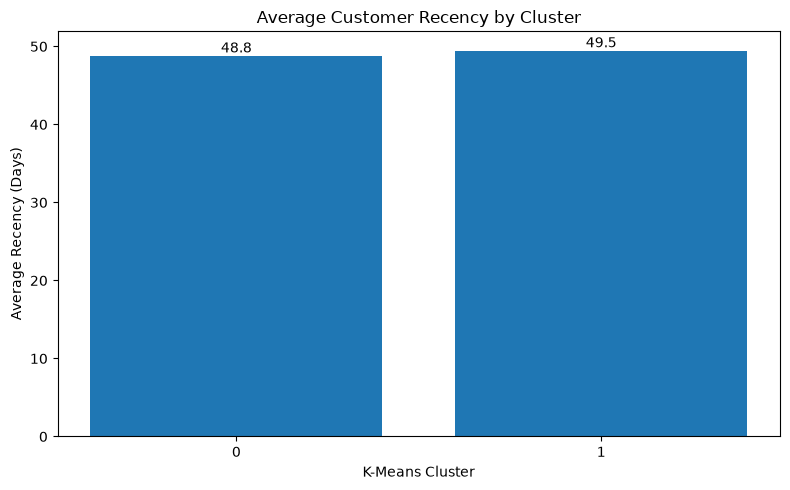

Saved: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_7_visualizations\07_recency_comparison.png
STATUS: PASS


In [108]:
# ============================================================
# ACTIVITY 7.10 – RECENCY COMPARISON
# ============================================================

recency_comparison = (
    profiling_df
    .groupby("KMeans_Cluster")["Recency"]
    .mean()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    recency_comparison.index.astype(str),
    recency_comparison.values
)

plt.title("Average Customer Recency by Cluster")
plt.xlabel("K-Means Cluster")
plt.ylabel("Average Recency (Days)")

for bar, value in zip(
    bars,
    recency_comparison.values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

recency_chart_path = os.path.join(
    visualization_dir,
    "07_recency_comparison.png"
)

plt.savefig(
    recency_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    os.path.abspath(recency_chart_path)
)

print("STATUS: PASS")

ACTIVITY 7.11 – RADAR CHART


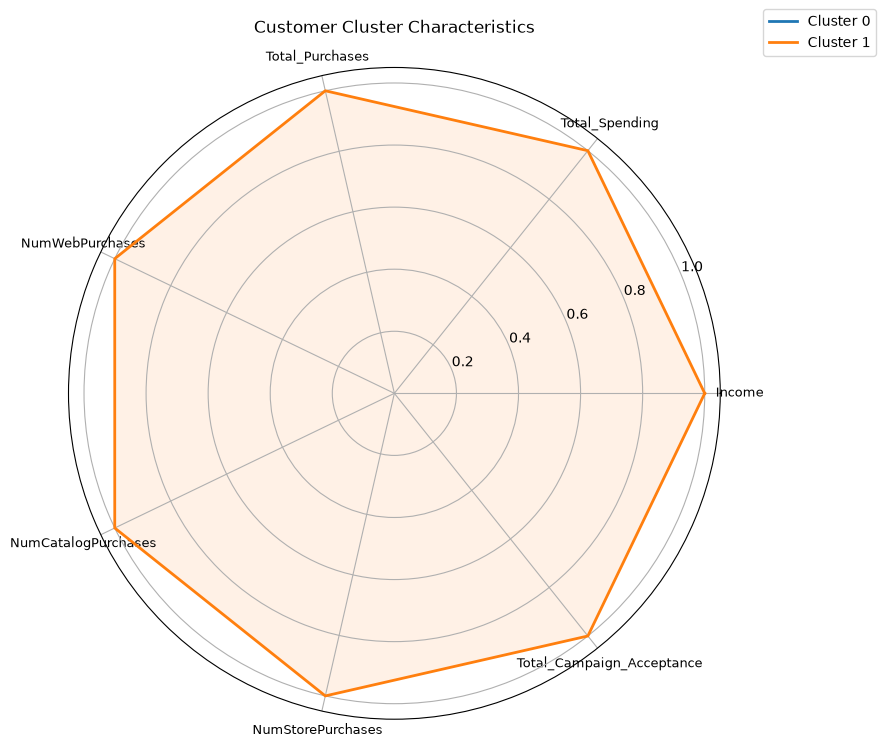

Saved: d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_7_visualizations\08_cluster_radar_chart.png
STATUS: PASS


In [109]:
# ============================================================
# ACTIVITY 7.11 – RADAR CHART
# ============================================================

print("=" * 60)
print("ACTIVITY 7.11 – RADAR CHART")
print("=" * 60)

radar_features = [
    "Income",
    "Total_Spending",
    "Total_Purchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "Total_Campaign_Acceptance"
]

radar_data = (
    profiling_df
    .groupby("KMeans_Cluster")[radar_features]
    .mean()
)

# Normalize each feature between 0 and 1
radar_normalized = (
    radar_data - radar_data.min()
) / (
    radar_data.max() - radar_data.min()
)

# Handle any constant feature
radar_normalized = radar_normalized.fillna(0)

labels = radar_normalized.columns.tolist()

angles = np.linspace(
    0,
    2 * np.pi,
    len(labels),
    endpoint=False
).tolist()

angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(9, 9),
    subplot_kw=dict(polar=True)
)

for cluster in radar_normalized.index:

    values = radar_normalized.loc[
        cluster
    ].tolist()

    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=f"Cluster {cluster}"
    )

    ax.fill(
        angles,
        values,
        alpha=0.10
    )

ax.set_xticks(
    angles[:-1]
)

ax.set_xticklabels(
    labels,
    fontsize=9
)

ax.set_title(
    "Customer Cluster Characteristics",
    pad=25
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.25, 1.10)
)

plt.tight_layout()

radar_chart_path = os.path.join(
    visualization_dir,
    "08_cluster_radar_chart.png"
)

plt.savefig(
    radar_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    os.path.abspath(radar_chart_path)
)

print("STATUS: PASS")

ACTIVITY 7.12 – PCA CLUSTER VISUALIZATION

Creating required engineered features...

Engineered features created successfully.

All PCA features are available.
STATUS: PASS

PC1 Explained Variance: 40.72 %
PC2 Explained Variance: 13.98 %


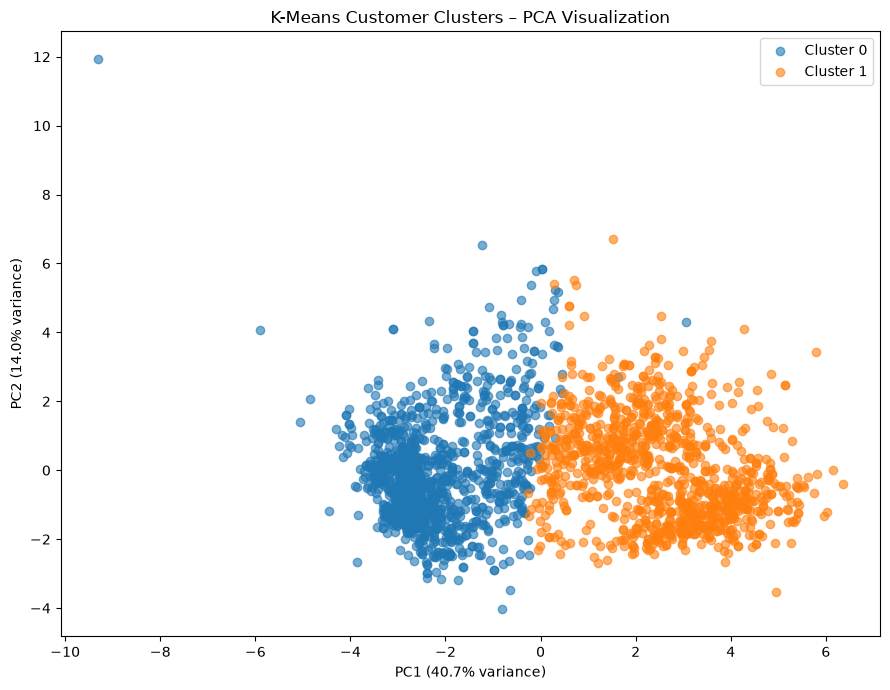


PCA chart saved:
d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_7_visualizations\09_pca_cluster_visualization.png

PCA coordinates saved:
d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_7_visualizations\pca_cluster_coordinates.csv

STATUS: PASS


In [112]:
from sklearn.decomposition import PCA

# ============================================================
# ACTIVITY 7.12 – PCA CLUSTER VISUALIZATION
# ============================================================

print("=" * 60)
print("ACTIVITY 7.12 – PCA CLUSTER VISUALIZATION")
print("=" * 60)


# ------------------------------------------------------------
# STEP 1 – RECREATE REQUIRED ENGINEERED FEATURES
# ------------------------------------------------------------

print("\nCreating required engineered features...")


# Customer Age
if "Customer_Age" not in profiling_df.columns:

    if "Age" in profiling_df.columns:

        profiling_df["Customer_Age"] = (
            profiling_df["Age"]
        )

    else:

        raise KeyError(
            "Neither Customer_Age nor Age is available."
        )


# Average Spending per Purchase
if (
    "Average_Spending_per_Purchase"
    not in profiling_df.columns
):

    profiling_df[
        "Average_Spending_per_Purchase"
    ] = np.where(
        profiling_df["Total_Purchases"] > 0,

        profiling_df["Total_Spending"]
        / profiling_df["Total_Purchases"],

        0
    )


# Digital Engagement
if "Digital_Engagement" not in profiling_df.columns:

    profiling_df[
        "Digital_Engagement"
    ] = (
        profiling_df["NumWebPurchases"]
        + profiling_df["NumCatalogPurchases"]
    )


# Customer Tenure
if (
    "Customer_Tenure_Years"
    not in profiling_df.columns
):

    if "Dt_Customer" in profiling_df.columns:

        profiling_df["Dt_Customer"] = pd.to_datetime(
            profiling_df["Dt_Customer"],
            errors="coerce"
        )

        latest_date = profiling_df[
            "Dt_Customer"
        ].max()

        profiling_df[
            "Customer_Tenure_Years"
        ] = (
            (
                latest_date
                - profiling_df["Dt_Customer"]
            ).dt.days / 365.25
        )

    else:

        # Fallback: use the existing tenure feature
        # from the original cleaned dataset if available
        raise KeyError(
            "Dt_Customer is not available, "
            "so Customer_Tenure_Years cannot be recreated."
        )


# Deal Dependency
if "Deal_Dependency" not in profiling_df.columns:

    if "Total_Purchases" in profiling_df.columns:

        profiling_df[
            "Deal_Dependency"
        ] = np.where(
            profiling_df["Total_Purchases"] > 0,

            profiling_df["NumDealsPurchases"]
            / profiling_df["Total_Purchases"],

            0
        )

    else:

        raise KeyError(
            "Total_Purchases is not available."
        )


print("\nEngineered features created successfully.")


# ------------------------------------------------------------
# STEP 2 – DEFINE PCA FEATURES
# ------------------------------------------------------------

pca_features = [
    "Customer_Age",
    "Income",
    "Total_Children",
    "Family_Size",
    "Total_Spending",
    "Average_Spending_per_Purchase",
    "Total_Purchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "Total_Campaign_Acceptance",
    "Digital_Engagement",
    "NumWebVisitsMonth",
    "Recency",
    "Customer_Tenure_Years",
    "Deal_Dependency",
    "NumDealsPurchases"
]


# ------------------------------------------------------------
# STEP 3 – CHECK FEATURES
# ------------------------------------------------------------

missing_pca_features = [
    col
    for col in pca_features
    if col not in profiling_df.columns
]

if len(missing_pca_features) > 0:

    print("\nMissing PCA features:")

    for feature in missing_pca_features:
        print("-", feature)

    print("\nSTATUS: CHECK")

else:

    print("\nAll PCA features are available.")
    print("STATUS: PASS")


    # --------------------------------------------------------
    # STEP 4 – PREPARE DATA
    # --------------------------------------------------------

    pca_input = profiling_df[
        pca_features
    ].copy()

    # Handle any missing/infinite values
    pca_input = (
        pca_input
        .replace([np.inf, -np.inf], np.nan)
        .fillna(pca_input.median())
    )


    # --------------------------------------------------------
    # STEP 5 – STANDARDIZE FEATURES
    # --------------------------------------------------------

    pca_scaler = StandardScaler()

    pca_scaled = pca_scaler.fit_transform(
        pca_input
    )


    # --------------------------------------------------------
    # STEP 6 – APPLY PCA
    # --------------------------------------------------------

    pca = PCA(n_components=2, random_state=42)

    pca_components = pca.fit_transform(
        pca_scaled
    )


    # --------------------------------------------------------
    # STEP 7 – CREATE PCA DATAFRAME
    # --------------------------------------------------------

    pca_result = pd.DataFrame(
        pca_components,
        columns=[
            "PC1",
            "PC2"
        ]
    )

    pca_result[
        "KMeans_Cluster"
    ] = profiling_df[
        "KMeans_Cluster"
    ].values


    # --------------------------------------------------------
    # STEP 8 – EXPLAINED VARIANCE
    # --------------------------------------------------------

    explained_variance = (
        pca.explained_variance_ratio_
        * 100
    )

    print(
        "\nPC1 Explained Variance:",
        round(
            explained_variance[0],
            2
        ),
        "%"
    )

    print(
        "PC2 Explained Variance:",
        round(
            explained_variance[1],
            2
        ),
        "%"
    )


    # --------------------------------------------------------
    # STEP 9 – CREATE PCA SCATTER PLOT
    # --------------------------------------------------------

    plt.figure(
        figsize=(9, 7)
    )

    for cluster in sorted(
        pca_result[
            "KMeans_Cluster"
        ].unique()
    ):

        cluster_data = pca_result[
            pca_result[
                "KMeans_Cluster"
            ] == cluster
        ]

        plt.scatter(
            cluster_data["PC1"],
            cluster_data["PC2"],
            alpha=0.6,
            label=f"Cluster {cluster}"
        )


    plt.title(
        "K-Means Customer Clusters – PCA Visualization"
    )

    plt.xlabel(
        f"PC1 ({explained_variance[0]:.1f}% variance)"
    )

    plt.ylabel(
        f"PC2 ({explained_variance[1]:.1f}% variance)"
    )

    plt.legend()

    plt.tight_layout()


    # --------------------------------------------------------
    # STEP 10 – SAVE PCA CHART
    # --------------------------------------------------------

    pca_chart_path = os.path.join(
        visualization_dir,
        "09_pca_cluster_visualization.png"
    )

    plt.savefig(
        pca_chart_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    # --------------------------------------------------------
    # STEP 11 – SAVE PCA COORDINATES
    # --------------------------------------------------------

    pca_result_path = os.path.join(
        visualization_dir,
        "pca_cluster_coordinates.csv"
    )

    pca_result.to_csv(
        pca_result_path,
        index=False
    )


    print(
        "\nPCA chart saved:"
    )

    print(
        os.path.abspath(
            pca_chart_path
        )
    )

    print(
        "\nPCA coordinates saved:"
    )

    print(
        os.path.abspath(
            pca_result_path
        )
    )

    print(
        "\nSTATUS: PASS"
    )

In [113]:
# ============================================================
# ACTIVITY 7.13 – SAVE VISUALIZATION SUMMARY DATA
# ============================================================

print("=" * 60)
print("ACTIVITY 7.13 – SAVE VISUALIZATION SUMMARY DATA")
print("=" * 60)

# Income
income_comparison.to_csv(
    os.path.join(
        visualization_dir,
        "income_comparison.csv"
    )
)

# Spending
spending_comparison.to_csv(
    os.path.join(
        visualization_dir,
        "spending_comparison.csv"
    )
)

# Product
product_heatmap.to_csv(
    os.path.join(
        visualization_dir,
        "product_preference_summary.csv"
    )
)

# Channel
channel_comparison.to_csv(
    os.path.join(
        visualization_dir,
        "purchasing_channel_summary.csv"
    )
)

# Recency
recency_comparison.to_csv(
    os.path.join(
        visualization_dir,
        "recency_comparison.csv"
    )
)

# Radar
radar_data.to_csv(
    os.path.join(
        visualization_dir,
        "radar_chart_summary.csv"
    )
)

print(
    "Visualization summary data saved successfully."
)

print("STATUS: PASS")

ACTIVITY 7.13 – SAVE VISUALIZATION SUMMARY DATA
Visualization summary data saved successfully.
STATUS: PASS


In [114]:
# ============================================================
# ACTIVITY 7.14 – FINAL VISUALIZATION VALIDATION
# ============================================================

print("=" * 60)
print("ACTIVITY 7.14 – FINAL VISUALIZATION VALIDATION")
print("=" * 60)

required_visualization_files = [
    "01_cluster_distribution.png",
    "02_income_comparison.png",
    "03_spending_comparison.png",
    "04_product_preference_heatmap.png",
    "05_purchasing_channel_comparison.png",
    "07_recency_comparison.png",
    "08_cluster_radar_chart.png",
    "09_pca_cluster_visualization.png"
]

print("\nRequired Visualization Files:")

missing_files = []

for filename in required_visualization_files:

    filepath = os.path.join(
        visualization_dir,
        filename
    )

    if os.path.exists(filepath):

        print(
            f"{filename}: AVAILABLE"
        )

    else:

        print(
            f"{filename}: NOT FOUND"
        )

        missing_files.append(filename)


if len(missing_files) == 0:

    print(
        "\nAll required visualization files "
        "are available."
    )

    print("STATUS: PASS")

else:

    print("\nMissing visualization files:")

    for filename in missing_files:
        print("-", filename)

    print("\nSTATUS: CHECK")

ACTIVITY 7.14 – FINAL VISUALIZATION VALIDATION

Required Visualization Files:
01_cluster_distribution.png: AVAILABLE
02_income_comparison.png: AVAILABLE
03_spending_comparison.png: AVAILABLE
04_product_preference_heatmap.png: AVAILABLE
05_purchasing_channel_comparison.png: AVAILABLE
07_recency_comparison.png: AVAILABLE
08_cluster_radar_chart.png: AVAILABLE
09_pca_cluster_visualization.png: AVAILABLE

All required visualization files are available.
STATUS: PASS


## Activity 7.15 – Module 7 Final Summary

Module 7 – Cluster Evaluation & Customer Profiling has been completed.

The project transformed the K-Means clustering results into meaningful customer segments through demographic analysis, spending behavior analysis, shopping channel analysis, marketing campaign analysis, business segmentation, customer persona development, and professional cluster visualizations.

The final visualizations provide graphical evidence of differences between customer segments and support the business recommendations developed throughout the module.

In [115]:
# ============================================================
# ACTIVITY 7.15 – MODULE 7 FINAL SUMMARY
# ============================================================

print("=" * 60)
print("MODULE 7 – FINAL COMPLETION SUMMARY")
print("=" * 60)

print("\nActivities Completed:")

print("1. Cluster Statistics & Demographic Analysis: PASS")
print("2. Spending Behavior Analysis: PASS")
print("3. Shopping Channel & Customer Engagement Analysis: PASS")
print("4. Marketing Campaign Analysis: PASS")
print("5. Business Segmentation & Cluster Naming: PASS")
print("6. Customer Persona Development: PASS")
print("7. Cluster Visualization & Final Documentation: PASS")

print("\nFinal Model:")
print("K-Means Clustering")

print("\nNumber of Clusters:")
print(
    profiling_df["KMeans_Cluster"].nunique()
)

print("\nCustomer Distribution:")

display(
    profiling_df[
        "KMeans_Cluster"
    ]
    .value_counts()
    .sort_index()
    .rename("Customer_Count")
    .to_frame()
)

print("\nVisualization Folder:")
print(
    os.path.abspath(
        visualization_dir
    )
)

print("\nMODULE 7 COMPLETED SUCCESSFULLY.")

MODULE 7 – FINAL COMPLETION SUMMARY

Activities Completed:
1. Cluster Statistics & Demographic Analysis: PASS
2. Spending Behavior Analysis: PASS
3. Shopping Channel & Customer Engagement Analysis: PASS
4. Marketing Campaign Analysis: PASS
5. Business Segmentation & Cluster Naming: PASS
6. Customer Persona Development: PASS
7. Cluster Visualization & Final Documentation: PASS

Final Model:
K-Means Clustering

Number of Clusters:
2

Customer Distribution:


,Customer_Count
KMeans_Cluster,
0,1207
1,1030



Visualization Folder:
d:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_7_visualizations

MODULE 7 COMPLETED SUCCESSFULLY.
